In [3]:
# ============================================================
# 中文字体设置
# 目的：
# 让 Matplotlib 在 Windows 下正常显示中文
# ============================================================

import matplotlib.pyplot as plt
from matplotlib import font_manager

# Windows 微软雅黑字体路径
font_path = r"C:\Windows\Fonts\msyh.ttc"

# 创建中文字体对象
chinese_font = font_manager.FontProperties(
    fname=font_path
)

# 设置 Matplotlib 默认字体
plt.rcParams["font.family"] = chinese_font.get_name()

# 避免负号显示成方框
plt.rcParams["axes.unicode_minus"] = False

print("当前中文字体：", chinese_font.get_name())

当前中文字体： Microsoft YaHei


In [ ]:
# ============================================================
# 0. 项目环境检查
# 目的：
# 1. 确认当前 Notebook 使用的是 Python 3.13
# 2. 确认数据分析和机器学习所需的核心库可以正常导入
# 3. 查看当前项目的工作目录
# ============================================================

import sys
import os

import numpy as np
import pandas as pd
import sklearn
import xgboost as xgb
import matplotlib
import seaborn as sns

# 查看 Python 版本
print("Python 版本：")
print(sys.version)

# 查看主要第三方库版本
print("\n主要库版本：")
print("NumPy：", np.__version__)
print("Pandas：", pd.__version__)
print("Scikit-learn：", sklearn.__version__)
print("XGBoost：", xgb.__version__)
print("Matplotlib：", matplotlib.__version__)
print("Seaborn：", sns.__version__)

# 查看 Notebook 当前工作目录
print("\n当前工作目录：")
print(os.getcwd())

print("\n✅ 项目环境检查完成")

In [ ]:
# ============================================================
# 1. 查看项目目录结构
# ============================================================

from pathlib import Path

# 当前项目根目录
project_dir = Path.cwd()

# 需要重点检查的文件夹
folders = ["data", "feature", "model", "images"]

for folder_name in folders:
    folder_path = project_dir / folder_name

    print(f"\n{'=' * 60}")
    print(f"📁 {folder_name}")
    print("=" * 60)

    if not folder_path.exists():
        print("❌ 文件夹不存在")
        continue

    files = list(folder_path.iterdir())

    if len(files) == 0:
        print("⚠️ 文件夹为空")
        continue

    for file in files:
        # 如果是文件，同时显示文件大小
        if file.is_file():
            size_mb = file.stat().st_size / 1024 / 1024
            print(f"{file.name:<50} {size_mb:>10.2f} MB")
        else:
            print(f"[文件夹] {file.name}")


📁 data
[文件夹] data_format1
sample_submission.csv                                    4.12 MB
submission_0101_stack_lr_138iter.csv                     8.18 MB
submission_0130_randomforest_maxdepth14_133trees_entropy_14features.csv       8.15 MB
submission_0131_adaboost_n50_lr1.csv                     8.32 MB
submission_0131_stack_lr_138iter.csv                     8.24 MB
submission_0131_stack_perceptron_alpha0.0001_1000iter.csv       8.25 MB
submission_1228.csv                                      8.14 MB
submission_1229_adaboost_n50_lr1.csv                     7.96 MB
submission_1229_LinearSVC.csv                            8.14 MB
submission_1229_logireg.csv                              8.14 MB
submission_1229_mlp_adam_700nodes.csv                    8.39 MB
submission_1229_mlp_sgd_700nodes.csv                     8.16 MB
submission_1229_randomforest_maxdepth8_100trees.csv       8.14 MB
submission_1230_xgboost_n100_maxdepth8_lr0.1.csv         5.99 MB
submission_1231_logireg.csv       

In [ ]:
# ============================================================
# 2. 单独查看核心数据文件
# 目的：
# 只检查真正与项目分析有关的两个目录：
# 1. data/data_format1：原始比赛数据
# 2. feature：已生成的特征数据
# 避免被大量 submission 文件干扰
# ============================================================

from pathlib import Path

project_dir = Path.cwd()

# 原始数据目录
raw_data_dir = project_dir / "data" / "data_format1"

# 特征数据目录
feature_dir = project_dir / "feature"


def show_files(folder_path, folder_name):
    """打印指定文件夹中的文件名、大小和文件类型"""

    print("\n" + "=" * 70)
    print(f"📁 {folder_name}")
    print("=" * 70)

    if not folder_path.exists():
        print("❌ 文件夹不存在")
        return

    files = sorted(folder_path.iterdir())

    if not files:
        print("⚠️ 文件夹为空")
        return

    for file in files:
        if file.is_file():
            size_mb = file.stat().st_size / 1024 / 1024

            print(
                f"{file.name:<55}"
                f"{size_mb:>10.2f} MB"
            )
        else:
            print(f"[文件夹] {file.name}")


# 查看原始数据
show_files(
    raw_data_dir,
    "data/data_format1 —— 原始比赛数据"
)

# 查看已生成的特征
show_files(
    feature_dir,
    "feature —— 已生成特征"
)


📁 data/data_format1 —— 原始比赛数据
brand_id_value_counts.csv                                    0.10 MB
cat_id_value_counts.csv                                      0.02 MB
item_id_value_counts.csv                                    10.96 MB
seller_id_value_counts.csv                                   0.05 MB
test_format1.csv                                             3.38 MB
test_format2.csv                                           733.05 MB
train_format1.csv                                            3.62 MB
train_format2.csv                                          731.89 MB
user_id_value_counts.csv                                     4.50 MB
user_info_format1.csv                                        6.34 MB
user_log_format1.csv                                      1954.25 MB
user_log_format1_1.csv                                    1314.22 MB
user_log_format1_2.csv                                    1100.86 MB
user_log_format1_samples.csv                                 0.04 MB

📁 

In [7]:
# ============================================================
# 3. 检查两份用户行为日志分片
# 目的：
# 1. 确认两个文件都放在正确位置
# 2. 检查字段是否一致
# 3. 查看前几行数据，确认数据结构
# 4. 在真正合并前避免格式问题
# ============================================================

from pathlib import Path
import pandas as pd

# 原始数据所在目录
data_dir = Path("data/data_format1")

# 两份行为日志分片
file_1 = data_dir / "user_log_format1_1.csv"
file_2 = data_dir / "user_log_format1_2.csv"

# 检查文件是否存在
print("文件 1 是否存在：", file_1.exists())
print("文件 2 是否存在：", file_2.exists())

# 查看文件大小
if file_1.exists():
    print(
        "文件 1 大小：",
        round(file_1.stat().st_size / 1024 / 1024 / 1024, 2),
        "GB"
    )

if file_2.exists():
    print(
        "文件 2 大小：",
        round(file_2.stat().st_size / 1024 / 1024 / 1024, 2),
        "GB"
    )

# 只读取前 5 行，不会把整个大文件载入内存
sample_1 = pd.read_csv(file_1, nrows=5)
sample_2 = pd.read_csv(file_2, nrows=5)

print("\n================ 文件 1 ================")
display(sample_1)

print("\n文件 1 字段：")
print(sample_1.columns.tolist())

print("\n================ 文件 2 ================")
display(sample_2)

print("\n文件 2 字段：")
print(sample_2.columns.tolist())

# 检查两个文件字段是否完全一致
print("\n两份文件字段是否一致：")
print(sample_1.columns.tolist() == sample_2.columns.tolist())

文件 1 是否存在： True
文件 2 是否存在： True
文件 1 大小： 1.28 GB
文件 2 大小： 1.08 GB

================ 文件 1 ================


,Unnamed: 0,user_id,item_id,cat_id,seller_id,brand_id,time_stamp,action_type
0,0,328862,323294,833,2882,2661.0,829,0
1,1,328862,844400,1271,2882,2661.0,829,0
2,2,328862,575153,1271,2882,2661.0,829,0
3,3,328862,996875,1271,2882,2661.0,829,0
4,4,328862,1086186,1271,1253,1049.0,829,0



文件 1 字段：
['Unnamed: 0', 'user_id', 'item_id', 'cat_id', 'seller_id', 'brand_id', 'time_stamp', 'action_type']

================ 文件 2 ================


,Unnamed: 0,user_id,item_id,cat_id,seller_id,brand_id,time_stamp,action_type
0,30000000,284456,167191,692,2011,1287.0,713,0
1,30000001,284456,330306,1438,1418,7141.0,713,0
2,30000002,284456,239397,1438,2877,7141.0,713,0
3,30000003,284456,323284,142,2266,8102.0,630,0
4,30000004,284456,2956,407,3255,7141.0,630,0



文件 2 字段：
['Unnamed: 0', 'user_id', 'item_id', 'cat_id', 'seller_id', 'brand_id', 'time_stamp', 'action_type']

两份文件字段是否一致：
True


In [8]:
# ============================================================
# 4. 合并两份用户行为日志
#
# 目的：
# 1. 将 user_log_format1_1.csv 和 user_log_format1_2.csv
#    合并成完整的 user_log_format1.csv
# 2. 删除无业务意义的 "Unnamed: 0" 索引列
# 3. 使用分块读取，避免一次性读取 5000 多万行导致内存不足
# ============================================================

from pathlib import Path
import pandas as pd

# ------------------------------------------------------------
# 1. 设置文件路径
# ------------------------------------------------------------

data_dir = Path("data/data_format1")

input_files = [
    data_dir / "user_log_format1_1.csv",
    data_dir / "user_log_format1_2.csv"
]

output_file = data_dir / "user_log_format1.csv"


# ------------------------------------------------------------
# 2. 设置每次读取的数据量
# ------------------------------------------------------------
# 每次读取 100 万行。
# 这样不会把 5000 多万行一次性全部加载进内存。

chunk_size = 1_000_000


# ------------------------------------------------------------
# 3. 指定字段的数据类型
# ------------------------------------------------------------
# 使用较小的数据类型可以明显降低内存占用。

dtype_dict = {
    "user_id": "int32",
    "item_id": "int32",
    "cat_id": "int32",
    "seller_id": "int32",
    "brand_id": "float32",   # brand_id 存在缺失值，因此暂时使用 float
    "time_stamp": "int16",
    "action_type": "int8"
}


# ------------------------------------------------------------
# 4. 如果之前生成过不完整文件，先删除
# ------------------------------------------------------------

if output_file.exists():
    output_file.unlink()
    print("⚠️ 已删除之前存在的 user_log_format1.csv")


# ------------------------------------------------------------
# 5. 开始分块合并
# ------------------------------------------------------------

total_rows = 0
first_chunk = True

for file_number, input_file in enumerate(input_files, start=1):

    print("\n" + "=" * 70)
    print(f"开始处理文件 {file_number}：{input_file.name}")
    print("=" * 70)

    # 分块读取 CSV
    reader = pd.read_csv(
        input_file,
        chunksize=chunk_size,
        dtype=dtype_dict
    )

    for chunk_number, chunk in enumerate(reader, start=1):

        # 删除 CSV 中无业务意义的旧索引列
        if "Unnamed: 0" in chunk.columns:
            chunk = chunk.drop(columns=["Unnamed: 0"])

        # 将当前数据块追加写入最终文件
        chunk.to_csv(
            output_file,
            mode="w" if first_chunk else "a",
            header=first_chunk,
            index=False
        )

        # 第一块之后，后续数据不再写表头
        first_chunk = False

        # 统计已经处理的总行数
        total_rows += len(chunk)

        print(
            f"文件 {file_number} - 第 {chunk_number} 块完成，"
            f"累计处理：{total_rows:,} 行"
        )


# ------------------------------------------------------------
# 6. 输出合并结果
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("✅ 用户行为日志合并完成")
print("=" * 70)

print(f"总行数：{total_rows:,}")

print(
    "文件大小：",
    round(output_file.stat().st_size / 1024 / 1024 / 1024, 2),
    "GB"
)

print("生成文件：")
print(output_file)

⚠️ 已删除之前存在的 user_log_format1.csv

开始处理文件 1：user_log_format1_1.csv
文件 1 - 第 1 块完成，累计处理：1,000,000 行
文件 1 - 第 2 块完成，累计处理：2,000,000 行
文件 1 - 第 3 块完成，累计处理：3,000,000 行
文件 1 - 第 4 块完成，累计处理：4,000,000 行
文件 1 - 第 5 块完成，累计处理：5,000,000 行
文件 1 - 第 6 块完成，累计处理：6,000,000 行
文件 1 - 第 7 块完成，累计处理：7,000,000 行
文件 1 - 第 8 块完成，累计处理：8,000,000 行
文件 1 - 第 9 块完成，累计处理：9,000,000 行
文件 1 - 第 10 块完成，累计处理：10,000,000 行
文件 1 - 第 11 块完成，累计处理：11,000,000 行
文件 1 - 第 12 块完成，累计处理：12,000,000 行
文件 1 - 第 13 块完成，累计处理：13,000,000 行
文件 1 - 第 14 块完成，累计处理：14,000,000 行
文件 1 - 第 15 块完成，累计处理：15,000,000 行
文件 1 - 第 16 块完成，累计处理：16,000,000 行
文件 1 - 第 17 块完成，累计处理：17,000,000 行
文件 1 - 第 18 块完成，累计处理：18,000,000 行
文件 1 - 第 19 块完成，累计处理：19,000,000 行
文件 1 - 第 20 块完成，累计处理：20,000,000 行
文件 1 - 第 21 块完成，累计处理：21,000,000 行
文件 1 - 第 22 块完成，累计处理：22,000,000 行
文件 1 - 第 23 块完成，累计处理：23,000,000 行
文件 1 - 第 24 块完成，累计处理：24,000,000 行
文件 1 - 第 25 块完成，累计处理：25,000,000 行
文件 1 - 第 26 块完成，累计处理：26,000,000 行
文件 1 - 第 27 块完成，累计处理：27,000,000 行
文件 1 - 第 28 块完成，累计处理：28,000,000 行


In [9]:
# ============================================================
# 5. 检查合并后的用户行为日志
# 目的：
# 1. 确认字段正确
# 2. 确认无多余索引列
# 3. 查看前几行数据
# ============================================================

import pandas as pd
from pathlib import Path

data_dir = Path("data/data_format1")
log_file = data_dir / "user_log_format1.csv"

# 只读取前 10 行，不会加载整个 1.91 GB 文件
log_sample = pd.read_csv(log_file, nrows=10)

print("字段列表：")
print(log_sample.columns.tolist())

print("\n前 10 行数据：")
display(log_sample)

字段列表：
['user_id', 'item_id', 'cat_id', 'seller_id', 'brand_id', 'time_stamp', 'action_type']

前 10 行数据：


,user_id,item_id,cat_id,seller_id,brand_id,time_stamp,action_type
0,328862,323294,833,2882,2661.0,829,0
1,328862,844400,1271,2882,2661.0,829,0
2,328862,575153,1271,2882,2661.0,829,0
3,328862,996875,1271,2882,2661.0,829,0
4,328862,1086186,1271,1253,1049.0,829,0
5,328862,623866,1271,2882,2661.0,829,0
6,328862,542871,1467,2882,2661.0,829,0
7,328862,536347,1095,883,1647.0,829,0
8,328862,364513,1271,2882,2661.0,829,0
9,328862,575153,1271,2882,2661.0,829,0


In [10]:
# ============================================================
# 6. 检查 train_format2 和 test_format2 的数据结构
#
# 目的：
# 1. 确认两个官方文件读取正常
# 2. 查看训练集和测试集分别有哪些字段
# 3. 确认后续应该提取哪些字段生成 Format 1
#
# 注意：
# 这里只读取前 5 行，不会把 700 多 MB 的文件全部载入内存
# ============================================================

from pathlib import Path
import pandas as pd

# 数据目录
data_dir = Path("data/data_format1")

# 两个 Format 2 文件
train_f2_path = data_dir / "train_format2.csv"
test_f2_path = data_dir / "test_format2.csv"

# ------------------------------------------------------------
# 1. 检查文件是否存在
# ------------------------------------------------------------

print("train_format2.csv 是否存在：", train_f2_path.exists())
print("test_format2.csv 是否存在：", test_f2_path.exists())

# ------------------------------------------------------------
# 2. 查看文件大小
# ------------------------------------------------------------

if train_f2_path.exists():
    print(
        "train_format2.csv 大小：",
        round(train_f2_path.stat().st_size / 1024 / 1024, 2),
        "MB"
    )

if test_f2_path.exists():
    print(
        "test_format2.csv 大小：",
        round(test_f2_path.stat().st_size / 1024 / 1024, 2),
        "MB"
    )

# ------------------------------------------------------------
# 3. 只读取前 5 行
# ------------------------------------------------------------

train_f2_sample = pd.read_csv(
    train_f2_path,
    nrows=5
)

test_f2_sample = pd.read_csv(
    test_f2_path,
    nrows=5
)

# ------------------------------------------------------------
# 4. 查看字段
# ------------------------------------------------------------

print("\n================ 训练集字段 ================")
print(train_f2_sample.columns.tolist())

display(train_f2_sample)

print("\n================ 测试集字段 ================")
print(test_f2_sample.columns.tolist())

display(test_f2_sample)

train_format2.csv 是否存在： True
test_format2.csv 是否存在： True
train_format2.csv 大小： 731.89 MB
test_format2.csv 大小： 733.05 MB

================ 训练集字段 ================
['user_id', 'age_range', 'gender', 'merchant_id', 'label', 'activity_log']


,user_id,age_range,gender,merchant_id,label,activity_log
0,34176,6,0,944,-1,408895:1505:7370:1107:0
1,34176,6,0,412,-1,17235:1604:4396:0818:0#954723:1604:4396:0818:0...
2,34176,6,0,1945,-1,231901:662:2758:0818:0#231901:662:2758:0818:0#...
3,34176,6,0,4752,-1,174142:821:6938:1027:0
4,34176,6,0,643,-1,716371:1505:968:1024:3



================ 测试集字段 ================
['user_id', 'age_range', 'gender', 'merchant_id', 'label', 'activity_log']


,user_id,age_range,gender,merchant_id,label,activity_log
0,163968,0,0,4378,-1,101206:812:6968:0614:0
1,163968,0,0,2300,-1,588758:844:3833:0618:0#71782:844:3833:1111:2#7...
2,163968,0,0,1551,-1,312747:243:1954:0627:0#312747:243:1954:0627:0#...
3,163968,0,0,4343,-1,932390:1612:3201:0628:0
4,163968,0,0,4911,-1,957657:662:3089:0612:0


In [11]:
# ============================================================
# 7. 检查 train_format2 和 test_format2 的标签分布
#
# 目的：
# 1. 确认 label = 1 / 0 / -1 / 缺失值 各有多少行
# 2. 判断哪些记录是真正用于训练的样本
# 3. 判断哪些记录是真正需要预测的测试样本
#
# 注意：
# 只读取 user_id、merchant_id、label 三列，
# 不读取巨大的 activity_log，可以大幅降低内存占用。
# ============================================================

from pathlib import Path
import pandas as pd

data_dir = Path("data/data_format1")

train_f2_path = data_dir / "train_format2.csv"
test_f2_path = data_dir / "test_format2.csv"


def inspect_label_distribution(file_path, file_name):
    """分块统计一个 Format 2 文件中的标签分布"""

    chunk_size = 100_000

    label_counts = {
        1: 0,
        0: 0,
        -1: 0,
        "缺失值": 0
    }

    total_rows = 0
    unique_pairs = set()

    reader = pd.read_csv(
        file_path,
        usecols=["user_id", "merchant_id", "label"],
        chunksize=chunk_size
    )

    for chunk in reader:

        total_rows += len(chunk)

        # 统计 1 / 0 / -1
        counts = chunk["label"].value_counts(dropna=False)

        label_counts[1] += int(counts.get(1, 0))
        label_counts[0] += int(counts.get(0, 0))
        label_counts[-1] += int(counts.get(-1, 0))
        label_counts["缺失值"] += int(chunk["label"].isna().sum())

    print("\n" + "=" * 60)
    print(file_name)
    print("=" * 60)

    print(f"总行数：{total_rows:,}")
    print(f"label = 1：{label_counts[1]:,}")
    print(f"label = 0：{label_counts[0]:,}")
    print(f"label = -1：{label_counts[-1]:,}")
    print(f"label 缺失：{label_counts['缺失值']:,}")


inspect_label_distribution(
    train_f2_path,
    "train_format2.csv"
)

inspect_label_distribution(
    test_f2_path,
    "test_format2.csv"
)


train_format2.csv
总行数：7,030,723
label = 1：15,952
label = 0：244,912
label = -1：6,769,859
label 缺失：0

test_format2.csv
总行数：7,027,943
label = 1：0
label = 0：0
label = -1：6,766,466
label 缺失：261,477


In [12]:
# ============================================================
# 8. 从 Format 2 生成 Format 1 的三张核心数据表
#
# 最终生成：
# 1. train_format1.csv
# 2. test_format1.csv
# 3. user_info_format1.csv
#
# 转换逻辑：
# train_format2：
#   label = 0 或 1 → 训练样本
#
# test_format2：
#   label 缺失 → 测试样本
#
# train + test：
#   提取 user_id、age_range、gender
#   → 去重后生成用户信息表
# ============================================================

from pathlib import Path
import pandas as pd

# ------------------------------------------------------------
# 1. 文件路径
# ------------------------------------------------------------

data_dir = Path("data/data_format1")

train_f2_path = data_dir / "train_format2.csv"
test_f2_path = data_dir / "test_format2.csv"

train_f1_path = data_dir / "train_format1.csv"
test_f1_path = data_dir / "test_format1.csv"
user_info_path = data_dir / "user_info_format1.csv"


# ------------------------------------------------------------
# 2. 每次读取 50 万行
# ------------------------------------------------------------

chunk_size = 500_000


# ------------------------------------------------------------
# 3. 如果之前生成过结果文件，先删除
# 防止重复追加
# ------------------------------------------------------------

for file_path in [
    train_f1_path,
    test_f1_path,
    user_info_path
]:
    if file_path.exists():
        file_path.unlink()


# ------------------------------------------------------------
# 4. 用于暂存用户信息
#
# Format 2 中，同一个用户会对应多个商家，
# 所以用户的年龄、性别会重复出现。
#
# 我们先在每个数据块内按 user_id 去重，
# 最后再统一去重。
# ------------------------------------------------------------

user_info_parts = []


# ============================================================
# 5. 处理训练集
# ============================================================

print("=" * 70)
print("开始处理 train_format2.csv")
print("=" * 70)

train_first_chunk = True
train_rows = 0

train_reader = pd.read_csv(
    train_f2_path,

    # activity_log 非常大，这里完全不读取
    usecols=[
        "user_id",
        "age_range",
        "gender",
        "merchant_id",
        "label"
    ],

    chunksize=chunk_size
)

for chunk_number, chunk in enumerate(train_reader, start=1):

    # --------------------------------------------------------
    # 保存用户基本信息
    # --------------------------------------------------------

    user_part = (
        chunk[
            ["user_id", "age_range", "gender"]
        ]
        .drop_duplicates(subset=["user_id"])
    )

    user_info_parts.append(user_part)


    # --------------------------------------------------------
    # 训练集只保留 label = 0 或 1
    #
    # label = -1 不属于最终训练样本
    # --------------------------------------------------------

    train_chunk = chunk[
        chunk["label"].isin([0, 1])
    ][
        ["user_id", "merchant_id", "label"]
    ].copy()


    # label 现在已经没有缺失值，可以转换成整数
    train_chunk["label"] = train_chunk["label"].astype("int8")


    # --------------------------------------------------------
    # 写入 train_format1.csv
    # --------------------------------------------------------

    train_chunk.to_csv(
        train_f1_path,
        mode="w" if train_first_chunk else "a",
        header=train_first_chunk,
        index=False
    )

    train_first_chunk = False
    train_rows += len(train_chunk)

    print(
        f"训练文件第 {chunk_number} 块完成，"
        f"累计有效训练样本：{train_rows:,}"
    )


# ============================================================
# 6. 处理测试集
# ============================================================

print("\n" + "=" * 70)
print("开始处理 test_format2.csv")
print("=" * 70)

test_first_chunk = True
test_rows = 0

test_reader = pd.read_csv(
    test_f2_path,

    usecols=[
        "user_id",
        "age_range",
        "gender",
        "merchant_id",
        "label"
    ],

    chunksize=chunk_size
)

for chunk_number, chunk in enumerate(test_reader, start=1):

    # --------------------------------------------------------
    # 保存用户基本信息
    # --------------------------------------------------------

    user_part = (
        chunk[
            ["user_id", "age_range", "gender"]
        ]
        .drop_duplicates(subset=["user_id"])
    )

    user_info_parts.append(user_part)


    # --------------------------------------------------------
    # 测试集真正需要预测的是 label 缺失的记录
    # --------------------------------------------------------

    test_chunk = chunk[
        chunk["label"].isna()
    ][
        ["user_id", "merchant_id"]
    ].copy()


    # --------------------------------------------------------
    # 官方 Format 1 测试集有 prob 字段，
    # 用于后面填写模型预测概率
    #
    # 现在还没有模型结果，因此先设为空值
    # --------------------------------------------------------

    test_chunk["prob"] = float("nan")


    # --------------------------------------------------------
    # 写入 test_format1.csv
    # --------------------------------------------------------

    test_chunk.to_csv(
        test_f1_path,
        mode="w" if test_first_chunk else "a",
        header=test_first_chunk,
        index=False
    )

    test_first_chunk = False
    test_rows += len(test_chunk)

    print(
        f"测试文件第 {chunk_number} 块完成，"
        f"累计有效测试样本：{test_rows:,}"
    )


# ============================================================
# 7. 生成 user_info_format1.csv
# ============================================================

print("\n" + "=" * 70)
print("开始生成 user_info_format1.csv")
print("=" * 70)

# 合并前面各块提取出的用户信息
user_info = pd.concat(
    user_info_parts,
    ignore_index=True
)

# 同一个用户在 Format 2 中会重复出现，
# 最终每个 user_id 只保留一条记录
user_info = (
    user_info
    .drop_duplicates(subset=["user_id"])
    .sort_values("user_id")
    .reset_index(drop=True)
)

# 保存用户信息表
user_info.to_csv(
    user_info_path,
    index=False
)


# ============================================================
# 8. 输出最终结果
# ============================================================

print("\n" + "=" * 70)
print("✅ Format 1 数据生成完成")
print("=" * 70)

print(f"train_format1.csv：{train_rows:,} 行")
print(f"test_format1.csv：{test_rows:,} 行")
print(f"user_info_format1.csv：{len(user_info):,} 行")

开始处理 train_format2.csv
训练文件第 1 块完成，累计有效训练样本：18,687
训练文件第 2 块完成，累计有效训练样本：37,205
训练文件第 3 块完成，累计有效训练样本：55,787
训练文件第 4 块完成，累计有效训练样本：74,157
训练文件第 5 块完成，累计有效训练样本：92,749
训练文件第 6 块完成，累计有效训练样本：111,316
训练文件第 7 块完成，累计有效训练样本：129,859
训练文件第 8 块完成，累计有效训练样本：148,457
训练文件第 9 块完成，累计有效训练样本：167,176
训练文件第 10 块完成，累计有效训练样本：185,586
训练文件第 11 块完成，累计有效训练样本：204,271
训练文件第 12 块完成，累计有效训练样本：222,818
训练文件第 13 块完成，累计有效训练样本：241,255
训练文件第 14 块完成，累计有效训练样本：259,660
训练文件第 15 块完成，累计有效训练样本：260,864

开始处理 test_format2.csv
测试文件第 1 块完成，累计有效测试样本：18,569
测试文件第 2 块完成，累计有效测试样本：36,908
测试文件第 3 块完成，累计有效测试样本：55,957
测试文件第 4 块完成，累计有效测试样本：74,487
测试文件第 5 块完成，累计有效测试样本：93,293
测试文件第 6 块完成，累计有效测试样本：111,953
测试文件第 7 块完成，累计有效测试样本：130,585
测试文件第 8 块完成，累计有效测试样本：149,304
测试文件第 9 块完成，累计有效测试样本：167,906
测试文件第 10 块完成，累计有效测试样本：186,245
测试文件第 11 块完成，累计有效测试样本：204,975
测试文件第 12 块完成，累计有效测试样本：223,549
测试文件第 13 块完成，累计有效测试样本：241,943
测试文件第 14 块完成，累计有效测试样本：260,486
测试文件第 15 块完成，累计有效测试样本：261,477

开始生成 user_info_format1.csv

✅ Format 1 数据生成完成
train_format1.csv：260,864 行
test_fo

In [13]:
# ============================================================
# 8. 从 Format 2 生成 Format 1 的三张核心数据表
#
# 最终生成：
# 1. train_format1.csv
# 2. test_format1.csv
# 3. user_info_format1.csv
#
# 转换逻辑：
# train_format2：
#   label = 0 或 1 → 训练样本
#
# test_format2：
#   label 缺失 → 测试样本
#
# train + test：
#   提取 user_id、age_range、gender
#   → 去重后生成用户信息表
# ============================================================

from pathlib import Path
import pandas as pd

# ------------------------------------------------------------
# 1. 文件路径
# ------------------------------------------------------------

data_dir = Path("data/data_format1")

train_f2_path = data_dir / "train_format2.csv"
test_f2_path = data_dir / "test_format2.csv"

train_f1_path = data_dir / "train_format1.csv"
test_f1_path = data_dir / "test_format1.csv"
user_info_path = data_dir / "user_info_format1.csv"


# ------------------------------------------------------------
# 2. 每次读取 50 万行
# ------------------------------------------------------------

chunk_size = 500_000


# ------------------------------------------------------------
# 3. 如果之前生成过结果文件，先删除
# 防止重复追加
# ------------------------------------------------------------

for file_path in [
    train_f1_path,
    test_f1_path,
    user_info_path
]:
    if file_path.exists():
        file_path.unlink()


# ------------------------------------------------------------
# 4. 用于暂存用户信息
#
# Format 2 中，同一个用户会对应多个商家，
# 所以用户的年龄、性别会重复出现。
#
# 我们先在每个数据块内按 user_id 去重，
# 最后再统一去重。
# ------------------------------------------------------------

user_info_parts = []


# ============================================================
# 5. 处理训练集
# ============================================================

print("=" * 70)
print("开始处理 train_format2.csv")
print("=" * 70)

train_first_chunk = True
train_rows = 0

train_reader = pd.read_csv(
    train_f2_path,

    # activity_log 非常大，这里完全不读取
    usecols=[
        "user_id",
        "age_range",
        "gender",
        "merchant_id",
        "label"
    ],

    chunksize=chunk_size
)

for chunk_number, chunk in enumerate(train_reader, start=1):

    # --------------------------------------------------------
    # 保存用户基本信息
    # --------------------------------------------------------

    user_part = (
        chunk[
            ["user_id", "age_range", "gender"]
        ]
        .drop_duplicates(subset=["user_id"])
    )

    user_info_parts.append(user_part)


    # --------------------------------------------------------
    # 训练集只保留 label = 0 或 1
    #
    # label = -1 不属于最终训练样本
    # --------------------------------------------------------

    train_chunk = chunk[
        chunk["label"].isin([0, 1])
    ][
        ["user_id", "merchant_id", "label"]
    ].copy()


    # label 现在已经没有缺失值，可以转换成整数
    train_chunk["label"] = train_chunk["label"].astype("int8")


    # --------------------------------------------------------
    # 写入 train_format1.csv
    # --------------------------------------------------------

    train_chunk.to_csv(
        train_f1_path,
        mode="w" if train_first_chunk else "a",
        header=train_first_chunk,
        index=False
    )

    train_first_chunk = False
    train_rows += len(train_chunk)

    print(
        f"训练文件第 {chunk_number} 块完成，"
        f"累计有效训练样本：{train_rows:,}"
    )


# ============================================================
# 6. 处理测试集
# ============================================================

print("\n" + "=" * 70)
print("开始处理 test_format2.csv")
print("=" * 70)

test_first_chunk = True
test_rows = 0

test_reader = pd.read_csv(
    test_f2_path,

    usecols=[
        "user_id",
        "age_range",
        "gender",
        "merchant_id",
        "label"
    ],

    chunksize=chunk_size
)

for chunk_number, chunk in enumerate(test_reader, start=1):

    # --------------------------------------------------------
    # 保存用户基本信息
    # --------------------------------------------------------

    user_part = (
        chunk[
            ["user_id", "age_range", "gender"]
        ]
        .drop_duplicates(subset=["user_id"])
    )

    user_info_parts.append(user_part)


    # --------------------------------------------------------
    # 测试集真正需要预测的是 label 缺失的记录
    # --------------------------------------------------------

    test_chunk = chunk[
        chunk["label"].isna()
    ][
        ["user_id", "merchant_id"]
    ].copy()


    # --------------------------------------------------------
    # 官方 Format 1 测试集有 prob 字段，
    # 用于后面填写模型预测概率
    #
    # 现在还没有模型结果，因此先设为空值
    # --------------------------------------------------------

    test_chunk["prob"] = float("nan")


    # --------------------------------------------------------
    # 写入 test_format1.csv
    # --------------------------------------------------------

    test_chunk.to_csv(
        test_f1_path,
        mode="w" if test_first_chunk else "a",
        header=test_first_chunk,
        index=False
    )

    test_first_chunk = False
    test_rows += len(test_chunk)

    print(
        f"测试文件第 {chunk_number} 块完成，"
        f"累计有效测试样本：{test_rows:,}"
    )


# ============================================================
# 7. 生成 user_info_format1.csv
# ============================================================

print("\n" + "=" * 70)
print("开始生成 user_info_format1.csv")
print("=" * 70)

# 合并前面各块提取出的用户信息
user_info = pd.concat(
    user_info_parts,
    ignore_index=True
)

# 同一个用户在 Format 2 中会重复出现，
# 最终每个 user_id 只保留一条记录
user_info = (
    user_info
    .drop_duplicates(subset=["user_id"])
    .sort_values("user_id")
    .reset_index(drop=True)
)

# 保存用户信息表
user_info.to_csv(
    user_info_path,
    index=False
)


# ============================================================
# 8. 输出最终结果
# ============================================================

print("\n" + "=" * 70)
print("✅ Format 1 数据生成完成")
print("=" * 70)

print(f"train_format1.csv：{train_rows:,} 行")
print(f"test_format1.csv：{test_rows:,} 行")
print(f"user_info_format1.csv：{len(user_info):,} 行")

开始处理 train_format2.csv
训练文件第 1 块完成，累计有效训练样本：18,687
训练文件第 2 块完成，累计有效训练样本：37,205
训练文件第 3 块完成，累计有效训练样本：55,787
训练文件第 4 块完成，累计有效训练样本：74,157
训练文件第 5 块完成，累计有效训练样本：92,749
训练文件第 6 块完成，累计有效训练样本：111,316
训练文件第 7 块完成，累计有效训练样本：129,859
训练文件第 8 块完成，累计有效训练样本：148,457
训练文件第 9 块完成，累计有效训练样本：167,176
训练文件第 10 块完成，累计有效训练样本：185,586
训练文件第 11 块完成，累计有效训练样本：204,271
训练文件第 12 块完成，累计有效训练样本：222,818
训练文件第 13 块完成，累计有效训练样本：241,255
训练文件第 14 块完成，累计有效训练样本：259,660
训练文件第 15 块完成，累计有效训练样本：260,864

开始处理 test_format2.csv
测试文件第 1 块完成，累计有效测试样本：18,569
测试文件第 2 块完成，累计有效测试样本：36,908
测试文件第 3 块完成，累计有效测试样本：55,957
测试文件第 4 块完成，累计有效测试样本：74,487
测试文件第 5 块完成，累计有效测试样本：93,293
测试文件第 6 块完成，累计有效测试样本：111,953
测试文件第 7 块完成，累计有效测试样本：130,585
测试文件第 8 块完成，累计有效测试样本：149,304
测试文件第 9 块完成，累计有效测试样本：167,906
测试文件第 10 块完成，累计有效测试样本：186,245
测试文件第 11 块完成，累计有效测试样本：204,975
测试文件第 12 块完成，累计有效测试样本：223,549
测试文件第 13 块完成，累计有效测试样本：241,943
测试文件第 14 块完成，累计有效测试样本：260,486
测试文件第 15 块完成，累计有效测试样本：261,477

开始生成 user_info_format1.csv

✅ Format 1 数据生成完成
train_format1.csv：260,864 行
test_fo

In [14]:
# ============================================================
# 9. Format 1 数据完整性检查
#
# 目的：
# 1. 检查三张表的行数和字段
# 2. 检查训练集标签分布
# 3. 检查 user_id × merchant_id 是否存在重复
# 4. 检查用户数量
# 5. 查看数据样例
# ============================================================

from pathlib import Path
import pandas as pd

# 数据目录
data_dir = Path("data/data_format1")

# ------------------------------------------------------------
# 1. 读取三张核心小表
# ------------------------------------------------------------

train = pd.read_csv(
    data_dir / "train_format1.csv"
)

test = pd.read_csv(
    data_dir / "test_format1.csv"
)

user_info = pd.read_csv(
    data_dir / "user_info_format1.csv"
)


# ------------------------------------------------------------
# 2. 检查数据规模
# ------------------------------------------------------------

print("=" * 70)
print("1. 数据规模")
print("=" * 70)

print(f"训练集：{len(train):,} 行")
print(f"测试集：{len(test):,} 行")
print(f"用户信息表：{len(user_info):,} 行")


# ------------------------------------------------------------
# 3. 检查字段
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("2. 字段检查")
print("=" * 70)

print("训练集字段：", train.columns.tolist())
print("测试集字段：", test.columns.tolist())
print("用户信息表字段：", user_info.columns.tolist())


# ------------------------------------------------------------
# 4. 检查训练集标签分布
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("3. 训练集标签分布")
print("=" * 70)

label_counts = (
    train["label"]
    .value_counts()
    .sort_index()
)

print(label_counts)

positive_rate = train["label"].mean()

print(
    f"\n复购正样本率：{positive_rate:.2%}"
)


# ------------------------------------------------------------
# 5. 检查 user_id × merchant_id 是否重复
#
# 在这个项目里，一行数据的分析单位不是“用户”，
# 而是“用户 × 商家”组合。
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("4. user_id × merchant_id 重复检查")
print("=" * 70)

train_duplicates = train.duplicated(
    subset=["user_id", "merchant_id"]
).sum()

test_duplicates = test.duplicated(
    subset=["user_id", "merchant_id"]
).sum()

print(f"训练集重复 pair：{train_duplicates:,}")
print(f"测试集重复 pair：{test_duplicates:,}")


# ------------------------------------------------------------
# 6. 检查用户数量
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("5. 用户数量")
print("=" * 70)

print(
    f"训练集用户数："
    f"{train['user_id'].nunique():,}"
)

print(
    f"测试集用户数："
    f"{test['user_id'].nunique():,}"
)

print(
    f"用户信息表用户数："
    f"{user_info['user_id'].nunique():,}"
)


# ------------------------------------------------------------
# 7. 检查用户信息表是否一人一行
# ------------------------------------------------------------

user_duplicates = user_info["user_id"].duplicated().sum()

print(
    f"用户信息表重复 user_id："
    f"{user_duplicates:,}"
)


# ------------------------------------------------------------
# 8. 查看数据样例
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("6. 数据样例")
print("=" * 70)

print("\n训练集前 5 行：")
display(train.head())

print("\n测试集前 5 行：")
display(test.head())

print("\n用户信息表前 5 行：")
display(user_info.head())

1. 数据规模
训练集：260,864 行
测试集：261,477 行
用户信息表：424,170 行

2. 字段检查
训练集字段： ['user_id', 'merchant_id', 'label']
测试集字段： ['user_id', 'merchant_id', 'prob']
用户信息表字段： ['user_id', 'age_range', 'gender']

3. 训练集标签分布
label
0    244912
1     15952
Name: count, dtype: int64

复购正样本率：6.12%

4. user_id × merchant_id 重复检查
训练集重复 pair：0
测试集重复 pair：0

5. 用户数量
训练集用户数：212,062
测试集用户数：212,108
用户信息表用户数：424,170
用户信息表重复 user_id：0

6. 数据样例

训练集前 5 行：


,user_id,merchant_id,label
0,34176,3906,0
1,34176,121,0
2,34176,4356,1
3,34176,2217,0
4,230784,4818,0



测试集前 5 行：


,user_id,merchant_id,prob
0,163968,4605,NaN
1,360576,1581,NaN
2,98688,1964,NaN
3,98688,3645,NaN
4,295296,3361,NaN



用户信息表前 5 行：


,user_id,age_range,gender
0,1,3.0,1.0
1,2,3.0,0.0
2,3,3.0,0.0
3,4,0.0,0.0
4,5,5.0,0.0


In [15]:
# ============================================================
# 10. 核心数据完整性检查
#
# 目的：
# 1. 检查 user_id × merchant_id 是否重复
# 2. 检查用户信息表是否一人一行
# 3. 检查训练集和测试集用户是否都能在用户信息表中找到
# 4. 查看年龄和性别字段的缺失情况
# ============================================================


# ------------------------------------------------------------
# 1. user_id × merchant_id 是否重复
# ------------------------------------------------------------

train_pair_duplicates = train.duplicated(
    subset=["user_id", "merchant_id"]
).sum()

test_pair_duplicates = test.duplicated(
    subset=["user_id", "merchant_id"]
).sum()

print("=" * 60)
print("1. user_id × merchant_id 重复检查")
print("=" * 60)

print(f"训练集重复 pair：{train_pair_duplicates:,}")
print(f"测试集重复 pair：{test_pair_duplicates:,}")


# ------------------------------------------------------------
# 2. 用户信息表是否一人一行
# ------------------------------------------------------------

user_duplicates = user_info["user_id"].duplicated().sum()

print("\n" + "=" * 60)
print("2. 用户信息表重复检查")
print("=" * 60)

print(f"重复 user_id：{user_duplicates:,}")


# ------------------------------------------------------------
# 3. 各数据集用户数量
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("3. 用户数量")
print("=" * 60)

print(
    f"训练集用户数："
    f"{train['user_id'].nunique():,}"
)

print(
    f"测试集用户数："
    f"{test['user_id'].nunique():,}"
)

print(
    f"用户信息表用户数："
    f"{user_info['user_id'].nunique():,}"
)


# ------------------------------------------------------------
# 4. 检查训练/测试用户是否都存在于用户信息表
# ------------------------------------------------------------

user_id_set = set(user_info["user_id"])

train_missing_users = (
    ~train["user_id"].isin(user_id_set)
).sum()

test_missing_users = (
    ~test["user_id"].isin(user_id_set)
).sum()

print("\n" + "=" * 60)
print("4. 用户信息覆盖检查")
print("=" * 60)

print(
    f"训练集中找不到用户信息的记录："
    f"{train_missing_users:,}"
)

print(
    f"测试集中找不到用户信息的记录："
    f"{test_missing_users:,}"
)


# ------------------------------------------------------------
# 5. 用户属性缺失情况
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("5. 用户属性缺失情况")
print("=" * 60)

missing_summary = pd.DataFrame({
    "缺失数量": user_info[["age_range", "gender"]].isna().sum(),
    "缺失率": user_info[["age_range", "gender"]].isna().mean()
})

missing_summary["缺失率"] = (
    missing_summary["缺失率"] * 100
).round(2)

display(missing_summary)

1. user_id × merchant_id 重复检查
训练集重复 pair：0
测试集重复 pair：0

2. 用户信息表重复检查
重复 user_id：0

3. 用户数量
训练集用户数：212,062
测试集用户数：212,108
用户信息表用户数：424,170

4. 用户信息覆盖检查
训练集中找不到用户信息的记录：0
测试集中找不到用户信息的记录：0

5. 用户属性缺失情况


,缺失数量,缺失率
age_range,2217,0.52
gender,6436,1.52


In [16]:
# ============================================================
# 11. 将用户属性合并到训练集
#
# 目的：
# 给每一个 user_id × merchant_id 训练样本
# 补充该用户的年龄和性别信息。
#
# 注意：
# 训练集一行代表“用户 × 商家”，不是单独一个用户。
# 因此后面计算的复购率也是 user × merchant 层面的复购率。
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. 将用户信息合并到训练集
# ------------------------------------------------------------

train_profile = train.merge(
    user_info,
    on="user_id",
    how="left",

    # many_to_one 表示：
    # train 中一个用户可以出现多次，
    # 但 user_info 中一个用户只能有一条信息。
    validate="many_to_one"
)

print("合并后的训练集规模：")
print(train_profile.shape)

print("\n字段：")
print(train_profile.columns.tolist())

print("\n前 5 行：")
display(train_profile.head())


# ------------------------------------------------------------
# 2. 再次确认合并没有增加或减少样本
# ------------------------------------------------------------

print("\n合并前训练集行数：", len(train))
print("合并后训练集行数：", len(train_profile))

print(
    "年龄缺失：",
    train_profile["age_range"].isna().sum()
)

print(
    "性别缺失：",
    train_profile["gender"].isna().sum()
)

合并后的训练集规模：
(260864, 5)

字段：
['user_id', 'merchant_id', 'label', 'age_range', 'gender']

前 5 行：


,user_id,merchant_id,label,age_range,gender
0,34176,3906,0,6.0,0.0
1,34176,121,0,6.0,0.0
2,34176,4356,1,6.0,0.0
3,34176,2217,0,6.0,0.0
4,230784,4818,0,0.0,0.0



合并前训练集行数： 260864
合并后训练集行数： 260864
年龄缺失： 1253
性别缺失： 3711


,label,样本数,占比
0,0,244912,0.938849
1,1,15952,0.061151


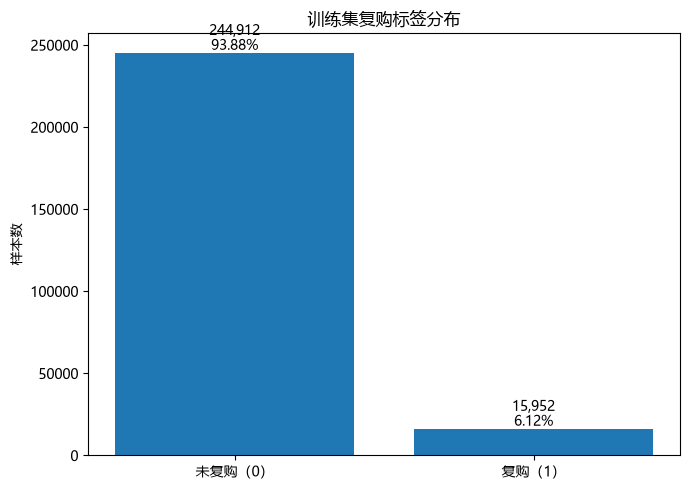

In [17]:
# ============================================================
# 12. 目标变量 label 分布
#
# label = 0：没有复购
# label = 1：发生复购
#
# 目的：
# 判断训练数据是否存在类别不平衡。
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. 统计标签数量
# ------------------------------------------------------------

label_summary = (
    train["label"]
    .value_counts()
    .sort_index()
    .rename_axis("label")
    .reset_index(name="样本数")
)

label_summary["占比"] = (
    label_summary["样本数"] / len(train)
)

display(label_summary)


# ------------------------------------------------------------
# 2. 绘制标签分布
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    ["未复购（0）", "复购（1）"],
    label_summary["样本数"]
)

ax.set_title("训练集复购标签分布")
ax.set_ylabel("样本数")

# 在柱子顶部标注数量和比例
for bar, count, rate in zip(
    bars,
    label_summary["样本数"],
    label_summary["占比"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n{rate:.2%}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# 13. 年龄段与复购率分析
#
# 目的：
# 比较不同年龄段：
# 1. 有多少训练样本
# 2. 有多少复购样本
# 3. 复购率是否存在明显差异
# ============================================================

# ------------------------------------------------------------
# 1. 创建用于分析的年龄字段
# ------------------------------------------------------------

train_profile["age_code"] = (
    train_profile["age_range"]
    .fillna(0)
    .astype(int)
)


# 官方年龄编码对应关系
age_mapping = {
    0: "未知",
    1: "<18",
    2: "18-24",
    3: "25-29",
    4: "30-34",
    5: "35-39",
    6: "40-49",
    7: "≥50（编码7）",
    8: "≥50（编码8）"
}

train_profile["年龄段"] = (
    train_profile["age_code"]
    .map(age_mapping)
)


# ------------------------------------------------------------
# 2. 统计每个年龄段的样本数和复购率
# ------------------------------------------------------------

age_summary = (
    train_profile
    .groupby(
        ["age_code", "年龄段"],
        observed=True
    )
    .agg(
        样本数=("label", "size"),
        复购样本数=("label", "sum"),
        复购率=("label", "mean"),
        用户数=("user_id", "nunique")
    )
    .reset_index()
    .sort_values("age_code")
)

display(
    age_summary.style.format({
        "样本数": "{:,}",
        "复购样本数": "{:,}",
        "用户数": "{:,}",
        "复购率": "{:.2%}"
    })
)

,age_code,年龄段,样本数,复购样本数,复购率,用户数
0,0,未知,"57,062","3,322",5.82%,"47,580"
1,1,<18,13,0,0.00%,11
2,2,18-24,"31,026","1,531",4.93%,"26,376"
3,3,25-29,"69,369","4,080",5.88%,"55,873"
4,4,30-34,"51,235","3,444",6.72%,"39,939"
5,5,35-39,"25,618","1,793",7.00%,"20,435"
6,6,40-49,"21,701","1,483",6.83%,"17,783"
7,7,≥50（编码7）,"4,120",249,6.04%,"3,460"
8,8,≥50（编码8）,720,50,6.94%,605


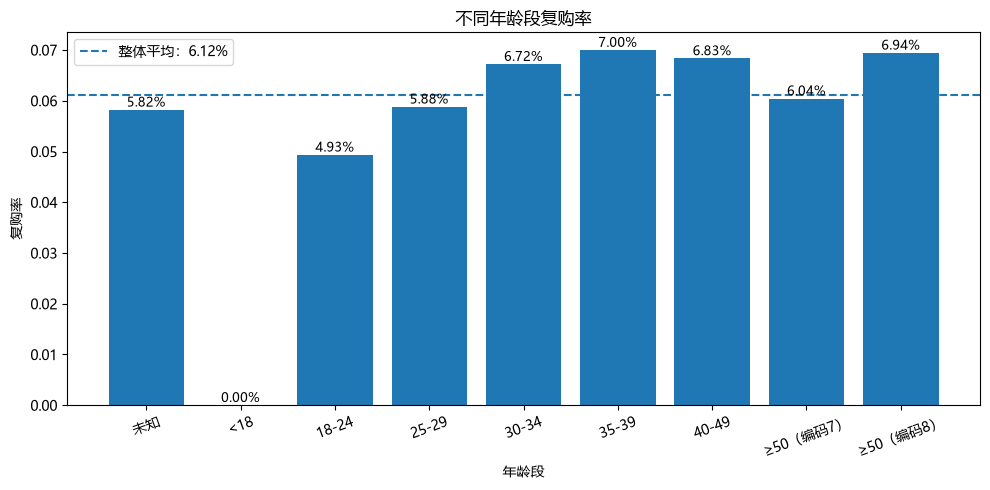

In [19]:
# ============================================================
# 14. 不同年龄段复购率
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    age_summary["年龄段"],
    age_summary["复购率"]
)

# 全体平均复购率
overall_rate = train["label"].mean()

ax.axhline(
    overall_rate,
    linestyle="--",
    linewidth=1.5,
    label=f"整体平均：{overall_rate:.2%}"
)

ax.set_title("不同年龄段复购率")
ax.set_xlabel("年龄段")
ax.set_ylabel("复购率")

ax.legend()

# 添加数据标签
for bar, rate in zip(
    bars,
    age_summary["复购率"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.2%}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# 15. 性别与复购率分析
# ============================================================

# ------------------------------------------------------------
# 1. 处理性别编码
# ------------------------------------------------------------

train_profile["gender_code"] = (
    train_profile["gender"]
    .fillna(2)
    .astype(int)
)

gender_mapping = {
    0: "女性",
    1: "男性",
    2: "未知"
}

train_profile["性别"] = (
    train_profile["gender_code"]
    .map(gender_mapping)
)


# ------------------------------------------------------------
# 2. 统计样本量和复购率
# ------------------------------------------------------------

gender_summary = (
    train_profile
    .groupby(
        ["gender_code", "性别"],
        observed=True
    )
    .agg(
        样本数=("label", "size"),
        复购样本数=("label", "sum"),
        复购率=("label", "mean"),
        用户数=("user_id", "nunique")
    )
    .reset_index()
    .sort_values("gender_code")
)

display(
    gender_summary.style.format({
        "样本数": "{:,}",
        "复购样本数": "{:,}",
        "用户数": "{:,}",
        "复购率": "{:.2%}"
    })
)

,gender_code,性别,样本数,复购样本数,复购率,用户数
0,0,女性,"176,414","11,387",6.45%,"143,091"
1,1,男性,"73,756","3,969",5.38%,"60,683"
2,2,未知,"10,694",596,5.57%,"8,288"


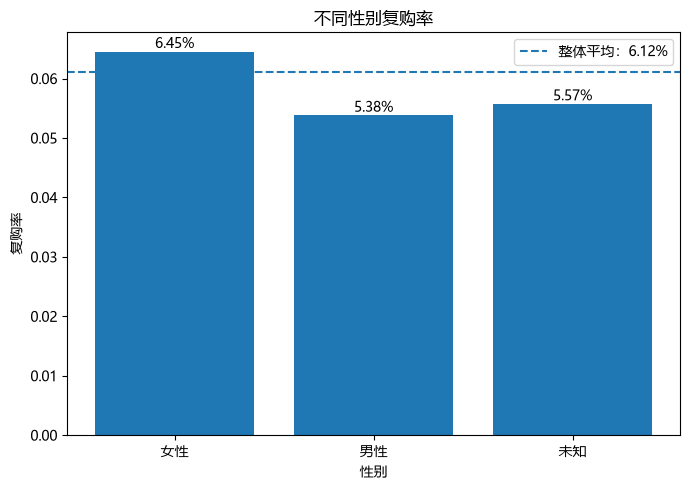

In [21]:
# ============================================================
# 16. 不同性别复购率
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    gender_summary["性别"],
    gender_summary["复购率"]
)

overall_rate = train["label"].mean()

ax.axhline(
    overall_rate,
    linestyle="--",
    linewidth=1.5,
    label=f"整体平均：{overall_rate:.2%}"
)

ax.set_title("不同性别复购率")
ax.set_xlabel("性别")
ax.set_ylabel("复购率")

ax.legend()

for bar, rate in zip(
    bars,
    gender_summary["复购率"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.2%}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# 17. 用户行为类型分布
#
# 目的：
# 统计 5492 万条历史行为中：
# 0 = 点击
# 1 = 加购
# 2 = 购买
# 3 = 收藏
#
# 使用分块读取，避免一次性加载 1.91GB 数据。
# ============================================================

from pathlib import Path
import pandas as pd

data_dir = Path("data/data_format1")
log_file = data_dir / "user_log_format1.csv"

# 每次读取 100 万行
chunk_size = 1_000_000

# 初始化行为计数
action_counts = {
    0: 0,   # 点击
    1: 0,   # 加购
    2: 0,   # 购买
    3: 0    # 收藏
}

total_rows = 0


# ------------------------------------------------------------
# 分块读取，只读取 action_type 一列
# ------------------------------------------------------------

reader = pd.read_csv(
    log_file,
    usecols=["action_type"],
    chunksize=chunk_size,
    dtype={"action_type": "int8"}
)

for chunk_number, chunk in enumerate(reader, start=1):

    # 当前数据块中各种行为的数量
    counts = chunk["action_type"].value_counts()

    # 累加到总计数
    for action in action_counts:
        action_counts[action] += int(
            counts.get(action, 0)
        )

    total_rows += len(chunk)

    # 每处理 10 个数据块打印一次进度
    if chunk_number % 10 == 0:
        print(
            f"已处理：{total_rows:,} 行"
        )


# ------------------------------------------------------------
# 整理统计结果
# ------------------------------------------------------------

action_mapping = {
    0: "点击",
    1: "加购",
    2: "购买",
    3: "收藏"
}

action_summary = pd.DataFrame({
    "action_type": list(action_counts.keys()),
    "行为": [
        action_mapping[i]
        for i in action_counts.keys()
    ],
    "行为次数": list(action_counts.values())
})

action_summary["占比"] = (
    action_summary["行为次数"]
    / action_summary["行为次数"].sum()
)


print("\n用户行为分布：")

display(
    action_summary.style.format({
        "行为次数": "{:,}",
        "占比": "{:.2%}"
    })
)

已处理：10,000,000 行
已处理：20,000,000 行
已处理：30,000,000 行
已处理：40,000,000 行
已处理：50,000,000 行

用户行为分布：


,action_type,行为,行为次数,占比
0,0,点击,"48,550,713",88.39%
1,1,加购,"76,750",0.14%
2,2,购买,"3,292,144",5.99%
3,3,收藏,"3,005,723",5.47%


In [23]:
# ============================================================
# 19. 按日期统计四类用户行为
#
# 目的：
# 观察点击、加购、购买、收藏在不同日期的变化趋势
# ============================================================

from pathlib import Path
import pandas as pd

data_dir = Path("data/data_format1")
log_file = data_dir / "user_log_format1.csv"

chunk_size = 1_000_000

# 用于累计每个“日期 × 行为类型”的次数
daily_action_counts = None

reader = pd.read_csv(
    log_file,
    usecols=["time_stamp", "action_type"],
    chunksize=chunk_size,
    dtype={
        "time_stamp": "int16",
        "action_type": "int8"
    }
)

for chunk_number, chunk in enumerate(reader, start=1):

    # 当前数据块：
    # 按日期和行为类型统计次数
    chunk_counts = (
        chunk
        .groupby(["time_stamp", "action_type"])
        .size()
    )

    # 将不同数据块的统计结果累加
    if daily_action_counts is None:
        daily_action_counts = chunk_counts
    else:
        daily_action_counts = (
            daily_action_counts
            .add(chunk_counts, fill_value=0)
        )

    if chunk_number % 10 == 0:
        print(
            f"已处理约 {chunk_number * chunk_size:,} 行"
        )


# ------------------------------------------------------------
# 整理成 DataFrame
# ------------------------------------------------------------

daily_action = (
    daily_action_counts
    .reset_index(name="行为次数")
)

daily_action["行为次数"] = (
    daily_action["行为次数"]
    .astype("int64")
)

# 映射行为名称
action_mapping = {
    0: "点击",
    1: "加购",
    2: "购买",
    3: "收藏"
}

daily_action["行为"] = (
    daily_action["action_type"]
    .map(action_mapping)
)

# 按日期排序
daily_action = (
    daily_action
    .sort_values(
        ["time_stamp", "action_type"]
    )
    .reset_index(drop=True)
)

print("日期范围：")
print(
    daily_action["time_stamp"].min(),
    "→",
    daily_action["time_stamp"].max()
)

print("\n前 10 行：")
display(daily_action.head(10))

已处理约 10,000,000 行
已处理约 20,000,000 行
已处理约 30,000,000 行
已处理约 40,000,000 行
已处理约 50,000,000 行
日期范围：
511 → 1112

前 10 行：


,time_stamp,action_type,行为次数,行为
0,511,1,62,加购
1,511,2,9597,购买
2,511,3,10385,收藏
3,512,1,89,加购
4,512,2,10421,购买
5,512,3,10194,收藏
6,513,1,84,加购
7,513,2,12601,购买
8,513,3,11045,收藏
9,514,1,107,加购


In [24]:
# ============================================================
# 20. 将 time_stamp 转换为可读日期
#
# 原始格式示例：
# 511  → 05-11
# 829  → 08-29
# 1011 → 10-11
# 1111 → 11-11
# ============================================================

# 将数字统一补成 4 位字符串
# 例如：
# 511 → "0511"
# 1111 → "1111"
daily_action["date_str"] = (
    daily_action["time_stamp"]
    .astype(str)
    .str.zfill(4)
)

# 拆分月份和日期
daily_action["month"] = (
    daily_action["date_str"]
    .str[:2]
    .astype(int)
)

daily_action["day"] = (
    daily_action["date_str"]
    .str[2:]
    .astype(int)
)

# ------------------------------------------------------------
# 创建真正的日期变量
#
# 这里使用 2014 年，是因为这套天猫双11数据对应的是
# 2014 年的行为记录。
# ------------------------------------------------------------

daily_action["date"] = pd.to_datetime(
    {
        "year": 2014,
        "month": daily_action["month"],
        "day": daily_action["day"]
    }
)

print(
    "转换后的日期范围：",
    daily_action["date"].min().date(),
    "→",
    daily_action["date"].max().date()
)

display(
    daily_action[
        [
            "time_stamp",
            "date",
            "action_type",
            "行为",
            "行为次数"
        ]
    ].head(10)
)

转换后的日期范围： 2014-05-11 → 2014-11-12


,time_stamp,date,action_type,行为,行为次数
0,511,2014-05-11,1,加购,62
1,511,2014-05-11,2,购买,9597
2,511,2014-05-11,3,收藏,10385
3,512,2014-05-12,1,加购,89
4,512,2014-05-12,2,购买,10421
5,512,2014-05-12,3,收藏,10194
6,513,2014-05-13,1,加购,84
7,513,2014-05-13,2,购买,12601
8,513,2014-05-13,3,收藏,11045
9,514,2014-05-14,1,加购,107


In [25]:
# ============================================================
# 21. 构造每日行为宽表
# ============================================================

daily_pivot = (
    daily_action
    .pivot_table(
        index="date",
        columns="行为",
        values="行为次数",
        aggfunc="sum",
        fill_value=0
    )
    .sort_index()
)

# 确保四类行为列都存在
for action in ["点击", "加购", "购买", "收藏"]:
    if action not in daily_pivot.columns:
        daily_pivot[action] = 0

# 固定列顺序
daily_pivot = daily_pivot[
    ["点击", "加购", "购买", "收藏"]
]

print("每日行为数据：")
display(daily_pivot.head())

print("\n双11附近：")
display(
    daily_pivot.loc[
        "2014-11-07":"2014-11-12"
    ]
)

每日行为数据：


行为,点击,加购,购买,收藏
date,,,,
2014-05-11,0,62,9597,10385
2014-05-12,0,89,10421,10194
2014-05-13,0,84,12601,11045
2014-05-14,0,107,12671,11610
2014-05-15,0,90,12220,11803



双11附近：


行为,点击,加购,购买,收藏
date,,,,
2014-11-07,777904,3068,12820,64054
2014-11-08,879656,3452,11721,73270
2014-11-09,1102507,4825,11393,88548
2014-11-10,2750192,11711,17249,161674
2014-11-11,9188104,14725,1223354,156450
2014-11-12,46,0,0,0


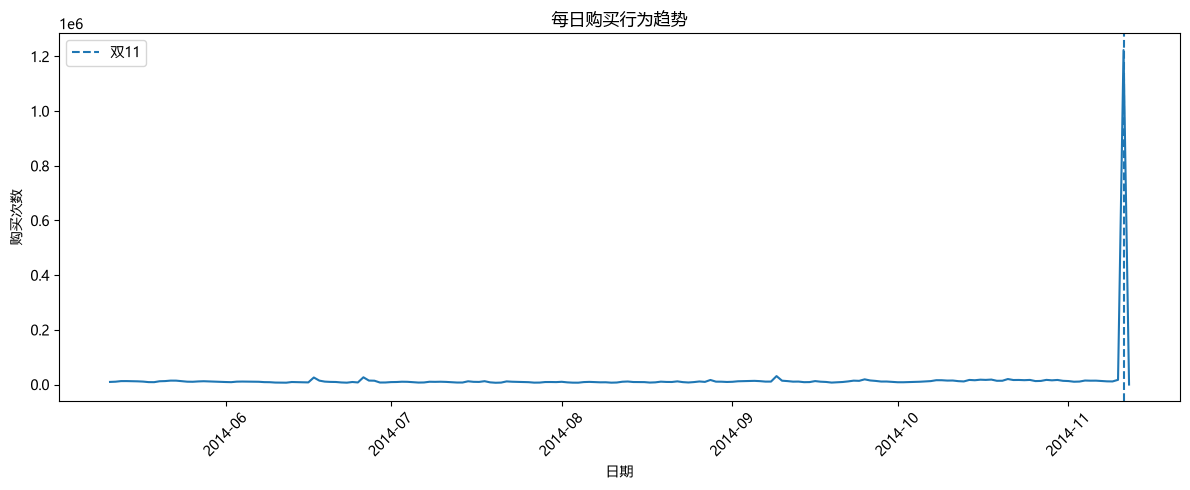

In [26]:
# ============================================================
# 22. 每日购买行为趋势
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    daily_pivot.index,
    daily_pivot["购买"],
    linewidth=1.5
)

# 标出双11
ax.axvline(
    pd.Timestamp("2014-11-11"),
    linestyle="--",
    linewidth=1.5,
    label="双11"
)

ax.set_title("每日购买行为趋势")
ax.set_xlabel("日期")
ax.set_ylabel("购买次数")

ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# 23. 找出四类行为的峰值日期
# ============================================================

peak_results = []

for action in ["点击", "加购", "购买", "收藏"]:

    peak_date = daily_pivot[action].idxmax()
    peak_count = daily_pivot[action].max()

    peak_results.append({
        "行为": action,
        "峰值日期": peak_date.date(),
        "峰值次数": int(peak_count)
    })

peak_summary = pd.DataFrame(peak_results)

display(
    peak_summary.style.format({
        "峰值次数": "{:,}"
    })
)

,行为,峰值日期,峰值次数
0,点击,2014-11-11,"9,188,104"
1,加购,2014-11-11,"14,725"
2,购买,2014-11-11,"1,223,354"
3,收藏,2014-11-10,"161,674"


In [28]:
# ============================================================
# 24. 双11行为放大效应
#
# 目的：
# 比较双11当天与双11前常态期（11月1日-11月9日）的行为水平
#
# 为什么不使用11月10日作为基准？
# 因为11月10日已经出现明显的预热效应，
# 特别是收藏行为已经达到峰值。
#
# 为什么不使用11月12日？
# 因为11月12日明显属于不完整日志日。
# ============================================================

# ------------------------------------------------------------
# 1. 定义双11前的基准期
# ------------------------------------------------------------

baseline = daily_pivot.loc[
    "2014-11-01":"2014-11-09"
]

# 计算基准期每日平均行为次数
baseline_mean = baseline.mean()


# ------------------------------------------------------------
# 2. 获取11月10日和11月11日数据
# ------------------------------------------------------------

nov10 = daily_pivot.loc["2014-11-10"]
nov11 = daily_pivot.loc["2014-11-11"]


# ------------------------------------------------------------
# 3. 计算相对基准期的放大倍数
# ------------------------------------------------------------

double11_summary = pd.DataFrame({
    "双11前日均": baseline_mean,
    "11月10日": nov10,
    "11月11日": nov11
})

double11_summary["11月10日放大倍数"] = (
    double11_summary["11月10日"]
    / double11_summary["双11前日均"]
)

double11_summary["11月11日放大倍数"] = (
    double11_summary["11月11日"]
    / double11_summary["双11前日均"]
)

# 行为名称放到普通列
double11_summary = (
    double11_summary
    .reset_index()
    .rename(columns={"行为": "行为类型"})
)

display(
    double11_summary.style.format({
        "双11前日均": "{:,.0f}",
        "11月10日": "{:,.0f}",
        "11月11日": "{:,.0f}",
        "11月10日放大倍数": "{:.2f}×",
        "11月11日放大倍数": "{:.2f}×"
    })
)

,行为类型,双11前日均,11月10日,11月11日,11月10日放大倍数,11月11日放大倍数
0,点击,"711,001","2,750,192","9,188,104",3.87×,12.92×
1,加购,"2,707","11,711","14,725",4.33×,5.44×
2,购买,"12,560","17,249","1,223,354",1.37×,97.40×
3,收藏,"60,242","161,674","156,450",2.68×,2.60×


In [29]:
# ============================================================
# 25. 双11前一天到双11当天的行为变化
# ============================================================

day_change = pd.DataFrame({
    "11月10日": nov10,
    "11月11日": nov11
})

day_change["变化率"] = (
    day_change["11月11日"]
    / day_change["11月10日"]
    - 1
)

day_change = (
    day_change
    .reset_index()
    .rename(columns={"行为": "行为类型"})
)

display(
    day_change.style.format({
        "11月10日": "{:,.0f}",
        "11月11日": "{:,.0f}",
        "变化率": "{:+.2%}"
    })
)

,行为类型,11月10日,11月11日,变化率
0,点击,"2,750,192","9,188,104",+234.09%
1,加购,"11,711","14,725",+25.74%
2,购买,"17,249","1,223,354",+6992.32%
3,收藏,"161,674","156,450",-3.23%


In [30]:
# ============================================================
# 26. 构造用户层面的行为次数特征
#
# 目的：
# 对每个用户统计：
# 1. 点击次数
# 2. 加购次数
# 3. 购买次数
# 4. 收藏次数
# 5. 总交互次数
#
# 这些是后续用户特征工程的基础。
# ============================================================

from pathlib import Path
import pandas as pd

data_dir = Path("data/data_format1")
log_file = data_dir / "user_log_format1.csv"

chunk_size = 1_000_000

# ------------------------------------------------------------
# 初始化结果
# index = user_id
# columns = 四种行为
# ------------------------------------------------------------

user_action_counts = None


# ------------------------------------------------------------
# 分块读取日志
# ------------------------------------------------------------

reader = pd.read_csv(
    log_file,
    usecols=["user_id", "action_type"],
    chunksize=chunk_size,
    dtype={
        "user_id": "int32",
        "action_type": "int8"
    }
)

for chunk_number, chunk in enumerate(reader, start=1):

    # 当前数据块中：
    # 统计每个用户四种行为分别发生多少次
    chunk_counts = (
        chunk
        .groupby(
            ["user_id", "action_type"]
        )
        .size()
        .unstack(
            fill_value=0
        )
    )

    # 将各个数据块的统计结果累加
    if user_action_counts is None:
        user_action_counts = chunk_counts
    else:
        user_action_counts = (
            user_action_counts
            .add(
                chunk_counts,
                fill_value=0
            )
        )

    if chunk_number % 10 == 0:
        print(
            f"已处理约 "
            f"{chunk_number * chunk_size:,} 行"
        )


# ------------------------------------------------------------
# 整理字段
# ------------------------------------------------------------

# 确保四类行为列都存在
for action in [0, 1, 2, 3]:
    if action not in user_action_counts.columns:
        user_action_counts[action] = 0

# 固定列顺序
user_action_counts = user_action_counts[
    [0, 1, 2, 3]
]

# 修改成容易理解的字段名
user_action_counts.columns = [
    "user_click_count",
    "user_cart_count",
    "user_buy_count",
    "user_favorite_count"
]

# user_id 从索引恢复为普通列
user_action_counts = (
    user_action_counts
    .reset_index()
)

# 计数统一转成整数
count_columns = [
    "user_click_count",
    "user_cart_count",
    "user_buy_count",
    "user_favorite_count"
]

user_action_counts[count_columns] = (
    user_action_counts[count_columns]
    .astype("int32")
)

# ------------------------------------------------------------
# 计算总交互次数
# ------------------------------------------------------------

user_action_counts["user_total_action_count"] = (
    user_action_counts[
        count_columns
    ].sum(axis=1)
)


print("用户行为特征规模：")
print(user_action_counts.shape)

print("\n前 5 行：")
display(user_action_counts.head())

已处理约 10,000,000 行
已处理约 20,000,000 行
已处理约 30,000,000 行
已处理约 40,000,000 行
已处理约 50,000,000 行
用户行为特征规模：
(424170, 6)

前 5 行：


,user_id,user_click_count,user_cart_count,user_buy_count,user_favorite_count,user_total_action_count
0,1,27,0,6,0,33
1,2,47,0,14,2,63
2,3,63,0,4,1,68
3,4,49,0,1,0,50
4,5,150,0,13,10,173


In [31]:
# ============================================================
# 27. 用户行为特征完整性验证
# ============================================================

print("=" * 60)
print("用户行为次数合计检查")
print("=" * 60)

print(
    "点击总次数：",
    f"{user_action_counts['user_click_count'].sum():,}"
)

print(
    "加购总次数：",
    f"{user_action_counts['user_cart_count'].sum():,}"
)

print(
    "购买总次数：",
    f"{user_action_counts['user_buy_count'].sum():,}"
)

print(
    "收藏总次数：",
    f"{user_action_counts['user_favorite_count'].sum():,}"
)

print(
    "总交互次数：",
    f"{user_action_counts['user_total_action_count'].sum():,}"
)

print("\n用户数量：")
print(f"{user_action_counts['user_id'].nunique():,}")

用户行为次数合计检查
点击总次数： 48,550,713
加购总次数： 76,750
购买总次数： 3,292,144
收藏总次数： 3,005,723
总交互次数： 54,925,330

用户数量：
424,170


In [32]:
# ============================================================
# 28. 构造用户行为占比特征
#
# 这些特征用于描述：
# 一个用户的历史行为结构更偏向浏览，
# 还是更偏向实际购买。
# ============================================================

user_action_counts["user_click_ratio"] = (
    user_action_counts["user_click_count"]
    / user_action_counts["user_total_action_count"]
)

user_action_counts["user_cart_ratio"] = (
    user_action_counts["user_cart_count"]
    / user_action_counts["user_total_action_count"]
)

user_action_counts["user_buy_ratio"] = (
    user_action_counts["user_buy_count"]
    / user_action_counts["user_total_action_count"]
)

user_action_counts["user_favorite_ratio"] = (
    user_action_counts["user_favorite_count"]
    / user_action_counts["user_total_action_count"]
)

display(
    user_action_counts.head()
)

,user_id,user_click_count,user_cart_count,user_buy_count,user_favorite_count,user_total_action_count,user_click_ratio,user_cart_ratio,user_buy_ratio,user_favorite_ratio
0,1,27,0,6,0,33,0.818182,0.0,0.181818,0.000000
1,2,47,0,14,2,63,0.746032,0.0,0.222222,0.031746
2,3,63,0,4,1,68,0.926471,0.0,0.058824,0.014706
3,4,49,0,1,0,50,0.980000,0.0,0.020000,0.000000
4,5,150,0,13,10,173,0.867052,0.0,0.075145,0.057803


In [33]:
# ============================================================
# 29. 用户行为特征 × 复购标签
# ============================================================

train_user_feature = train.merge(
    user_action_counts,
    on="user_id",
    how="left",
    validate="many_to_one"
)

print("合并后规模：")
print(train_user_feature.shape)

# ------------------------------------------------------------
# 按 label 比较两类用户的平均行为水平
# ------------------------------------------------------------

compare_columns = [
    "user_total_action_count",
    "user_click_count",
    "user_cart_count",
    "user_buy_count",
    "user_favorite_count",
    "user_buy_ratio"
]

user_feature_compare = (
    train_user_feature
    .groupby("label")[compare_columns]
    .mean()
    .T
)

user_feature_compare.columns = [
    "未复购用户",
    "复购用户"
]

user_feature_compare["复购/未复购倍数"] = (
    user_feature_compare["复购用户"]
    / user_feature_compare["未复购用户"]
)

display(
    user_feature_compare.style.format({
        "未复购用户": "{:.3f}",
        "复购用户": "{:.3f}",
        "复购/未复购倍数": "{:.2f}×"
    })
)

合并后规模：
(260864, 12)


,未复购用户,复购用户,复购/未复购倍数
user_total_action_count,140.558,171.501,1.22×
user_click_count,124.069,151.389,1.22×
user_cart_count,0.185,0.156,0.84×
user_buy_count,8.595,10.430,1.21×
user_favorite_count,7.709,9.526,1.24×
user_buy_ratio,0.100,0.101,1.01×


In [34]:
# ============================================================
# 30. 比较复购 / 未复购用户行为特征的中位数
#
# 为什么要看中位数？
# 电商用户行为通常存在明显长尾：
# 少量超级活跃用户可能把平均值拉得很高。
#
# 因此同时比较均值和中位数，可以判断结论是否稳健。
# ============================================================

compare_columns = [
    "user_total_action_count",
    "user_click_count",
    "user_cart_count",
    "user_buy_count",
    "user_favorite_count",
    "user_buy_ratio"
]

user_feature_median = (
    train_user_feature
    .groupby("label")[compare_columns]
    .median()
    .T
)

user_feature_median.columns = [
    "未复购用户中位数",
    "复购用户中位数"
]

user_feature_median["复购/未复购倍数"] = (
    user_feature_median["复购用户中位数"]
    / user_feature_median["未复购用户中位数"]
)

display(
    user_feature_median.style.format({
        "未复购用户中位数": "{:.3f}",
        "复购用户中位数": "{:.3f}",
        "复购/未复购倍数": "{:.2f}×"
    })
)

,未复购用户中位数,复购用户中位数,复购/未复购倍数
user_total_action_count,80.000,98.000,1.23×
user_click_count,68.000,83.000,1.22×
user_cart_count,0.000,0.000,nan×
user_buy_count,6.000,7.000,1.17×
user_favorite_count,1.000,1.000,1.00×
user_buy_ratio,0.075,0.075,1.00×


In [35]:
# ============================================================
# 31. 保存用户层面的基础行为特征
#
# 目的：
# 避免以后每次打开 Notebook 都重新扫描
# 5492 万条行为日志。
# ============================================================

from pathlib import Path

feature_dir = Path("feature")

# 如果文件夹不存在则创建
feature_dir.mkdir(exist_ok=True)

user_feature_path = (
    feature_dir / "user_basic_features_2026.csv"
)

user_action_counts.to_csv(
    user_feature_path,
    index=False
)

print("✅ 用户基础行为特征已保存")
print("保存位置：", user_feature_path)
print("数据规模：", user_action_counts.shape)

✅ 用户基础行为特征已保存
保存位置： feature\user_basic_features_2026.csv
数据规模： (424170, 10)


In [36]:
# ============================================================
# 32. 构造目标 user × merchant 列表
#
# 目的：
# 只保留训练集和测试集中真正需要建模的
# user_id × merchant_id 组合。
#
# 这样后面处理5492万条日志时，
# 不需要为无关的用户 × 商家组合计算特征。
# ============================================================

target_pairs = pd.concat(
    [
        train[["user_id", "merchant_id"]],
        test[["user_id", "merchant_id"]]
    ],
    ignore_index=True
)

# 理论上训练集和测试集之间不会存在重复目标 pair，
# 但这里仍做一次保险去重。
target_pairs = (
    target_pairs
    .drop_duplicates(
        subset=["user_id", "merchant_id"]
    )
    .reset_index(drop=True)
)

print("需要构造特征的 user × merchant 数量：")
print(f"{len(target_pairs):,}")

print("\n前 5 行：")
display(target_pairs.head())

需要构造特征的 user × merchant 数量：
522,341

前 5 行：


,user_id,merchant_id
0,34176,3906
1,34176,121
2,34176,4356
3,34176,2217
4,230784,4818


In [37]:
# ============================================================
# 33. 构造 user × merchant 行为次数特征
#
# 对每一个目标 user × merchant 统计：
# 1. 对该商家的点击次数
# 2. 对该商家的加购次数
# 3. 对该商家的购买次数
# 4. 对该商家的收藏次数
#
# 这是整个项目非常核心的一类特征。
# ============================================================

from pathlib import Path
import pandas as pd

data_dir = Path("data/data_format1")
log_file = data_dir / "user_log_format1.csv"

chunk_size = 1_000_000

# ------------------------------------------------------------
# 为了加快 merge，先压缩整数类型
# ------------------------------------------------------------

target_pairs_small = target_pairs.copy()

target_pairs_small["user_id"] = (
    target_pairs_small["user_id"]
    .astype("int32")
)

target_pairs_small["merchant_id"] = (
    target_pairs_small["merchant_id"]
    .astype("int32")
)


# ------------------------------------------------------------
# 用于累计不同数据块的 user × merchant × action 计数
# ------------------------------------------------------------

pair_action_counts = None


reader = pd.read_csv(
    log_file,
    usecols=[
        "user_id",
        "seller_id",
        "action_type"
    ],
    chunksize=chunk_size,
    dtype={
        "user_id": "int32",
        "seller_id": "int32",
        "action_type": "int8"
    }
)


for chunk_number, chunk in enumerate(reader, start=1):

    # seller_id 与训练集里的 merchant_id
    # 表示同一个商家维度，因此统一字段名称
    chunk = chunk.rename(
        columns={"seller_id": "merchant_id"}
    )

    # --------------------------------------------------------
    # 只保留训练/测试集中真正需要预测的目标 pair
    # --------------------------------------------------------

    matched = chunk.merge(
        target_pairs_small,
        on=["user_id", "merchant_id"],
        how="inner"
    )

    # --------------------------------------------------------
    # 当前数据块中：
    # 统计每个 user × merchant 的四类行为次数
    # --------------------------------------------------------

    if not matched.empty:

        chunk_counts = (
            matched
            .groupby(
                [
                    "user_id",
                    "merchant_id",
                    "action_type"
                ]
            )
            .size()
            .unstack(fill_value=0)
        )

        # 不同数据块之间累计
        if pair_action_counts is None:
            pair_action_counts = chunk_counts
        else:
            pair_action_counts = (
                pair_action_counts
                .add(
                    chunk_counts,
                    fill_value=0
                )
            )

    if chunk_number % 10 == 0:
        print(
            f"已处理约 "
            f"{chunk_number * chunk_size:,} 行"
        )

已处理约 10,000,000 行
已处理约 20,000,000 行
已处理约 30,000,000 行
已处理约 40,000,000 行
已处理约 50,000,000 行


In [38]:
# ============================================================
# 34. 整理 user × merchant 行为次数特征
# ============================================================

# 确保四种行为列都存在
for action in [0, 1, 2, 3]:
    if action not in pair_action_counts.columns:
        pair_action_counts[action] = 0

# 固定列顺序
pair_action_counts = pair_action_counts[
    [0, 1, 2, 3]
]

# 重命名
pair_action_counts.columns = [
    "um_click_count",
    "um_cart_count",
    "um_buy_count",
    "um_favorite_count"
]

# 恢复普通列
pair_action_counts = (
    pair_action_counts
    .reset_index()
)

# 计数转为整数
um_count_columns = [
    "um_click_count",
    "um_cart_count",
    "um_buy_count",
    "um_favorite_count"
]

pair_action_counts[um_count_columns] = (
    pair_action_counts[um_count_columns]
    .astype("int32")
)

# ------------------------------------------------------------
# 与完整目标 pair 合并
#
# 理论上某些目标 pair 可能没有相应行为记录，
# 这时行为次数应该填 0。
# ------------------------------------------------------------

user_merchant_features = target_pairs.merge(
    pair_action_counts,
    on=["user_id", "merchant_id"],
    how="left",
    validate="one_to_one"
)

user_merchant_features[um_count_columns] = (
    user_merchant_features[um_count_columns]
    .fillna(0)
    .astype("int32")
)

# 总互动次数
user_merchant_features["um_total_action_count"] = (
    user_merchant_features[
        um_count_columns
    ].sum(axis=1)
)

print("user × merchant 特征规模：")
print(user_merchant_features.shape)

print("\n前 10 行：")
display(user_merchant_features.head(10))

user × merchant 特征规模：
(522341, 7)

前 10 行：


,user_id,merchant_id,um_click_count,um_cart_count,um_buy_count,um_favorite_count,um_total_action_count
0,34176,3906,36,0,1,2,39
1,34176,121,13,0,1,0,14
2,34176,4356,12,0,6,0,18
3,34176,2217,1,0,1,0,2
4,230784,4818,7,0,1,0,8
5,362112,2618,0,0,1,0,1
6,34944,2051,2,0,1,0,3
7,231552,3828,78,0,5,0,83
8,231552,2124,6,0,1,0,7
9,232320,1168,2,0,1,1,4


In [39]:
# ============================================================
# 35. 用户 × 商家历史互动与未来复购
#
# 目的：
# 比较未来复购 / 未复购样本，
# 在历史上与目标商家的互动深度是否不同。
# ============================================================

train_um = train.merge(
    user_merchant_features,
    on=["user_id", "merchant_id"],
    how="left",
    validate="one_to_one"
)

compare_columns = [
    "um_total_action_count",
    "um_click_count",
    "um_cart_count",
    "um_buy_count",
    "um_favorite_count"
]

um_feature_compare = (
    train_um
    .groupby("label")[compare_columns]
    .mean()
    .T
)

um_feature_compare.columns = [
    "未复购",
    "复购"
]

um_feature_compare["复购/未复购倍数"] = (
    um_feature_compare["复购"]
    / um_feature_compare["未复购"]
)

display(
    um_feature_compare.style.format({
        "未复购": "{:.3f}",
        "复购": "{:.3f}",
        "复购/未复购倍数": "{:.2f}×"
    })
)

,未复购,复购,复购/未复购倍数
um_total_action_count,10.415,17.149,1.65×
um_click_count,8.703,14.825,1.70×
um_cart_count,0.024,0.021,0.88×
um_buy_count,1.321,1.623,1.23×
um_favorite_count,0.367,0.679,1.85×


In [40]:
# ============================================================
# 36. 保存基础 user × merchant 行为特征
#
# 目的：
# 避免以后重新扫描 5492 万条日志来计算基础行为次数。
# ============================================================

from pathlib import Path

feature_dir = Path("feature")
feature_dir.mkdir(exist_ok=True)

um_basic_path = (
    feature_dir / "user_merchant_basic_features_2026.csv"
)

user_merchant_features.to_csv(
    um_basic_path,
    index=False
)

print("✅ user × merchant 基础特征已保存")
print("保存位置：", um_basic_path)
print("数据规模：", user_merchant_features.shape)

✅ user × merchant 基础特征已保存
保存位置： feature\user_merchant_basic_features_2026.csv
数据规模： (522341, 7)


In [125]:
# ============================================================
# 37. 读取特征工程基础数据
# ============================================================

from pathlib import Path
from collections import Counter

import datetime
import os
import pickle
import time

import numpy as np
import pandas as pd
from scipy import sparse


# ------------------------------------------------------------
# 数据路径
# ------------------------------------------------------------

data_dir = Path("data/data_format1")


# ------------------------------------------------------------
# 用户基本信息
# ------------------------------------------------------------

user_info = pd.read_csv(
    data_dir / "user_info_format1.csv"
)

print("user_info：")
print(user_info.info())

display(user_info.head())

print("\nuser_info 缺失值：")
display(user_info.isnull().sum())


# ------------------------------------------------------------
# 用户行为日志
# ------------------------------------------------------------

user_log = pd.read_csv(
    data_dir / "user_log_format1.csv",
    dtype={
        "user_id": "int32",
        "item_id": "int32",
        "cat_id": "int32",
        "seller_id": "int32",
        "brand_id": "float32",
        "time_stamp": "int16",
        "action_type": "int8"
    }
)

print("\nuser_log：")
print(user_log.info())

display(user_log.head())

print("\nuser_log 缺失值：")
display(user_log.isnull().sum())

user_info：
<class 'pandas.DataFrame'>
RangeIndex: 424170 entries, 0 to 424169
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   user_id    424170 non-null  int64  
 1   age_range  421953 non-null  float64
 2   gender     417734 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 9.7 MB
None


,user_id,age_range,gender
0,1,3.0,1.0
1,2,3.0,0.0
2,3,3.0,0.0
3,4,0.0,0.0
4,5,5.0,0.0



user_info 缺失值：


user_id         0
age_range    2217
gender       6436
dtype: int64


user_log：
<class 'pandas.DataFrame'>
RangeIndex: 54925330 entries, 0 to 54925329
Data columns (total 7 columns):
 #   Column       Dtype  
---  ------       -----  
 0   user_id      int32  
 1   item_id      int32  
 2   cat_id       int32  
 3   seller_id    int32  
 4   brand_id     float32
 5   time_stamp   int16  
 6   action_type  int8   
dtypes: float32(1), int16(1), int32(4), int8(1)
memory usage: 1.2 GB
None


,user_id,item_id,cat_id,seller_id,brand_id,time_stamp,action_type
0,328862,323294,833,2882,2661.0,829,0
1,328862,844400,1271,2882,2661.0,829,0
2,328862,575153,1271,2882,2661.0,829,0
3,328862,996875,1271,2882,2661.0,829,0
4,328862,1086186,1271,1253,1049.0,829,0



user_log 缺失值：


user_id            0
item_id            0
cat_id             0
seller_id          0
brand_id       91015
time_stamp         0
action_type        0
dtype: int64

In [126]:
# ============================================================
# 38. 基础数据清洗
# ============================================================

# ------------------------------------------------------------
# 用户信息
# ------------------------------------------------------------

# 删除重复记录
user_info = user_info.drop_duplicates()

# 删除整行均为空的记录
user_info = user_info.dropna(
    axis=0,
    how="all"
)


# ------------------------------------------------------------
# 用户行为日志
# ------------------------------------------------------------

# 删除整行均为空的记录
user_log = user_log.dropna(
    axis=0,
    how="all"
)


# ------------------------------------------------------------
# 基础规模检查
# ------------------------------------------------------------

print("用户数量：", user_info["user_id"].nunique())
print("日志用户数量：", user_log["user_id"].nunique())
print("商家数量：", user_log["seller_id"].nunique())
print("商品数量：", user_log["item_id"].nunique())
print("品类数量：", user_log["cat_id"].nunique())
print("品牌数量：", user_log["brand_id"].nunique())

print("\n行为类型分布：")
display(
    user_log["action_type"]
    .value_counts()
    .sort_index()
)

用户数量： 424170
日志用户数量： 424170
商家数量： 4995
商品数量： 1090390
品类数量： 1658
品牌数量： 8443

行为类型分布：


action_type
0    48550713
1       76750
2     3292144
3     3005723
Name: count, dtype: int64

In [127]:
# ============================================================
# 39. 处理缺失值
# ============================================================

# ------------------------------------------------------------
# 1. 年龄
# 缺失值使用 0 表示未知
# ------------------------------------------------------------

user_info["age_range"] = (
    user_info["age_range"]
    .fillna(0)
)


# ------------------------------------------------------------
# 2. 性别
# 缺失值和编码 2 均使用众数填充
# ------------------------------------------------------------

gender_mode = (
    user_info["gender"]
    .mode()
    .iloc[0]
)

user_info["gender"] = (
    user_info["gender"]
    .fillna(gender_mode)
)

numeric_index = (
    user_info[
        user_info["gender"] == 2
    ]
    .index
)

user_info.loc[
    numeric_index,
    "gender"
] = gender_mode


print("user_info 是否仍有缺失值：")
display(user_info.isnull().any())


# ------------------------------------------------------------
# 3. 品牌
# 使用每个 seller_id 对应的 brand_id 众数填充
# ------------------------------------------------------------

print(
    "\n填充前 brand_id 缺失数量：",
    user_log["brand_id"].isnull().sum()
)

missing_index = (
    user_log[
        user_log["brand_id"].isnull()
    ]
    .index
)

seller_mode = (
    user_log
    .groupby("seller_id")["brand_id"]
    .agg(
        lambda x: x.mode().iloc[0]
    )
)

pick_up = (
    user_log.loc[
        missing_index,
        "seller_id"
    ]
    .map(seller_mode)
    .astype("float32")
)

user_log.loc[
    missing_index,
    "brand_id"
] = pick_up.to_numpy()

del pick_up
del seller_mode
del missing_index
del numeric_index


print(
    "填充后 brand_id 缺失数量：",
    user_log["brand_id"].isnull().sum()
)

print("\nuser_log 缺失值：")
display(user_log.isnull().sum())

user_info 是否仍有缺失值：


user_id      False
age_range    False
gender       False
dtype: bool


填充前 brand_id 缺失数量： 91015
填充后 brand_id 缺失数量： 0

user_log 缺失值：


user_id        0
item_id        0
cat_id         0
seller_id      0
brand_id       0
time_stamp     0
action_type    0
dtype: int64

In [128]:
# ============================================================
# 40. 构造用户人口属性特征
# ============================================================

# ------------------------------------------------------------
# 年龄哑编码
# ------------------------------------------------------------

df_age = pd.get_dummies(
    user_info["age_range"],
    prefix="age"
)


# ------------------------------------------------------------
# 合并 user_id、年龄和性别
# ------------------------------------------------------------

user_info = pd.concat(
    [
        user_info["user_id"],
        df_age,
        user_info["gender"]
    ],
    axis=1
)

del df_age


# ------------------------------------------------------------
# 检查结果
# ------------------------------------------------------------

print(user_info.info())

display(user_info.head())

print("\n数据规模：", user_info.shape)
print("\n字段：")
print(user_info.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 424170 entries, 0 to 424169
Data columns (total 11 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   user_id  424170 non-null  int64  
 1   age_0.0  424170 non-null  bool   
 2   age_1.0  424170 non-null  bool   
 3   age_2.0  424170 non-null  bool   
 4   age_3.0  424170 non-null  bool   
 5   age_4.0  424170 non-null  bool   
 6   age_5.0  424170 non-null  bool   
 7   age_6.0  424170 non-null  bool   
 8   age_7.0  424170 non-null  bool   
 9   age_8.0  424170 non-null  bool   
 10  gender   424170 non-null  float64
dtypes: bool(9), float64(1), int64(1)
memory usage: 10.1 MB
None


,user_id,age_0.0,age_1.0,age_2.0,age_3.0,age_4.0,age_5.0,age_6.0,age_7.0,age_8.0,gender
0,1,False,False,False,True,False,False,False,False,False,1.0
1,2,False,False,False,True,False,False,False,False,False,0.0
2,3,False,False,False,True,False,False,False,False,False,0.0
3,4,True,False,False,False,False,False,False,False,False,0.0
4,5,False,False,False,False,False,True,False,False,False,0.0



数据规模： (424170, 11)

字段：
['user_id', 'age_0.0', 'age_1.0', 'age_2.0', 'age_3.0', 'age_4.0', 'age_5.0', 'age_6.0', 'age_7.0', 'age_8.0', 'gender']


In [129]:
# ============================================================
# 41. 统计用户四类行为次数
# ============================================================

# 提取行为数据
totalActions = user_log[
    ["user_id", "action_type"]
].copy()

# 行为类型哑编码
# 0 = 点击
# 1 = 加入购物车
# 2 = 购买
# 3 = 收藏
df = pd.get_dummies(
    totalActions["action_type"],
    prefix="userTotalAction"
)

# 按用户汇总四类行为次数
totalActions = (
    pd.concat(
        [
            totalActions["user_id"],
            df
        ],
        axis=1
    )
    .groupby(
        ["user_id"],
        as_index=False
    )
    .sum()
)

del df

# 确保行为统计列为浮点型，便于后续统一标准化
action_cols = [
    "userTotalAction_0",
    "userTotalAction_1",
    "userTotalAction_2",
    "userTotalAction_3"
]

totalActions[action_cols] = (
    totalActions[action_cols]
    .astype("float64")
)

# 用户总交互次数
totalActions["userTotalAction"] = (
    totalActions["userTotalAction_0"]
    + totalActions["userTotalAction_1"]
    + totalActions["userTotalAction_2"]
    + totalActions["userTotalAction_3"]
)

totalActions.info()

display(
    totalActions.head()
)

<class 'pandas.DataFrame'>
RangeIndex: 424170 entries, 0 to 424169
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   user_id            424170 non-null  int32  
 1   userTotalAction_0  424170 non-null  float64
 2   userTotalAction_1  424170 non-null  float64
 3   userTotalAction_2  424170 non-null  float64
 4   userTotalAction_3  424170 non-null  float64
 5   userTotalAction    424170 non-null  float64
dtypes: float64(5), int32(1)
memory usage: 17.8 MB


,user_id,userTotalAction_0,userTotalAction_1,userTotalAction_2,userTotalAction_3,userTotalAction
0,1,27.0,0.0,6.0,0.0,33.0
1,2,47.0,0.0,14.0,2.0,63.0
2,3,63.0,0.0,4.0,1.0,68.0
3,4,49.0,0.0,1.0,0.0,50.0
4,5,150.0,0.0,13.0,10.0,173.0


In [130]:
# ============================================================
# 42. 用户总交互次数的相对水平
# ============================================================

print(
    "所有用户交互次数："
    + str(user_log.shape[0])
)

print(
    "所有用户数："
    + str(user_log["user_id"].nunique())
)

print(
    "所有用户平均交互次数："
    + str(
        user_log.shape[0]
        / user_log["user_id"].nunique()
    )
)

# 用户交互次数占全部交互次数的比例
totalActions["userTotalActionRatio"] = (
    totalActions["userTotalAction"]
    / user_log.shape[0]
)

# 用户交互次数与平均交互次数的差值
totalActions["userTotalActionDiff"] = (
    totalActions["userTotalAction"]
    - user_log.shape[0]
    / user_log["user_id"].nunique()
)

所有用户交互次数：54925330
所有用户数：424170
所有用户平均交互次数：129.48895490015795


In [131]:
# ============================================================
# 43. 用户点击次数的相对水平
# ============================================================

click_count = (
    user_log[
        user_log["action_type"] == 0
    ]
    .shape[0]
)

print(
    "所有用户点击次数："
    + str(click_count)
)

# 用户点击次数占全部点击次数的比例
totalActions["userClickRatio"] = (
    totalActions["userTotalAction_0"]
    / click_count
)

print(
    "用户平均点击次数："
    + str(
        click_count
        / user_log["user_id"].nunique()
    )
)

# 用户点击次数与平均点击次数的差值
totalActions["userClickDiff"] = (
    totalActions["userTotalAction_0"]
    - click_count
    / user_log["user_id"].nunique()
)

del click_count

所有用户点击次数：48550713
用户平均点击次数：114.46050640073555


In [132]:
# ============================================================
# 44. 用户加购次数的相对水平
# ============================================================

add_count = (
    user_log[
        user_log["action_type"] == 1
    ]
    .shape[0]
)

print(
    "所有用户加入购物车次数："
    + str(add_count)
)

# 用户加购次数占全部加购次数的比例
totalActions["userAddRatio"] = (
    totalActions["userTotalAction_1"]
    / add_count
)

print(
    "用户平均加入购物车次数："
    + str(
        add_count
        / user_log["user_id"].nunique()
    )
)

# 用户加购次数与平均加购次数的差值
totalActions["userAddDiff"] = (
    totalActions["userTotalAction_1"]
    - add_count
    / user_log["user_id"].nunique()
)

del add_count

所有用户加入购物车次数：76750
用户平均加入购物车次数：0.18094160360232925


In [133]:
# ============================================================
# 45. 用户购买次数的相对水平
# ============================================================

buy_count = (
    user_log[
        user_log["action_type"] == 2
    ]
    .shape[0]
)

print(
    "所有用户购买次数："
    + str(buy_count)
)

# 用户购买次数占全部购买次数的比例
totalActions["userBuyRatio"] = (
    totalActions["userTotalAction_2"]
    / buy_count
)

print(
    "用户平均购买次数："
    + str(
        buy_count
        / user_log["user_id"].nunique()
    )
)

# 用户购买次数与平均购买次数的差值
totalActions["userBuyDiff"] = (
    totalActions["userTotalAction_2"]
    - buy_count
    / user_log["user_id"].nunique()
)

del buy_count

所有用户购买次数：3292144
用户平均购买次数：7.761378692505364


In [134]:
# ============================================================
# 46. 用户收藏次数的相对水平
# ============================================================

save_count = (
    user_log[
        user_log["action_type"] == 3
    ]
    .shape[0]
)

print(
    "所有用户收藏次数："
    + str(save_count)
)

# 用户收藏次数占全部收藏次数的比例
totalActions["userSaveRatio"] = (
    totalActions["userTotalAction_3"]
    / save_count
)

print(
    "用户平均收藏次数："
    + str(
        save_count
        / user_log["user_id"].nunique()
    )
)

# 用户收藏次数与平均收藏次数的差值
totalActions["userSaveDiff"] = (
    totalActions["userTotalAction_3"]
    - save_count
    / user_log["user_id"].nunique()
)

del save_count

所有用户收藏次数：3005723
用户平均收藏次数：7.086128203314709


In [135]:
# ============================================================
# 47. 四类行为占用户自身总交互的比例
# ============================================================

totalActions["userClick_ratio"] = (
    totalActions["userTotalAction_0"]
    / totalActions["userTotalAction"]
)

totalActions["userAdd_ratio"] = (
    totalActions["userTotalAction_1"]
    / totalActions["userTotalAction"]
)

totalActions["userBuy_ratio"] = (
    totalActions["userTotalAction_2"]
    / totalActions["userTotalAction"]
)

totalActions["userSave_ratio"] = (
    totalActions["userTotalAction_3"]
    / totalActions["userTotalAction"]
)

In [136]:
# ============================================================
# 48. 构造购买转化特征
# ============================================================

# 点击 → 购买
totalActions["userTotalAction_0_ratio"] = (
    np.log1p(
        totalActions["userTotalAction_2"]
    )
    - np.log1p(
        totalActions["userTotalAction_0"]
    )
)

totalActions["userTotalAction_0_ratio_diff"] = (
    totalActions["userTotalAction_0_ratio"]
    - totalActions[
        "userTotalAction_0_ratio"
    ].mean()
)


# 加购 → 购买
totalActions["userTotalAction_1_ratio"] = (
    np.log1p(
        totalActions["userTotalAction_2"]
    )
    - np.log1p(
        totalActions["userTotalAction_1"]
    )
)

totalActions["userTotalAction_1_ratio_diff"] = (
    totalActions["userTotalAction_1_ratio"]
    - totalActions[
        "userTotalAction_1_ratio"
    ].mean()
)


# 收藏 → 购买
totalActions["userTotalAction_3_ratio"] = (
    np.log1p(
        totalActions["userTotalAction_2"]
    )
    - np.log1p(
        totalActions["userTotalAction_3"]
    )
)

totalActions["userTotalAction_3_ratio_diff"] = (
    totalActions["userTotalAction_3_ratio"]
    - totalActions[
        "userTotalAction_3_ratio"
    ].mean()
)


print(
    "行为特征规模：",
    totalActions.shape
)

totalActions.info()

行为特征规模： (424170, 26)
<class 'pandas.DataFrame'>
RangeIndex: 424170 entries, 0 to 424169
Data columns (total 26 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   user_id                       424170 non-null  int32  
 1   userTotalAction_0             424170 non-null  float64
 2   userTotalAction_1             424170 non-null  float64
 3   userTotalAction_2             424170 non-null  float64
 4   userTotalAction_3             424170 non-null  float64
 5   userTotalAction               424170 non-null  float64
 6   userTotalActionRatio          424170 non-null  float64
 7   userTotalActionDiff           424170 non-null  float64
 8   userClickRatio                424170 non-null  float64
 9   userClickDiff                 424170 non-null  float64
 10  userAddRatio                  424170 non-null  float64
 11  userAddDiff                   424170 non-null  float64
 12  userBuyRatio                  4241

In [137]:
# ============================================================
# 49. 标准化用户行为特征
# ============================================================

# 找出所有 float64 数值特征
numeric_cols = (
    totalActions
    .columns[
        totalActions.dtypes == "float64"
    ]
)

# 均值
numeric_col_means = (
    totalActions.loc[
        :,
        numeric_cols
    ]
    .mean()
)

# 标准差
numeric_col_std = (
    totalActions.loc[
        :,
        numeric_cols
    ]
    .std()
)

# Z-score 标准化
totalActions.loc[
    :,
    numeric_cols
] = (
    totalActions.loc[
        :,
        numeric_cols
    ]
    - numeric_col_means
) / numeric_col_std


display(
    totalActions.head()
)

,user_id,userTotalAction_0,userTotalAction_1,userTotalAction_2,userTotalAction_3,userTotalAction,userTotalActionRatio,userTotalActionDiff,userClickRatio,userClickDiff,...,userClick_ratio,userAdd_ratio,userBuy_ratio,userSave_ratio,userTotalAction_0_ratio,userTotalAction_0_ratio_diff,userTotalAction_1_ratio,userTotalAction_1_ratio_diff,userTotalAction_3_ratio,userTotalAction_3_ratio_diff
0,1,-0.505625,-0.204257,-0.222497,-0.355284,-0.513955,-0.513955,-0.513955,-0.505625,-0.505625,...,-0.248463,-0.184557,0.960101,-0.548872,0.993740,0.993740,0.160741,0.160741,0.879081,0.879081
1,2,-0.390001,-0.204257,0.788060,-0.255008,-0.354158,-0.354158,-0.354158,-0.390001,-0.390001,...,-0.822513,-0.184557,1.423089,-0.199305,1.243542,1.243542,1.127229,1.127229,0.613294,0.613294
2,3,-0.297502,-0.204257,-0.475136,-0.305146,-0.327525,-0.327525,-0.327525,-0.297502,-0.297502,...,0.613120,-0.184557,-0.449287,-0.386941,-0.308369,-0.308369,-0.265947,-0.265947,0.065761,0.065761
3,4,-0.378439,-0.204257,-0.854095,-0.355284,-0.423403,-0.423403,-0.423403,-0.378439,-0.378439,...,1.039019,-0.184557,-0.894163,-0.548872,-1.057774,-1.057774,-1.427917,-1.427917,-0.110505,-0.110505
4,5,0.205460,-0.204257,0.661741,0.146095,0.231765,0.231765,0.231765,0.205460,0.205460,...,0.140366,-0.184557,-0.262266,0.087622,-0.116691,-0.116691,1.039737,1.039737,-0.467538,-0.467538


In [138]:
# ============================================================
# 50. 合并用户行为特征
# ============================================================

user_info = pd.merge(
    user_info,
    totalActions,
    how="left",
    on=["user_id"]
)

del totalActions

user_info.info()

print(
    "\n当前用户特征规模：",
    user_info.shape
)

<class 'pandas.DataFrame'>
RangeIndex: 424170 entries, 0 to 424169
Data columns (total 36 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   user_id                       424170 non-null  int64  
 1   age_0.0                       424170 non-null  bool   
 2   age_1.0                       424170 non-null  bool   
 3   age_2.0                       424170 non-null  bool   
 4   age_3.0                       424170 non-null  bool   
 5   age_4.0                       424170 non-null  bool   
 6   age_5.0                       424170 non-null  bool   
 7   age_6.0                       424170 non-null  bool   
 8   age_7.0                       424170 non-null  bool   
 9   age_8.0                       424170 non-null  bool   
 10  gender                        424170 non-null  float64
 11  userTotalAction_0             424170 non-null  float64
 12  userTotalAction_1             424170 non-null  float64


In [139]:
# ============================================================
# 51. 统计用户行为广度
# ============================================================

# 不同商品数量
item_cnt = (
    user_log
    .groupby(["user_id"])["item_id"]
    .nunique()
)

# 不同品类数量
cat_cnt = (
    user_log
    .groupby(["user_id"])["cat_id"]
    .nunique()
)

# 不同商家数量
seller_cnt = (
    user_log
    .groupby(["user_id"])["seller_id"]
    .nunique()
)

# 不同品牌数量
brand_cnt = (
    user_log
    .groupby(["user_id"])["brand_id"]
    .nunique()
)

# 活跃天数
days_cnt = (
    user_log
    .groupby(["user_id"])["time_stamp"]
    .nunique()
)


# ------------------------------------------------------------
# 合并
# ------------------------------------------------------------

typeCount_result = pd.concat(
    [
        item_cnt,
        cat_cnt,
        seller_cnt,
        brand_cnt,
        days_cnt
    ],
    axis=1
)

typeCount_result.rename(
    columns={
        "item_id": "item_cnt",
        "cat_id": "cat_cnt",
        "seller_id": "seller_cnt",
        "brand_id": "brand_counts",
        "time_stamp": "active_days"
    },
    inplace=True
)

typeCount_result.reset_index(
    inplace=True
)

typeCount_result.info()

display(
    typeCount_result.head()
)

<class 'pandas.DataFrame'>
RangeIndex: 424170 entries, 0 to 424169
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   user_id       424170 non-null  int32
 1   item_cnt      424170 non-null  int64
 2   cat_cnt       424170 non-null  int64
 3   seller_cnt    424170 non-null  int64
 4   brand_counts  424170 non-null  int64
 5   active_days   424170 non-null  int64
dtypes: int32(1), int64(5)
memory usage: 17.8 MB


,user_id,item_cnt,cat_cnt,seller_cnt,brand_counts,active_days
0,1,12,6,9,9,5
1,2,43,14,14,15,9
2,3,45,19,23,22,13
3,4,28,13,12,12,10
4,5,87,40,56,59,30


In [140]:
# ============================================================
# 52. 标准化用户行为广度特征
# ============================================================

numeric_cols = [
    "item_cnt",
    "cat_cnt",
    "seller_cnt",
    "brand_counts",
    "active_days"
]

numeric_col_means = (
    typeCount_result[
        numeric_cols
    ]
    .mean()
)

numeric_col_std = (
    typeCount_result[
        numeric_cols
    ]
    .std()
)

typeCount_result[
    numeric_cols
] = (
    typeCount_result[
        numeric_cols
    ]
    - numeric_col_means
) / numeric_col_std


display(
    typeCount_result.head()
)

,user_id,item_cnt,cat_cnt,seller_cnt,brand_counts,active_days
0,1,-0.619293,-0.985184,-0.713461,-0.721148,-0.839753
1,2,-0.315566,-0.507574,-0.565709,-0.539438,-0.557186
2,3,-0.295971,-0.209068,-0.299757,-0.327442,-0.274619
3,4,-0.462530,-0.567275,-0.624810,-0.630293,-0.486544
4,5,0.115530,1.044659,0.675404,0.793106,0.926290


In [141]:
# ============================================================
# 53. 合并用户行为广度特征
# ============================================================

user_info = pd.merge(
    user_info,
    typeCount_result,
    how="left",
    on=["user_id"]
)

del typeCount_result
del item_cnt
del cat_cnt
del seller_cnt
del brand_cnt
del days_cnt


user_info.info()

print(
    "\n当前用户特征规模：",
    user_info.shape
)

<class 'pandas.DataFrame'>
RangeIndex: 424170 entries, 0 to 424169
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   user_id                       424170 non-null  int64  
 1   age_0.0                       424170 non-null  bool   
 2   age_1.0                       424170 non-null  bool   
 3   age_2.0                       424170 non-null  bool   
 4   age_3.0                       424170 non-null  bool   
 5   age_4.0                       424170 non-null  bool   
 6   age_5.0                       424170 non-null  bool   
 7   age_6.0                       424170 non-null  bool   
 8   age_7.0                       424170 non-null  bool   
 9   age_8.0                       424170 non-null  bool   
 10  gender                        424170 non-null  float64
 11  userTotalAction_0             424170 non-null  float64
 12  userTotalAction_1             424170 non-null  float64


In [142]:
# ============================================================
# 54. 统计双十一前重复购买的商家数量
# ============================================================

repeatSellerCount = user_log[
    [
        "user_id",
        "seller_id",
        "time_stamp",
        "action_type"
    ]
].copy()


# ------------------------------------------------------------
# 仅保留双十一之前的购买行为
# ------------------------------------------------------------

repeatSellerCount = repeatSellerCount[
    (repeatSellerCount["action_type"] == 2)
    & (repeatSellerCount["time_stamp"] < 1111)
].copy()


# ------------------------------------------------------------
# 同一天对同一商家的重复购买记录只保留一次
# ------------------------------------------------------------

repeatSellerCount = (
    repeatSellerCount
    .drop_duplicates()
)


# ------------------------------------------------------------
# 统计用户在每个商家的不同购买日期数
# ------------------------------------------------------------

repeatSellerCount = (
    repeatSellerCount
    .groupby(
        [
            "user_id",
            "seller_id"
        ]
    )["time_stamp"]
    .count()
    .reset_index()
)


# ------------------------------------------------------------
# 保留购买日期超过1天的商家
# ------------------------------------------------------------

repeatSellerCount = repeatSellerCount[
    repeatSellerCount["time_stamp"] > 1
]


# ------------------------------------------------------------
# 统计每个用户重复购买过多少个商家
# ------------------------------------------------------------

repeatSellerCount = (
    repeatSellerCount
    .groupby(["user_id"])["seller_id"]
    .count()
    .reset_index()
)

repeatSellerCount.rename(
    columns={
        "seller_id": "repeat_seller_count1"
    },
    inplace=True
)


repeatSellerCount.info()

display(
    repeatSellerCount.head()
)

<class 'pandas.DataFrame'>
RangeIndex: 74765 entries, 0 to 74764
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   user_id               74765 non-null  int32
 1   repeat_seller_count1  74765 non-null  int64
dtypes: int32(1), int64(1)
memory usage: 876.3 KB


,user_id,repeat_seller_count1
0,6,1
1,8,2
2,14,4
3,21,4
4,25,1


In [143]:
# ============================================================
# 55. 补齐重复购买特征
# ============================================================

repeatSellerCount = pd.merge(
    user_info[["user_id"]],
    repeatSellerCount,
    how="left",
    on=["user_id"]
)


# ------------------------------------------------------------
# 没有重复购买行为的用户填0
# ------------------------------------------------------------

repeatSellerCount[
    "repeat_seller_count1"
] = (
    repeatSellerCount[
        "repeat_seller_count1"
    ]
    .fillna(0)
)


# ------------------------------------------------------------
# 是否存在重复购买商家
# ------------------------------------------------------------

repeatSellerCount[
    "repeat_seller1"
] = (
    repeatSellerCount[
        "repeat_seller_count1"
    ]
    .map(
        lambda x: 1
        if x != 0
        else 0
    )
)


repeatSellerCount.info()

display(
    repeatSellerCount.head()
)

<class 'pandas.DataFrame'>
RangeIndex: 424170 entries, 0 to 424169
Data columns (total 3 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   user_id               424170 non-null  int64  
 1   repeat_seller_count1  424170 non-null  float64
 2   repeat_seller1        424170 non-null  int64  
dtypes: float64(1), int64(2)
memory usage: 9.7 MB


,user_id,repeat_seller_count1,repeat_seller1
0,1,0.0,0
1,2,0.0,0
2,3,0.0,0
3,4,0.0,0
4,5,0.0,0


In [144]:
# ============================================================
# 56. 标准化重复购买商家数量
# ============================================================

numeric_cols = [
    "repeat_seller_count1"
]

numeric_col_means = (
    repeatSellerCount[
        numeric_cols
    ]
    .mean()
)

numeric_col_std = (
    repeatSellerCount[
        numeric_cols
    ]
    .std()
)

repeatSellerCount[
    numeric_cols
] = (
    repeatSellerCount[
        numeric_cols
    ]
    - numeric_col_means
) / numeric_col_std


display(
    repeatSellerCount.head()
)

,user_id,repeat_seller_count1,repeat_seller1
0,1,-0.347519,0
1,2,-0.347519,0
2,3,-0.347519,0
3,4,-0.347519,0
4,5,-0.347519,0


In [145]:
# ============================================================
# 57. 合并用户重复购买特征
# ============================================================

user_info = pd.merge(
    user_info,
    repeatSellerCount,
    how="left",
    on=["user_id"]
)

del repeatSellerCount


user_info.info()

print(
    "\n当前用户特征规模：",
    user_info.shape
)

<class 'pandas.DataFrame'>
RangeIndex: 424170 entries, 0 to 424169
Data columns (total 43 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   user_id                       424170 non-null  int64  
 1   age_0.0                       424170 non-null  bool   
 2   age_1.0                       424170 non-null  bool   
 3   age_2.0                       424170 non-null  bool   
 4   age_3.0                       424170 non-null  bool   
 5   age_4.0                       424170 non-null  bool   
 6   age_5.0                       424170 non-null  bool   
 7   age_6.0                       424170 non-null  bool   
 8   age_7.0                       424170 non-null  bool   
 9   age_8.0                       424170 non-null  bool   
 10  gender                        424170 non-null  float64
 11  userTotalAction_0             424170 non-null  float64
 12  userTotalAction_1             424170 non-null  float64


In [147]:
# ============================================================
# 调整时间字段数据类型
# ============================================================

user_log["time_stamp"] = (
    user_log["time_stamp"]
    .astype("int64")
)

print(
    "time_stamp dtype：",
    user_log["time_stamp"].dtype
)

time_stamp dtype： int64


In [152]:
# ============================================================
# 58. 统计每月行为次数
#
# 每个月生成：
# Action_0 = 点击次数
# Action_1 = 加购次数
# Action_2 = 购买次数
# Action_3 = 收藏次数
# Action   = 总行为次数
# ============================================================

monthActionsCount = user_log[
    [
        "user_id",
        "time_stamp",
        "action_type"
    ]
]

result = []

for i in range(5, 12):

    start = int(str(i) + "00")
    end = int(str(i) + "30")

    # 获取当月数据
    example = monthActionsCount[
        (monthActionsCount["time_stamp"] >= start)
        & (monthActionsCount["time_stamp"] < end)
    ].copy()

    # 行为类型哑编码
    df = pd.get_dummies(
        example["action_type"],
        prefix="%d_Action" % i,
        dtype="float64"
    )

    # 当月总行为次数
    df[str(i) + "_Action"] = (
        df[str(i) + "_Action_0"]
        + df[str(i) + "_Action_1"]
        + df[str(i) + "_Action_2"]
        + df[str(i) + "_Action_3"]
    )

    # 将日期转换为月份
    example.loc[:, "time_stamp"] = (
        example["time_stamp"]
        .apply(
            lambda x:
            int(str(x)[0])
            if len(str(x)) == 3
            else int(str(x)[:2])
        )
    )

    # 按用户和月份汇总
    month_result = (
        pd.concat(
            [
                example,
                df
            ],
            axis=1
        )
        .groupby(
            [
                "user_id",
                "time_stamp"
            ],
            as_index=False
        )
        .sum()
    )

    result.append(
        month_result
    )

    print(
        f"{i} 月完成：",
        month_result.shape
    )

    del example
    del df

5 月完成： (207122, 8)
6 月完成： (279272, 8)
7 月完成： (264255, 8)
8 月完成： (265719, 8)
9 月完成： (301329, 8)
10 月完成： (331474, 8)
11 月完成： (424170, 8)


In [149]:
# ============================================================
# 59. 合并月度行为特征
# ============================================================

for i in range(5, 12):

    monthly_cols = [
        "user_id",
        str(i) + "_Action_0",
        str(i) + "_Action_1",
        str(i) + "_Action_2",
        str(i) + "_Action_3",
        str(i) + "_Action"
    ]

    user_info = pd.merge(
        user_info,
        result[i - 5][monthly_cols],
        how="left",
        on=["user_id"]
    )

    # 当月没有行为的用户填0
    user_info.fillna(
        0,
        inplace=True
    )


print(
    "合并后用户特征规模：",
    user_info.shape
)

print(
    "\n新增月度字段："
)

print(
    user_info.columns[43:].tolist()
)

合并后用户特征规模： (424170, 78)

新增月度字段：
['5_Action_0', '5_Action_1', '5_Action_2', '5_Action_3', '5_Action', '6_Action_0', '6_Action_1', '6_Action_2', '6_Action_3', '6_Action', '7_Action_0', '7_Action_1', '7_Action_2', '7_Action_3', '7_Action', '8_Action_0', '8_Action_1', '8_Action_2', '8_Action_3', '8_Action', '9_Action_0', '9_Action_1', '9_Action_2', '9_Action_3', '9_Action', '10_Action_0', '10_Action_1', '10_Action_2', '10_Action_3', '10_Action', '11_Action_0', '11_Action_1', '11_Action_2', '11_Action_3', '11_Action']


In [151]:
# ============================================================
# 60. 标准化月度行为特征
# ============================================================

# 35个月度行为字段
numeric_cols = (
    user_info
    .columns[43:]
)

# 标准化后会产生小数，
# 先将字段转为浮点型
user_info[numeric_cols] = (
    user_info[numeric_cols]
    .astype("float64")
)

# 均值
numeric_col_means = (
    user_info.loc[
        :,
        numeric_cols
    ]
    .mean()
)

# 标准差
numeric_col_std = (
    user_info.loc[
        :,
        numeric_cols
    ]
    .std()
)

# Z-score标准化
user_info.loc[
    :,
    numeric_cols
] = (
    user_info.loc[
        :,
        numeric_cols
    ]
    - numeric_col_means
) / numeric_col_std


display(
    user_info.head()
)

print(
    "\n最终用户特征规模：",
    user_info.shape
)

,user_id,age_0.0,age_1.0,age_2.0,age_3.0,age_4.0,age_5.0,age_6.0,age_7.0,age_8.0,...,10_Action_0,10_Action_1,10_Action_2,10_Action_3,10_Action,11_Action_0,11_Action_1,11_Action_2,11_Action_3,11_Action
0,1,False,False,False,True,False,False,False,False,False,...,-0.051206,-0.095484,0.523512,-0.277882,-0.053743,-0.455144,-0.174409,0.284542,-0.359062,-0.450978
1,2,False,False,False,True,False,False,False,False,False,...,-0.380864,-0.095484,0.523512,-0.277882,-0.353996,-0.650865,-0.174409,1.340056,-0.004993,-0.565257
2,3,False,False,False,True,False,False,False,False,False,...,-0.320926,-0.095484,-0.495248,-0.277882,-0.353996,-0.199201,-0.174409,-0.770972,-0.182027,-0.236705
3,4,True,False,False,False,False,False,False,False,False,...,-0.470771,-0.095484,-0.495248,-0.277882,-0.490475,-0.425033,-0.174409,-0.770972,-0.359062,-0.465263
4,5,False,False,False,False,False,True,False,False,False,...,0.518205,-0.095484,1.542273,0.160268,0.574059,-0.229312,-0.174409,-0.067296,-0.182027,-0.236705



最终用户特征规模： (424170, 78)


In [153]:
# ============================================================
# 61. 检查用户特征
# ============================================================

print(
    "用户特征规模：",
    user_info.shape
)

print(
    "重复 user_id 数量：",
    user_info["user_id"].duplicated().sum()
)

print(
    "缺失值数量：",
    user_info.isnull().sum().sum()
)

print(
    "无穷值数量：",
    np.isinf(
        user_info.select_dtypes(
            include=np.number
        )
    ).sum().sum()
)

print(
    "实际特征数量：",
    user_info.shape[1] - 1
)

用户特征规模： (424170, 78)
重复 user_id 数量： 0
缺失值数量： 0
无穷值数量： 0
实际特征数量： 77


In [154]:
# ============================================================
# 62. 保存用户特征
# ============================================================

feature_dir = Path("feature")

feature_dir.mkdir(
    parents=True,
    exist_ok=True
)

# Pickle
with open(
    feature_dir / "userInfo_Features_3.pkl",
    "wb"
) as f:

    pickle.dump(
        user_info,
        f
    )


# CSV
user_info.to_csv(
    feature_dir / "user_info_format_feature_3.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "✅ 用户特征已保存"
)

print(
    "数据规模：",
    user_info.shape
)

✅ 用户特征已保存
数据规模： (424170, 78)


In [155]:
# ============================================================
# 63. 统计商家商品、品类和品牌数量
# ============================================================

# 不同商品数量
itemNumber = (
    user_log[
        ["seller_id", "item_id"]
    ]
    .groupby(["seller_id"])["item_id"]
    .nunique()
    .reset_index()
)

# 不同品类数量
catNumber = (
    user_log[
        ["seller_id", "cat_id"]
    ]
    .groupby(["seller_id"])["cat_id"]
    .nunique()
    .reset_index()
)

# 不同品牌数量
brandNumber = (
    user_log[
        ["seller_id", "brand_id"]
    ]
    .groupby(["seller_id"])["brand_id"]
    .nunique()
    .reset_index()
)


itemNumber.rename(
    columns={
        "item_id": "item_number"
    },
    inplace=True
)

catNumber.rename(
    columns={
        "cat_id": "cat_number"
    },
    inplace=True
)

brandNumber.rename(
    columns={
        "brand_id": "brand_number"
    },
    inplace=True
)


print(
    "itemNumber：",
    itemNumber.shape
)

print(
    "catNumber：",
    catNumber.shape
)

print(
    "brandNumber：",
    brandNumber.shape
)

display(
    itemNumber.head()
)

itemNumber： (4995, 2)
catNumber： (4995, 2)
brandNumber： (4995, 2)


,seller_id,item_number
0,1,2977
1,2,154
2,3,171
3,4,155
4,5,660


In [156]:
# ============================================================
# 64. 统计商家四类行为次数和转化特征
# ============================================================

sellerTotalActions = user_log[
    [
        "seller_id",
        "action_type"
    ]
].copy()


# ------------------------------------------------------------
# 行为类型哑编码
# ------------------------------------------------------------

df = pd.get_dummies(
    sellerTotalActions["action_type"],
    prefix="sellerTotalAction",
    dtype="float64"
)


# ------------------------------------------------------------
# 按商家汇总行为次数
# ------------------------------------------------------------

sellerTotalActions = (
    pd.concat(
        [
            sellerTotalActions,
            df
        ],
        axis=1
    )
    .groupby(
        ["seller_id"],
        as_index=False
    )
    .sum()
)

sellerTotalActions.drop(
    "action_type",
    axis=1,
    inplace=True
)

del df


# ------------------------------------------------------------
# 总行为次数
# ------------------------------------------------------------

sellerTotalActions[
    "sellerTotalAction"
] = (
    sellerTotalActions[
        "sellerTotalAction_0"
    ]
    + sellerTotalActions[
        "sellerTotalAction_1"
    ]
    + sellerTotalActions[
        "sellerTotalAction_2"
    ]
    + sellerTotalActions[
        "sellerTotalAction_3"
    ]
)


# ------------------------------------------------------------
# 点击 → 购买
# ------------------------------------------------------------

sellerTotalActions[
    "sellerTotalAction_0_ratio"
] = (
    np.log1p(
        sellerTotalActions[
            "sellerTotalAction_2"
        ]
    )
    - np.log1p(
        sellerTotalActions[
            "sellerTotalAction_0"
        ]
    )
)


# ------------------------------------------------------------
# 加购 → 购买
# ------------------------------------------------------------

sellerTotalActions[
    "sellerTotalAction_1_ratio"
] = (
    np.log1p(
        sellerTotalActions[
            "sellerTotalAction_2"
        ]
    )
    - np.log1p(
        sellerTotalActions[
            "sellerTotalAction_1"
        ]
    )
)


# ------------------------------------------------------------
# 收藏 → 购买
# ------------------------------------------------------------

sellerTotalActions[
    "sellerTotalAction_3_ratio"
] = (
    np.log1p(
        sellerTotalActions[
            "sellerTotalAction_2"
        ]
    )
    - np.log1p(
        sellerTotalActions[
            "sellerTotalAction_3"
        ]
    )
)


sellerTotalActions.info()

display(
    sellerTotalActions.head()
)

<class 'pandas.DataFrame'>
RangeIndex: 4995 entries, 0 to 4994
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   seller_id                  4995 non-null   int32  
 1   sellerTotalAction_0        4995 non-null   float64
 2   sellerTotalAction_1        4995 non-null   float64
 3   sellerTotalAction_2        4995 non-null   float64
 4   sellerTotalAction_3        4995 non-null   float64
 5   sellerTotalAction          4995 non-null   float64
 6   sellerTotalAction_0_ratio  4995 non-null   float64
 7   sellerTotalAction_1_ratio  4995 non-null   float64
 8   sellerTotalAction_3_ratio  4995 non-null   float64
dtypes: float64(8), int32(1)
memory usage: 331.8 KB


,seller_id,sellerTotalAction_0,sellerTotalAction_1,sellerTotalAction_2,sellerTotalAction_3,sellerTotalAction,sellerTotalAction_0_ratio,sellerTotalAction_1_ratio,sellerTotalAction_3_ratio
0,1,308236.0,444.0,17705.0,12755.0,339140.0,-2.856965,3.683585,0.327902
1,2,2030.0,8.0,189.0,144.0,2371.0,-2.369259,3.049799,0.270290
2,3,2399.0,4.0,67.0,175.0,2645.0,-3.563716,2.610070,-0.950976
3,4,2646.0,2.0,294.0,164.0,3106.0,-2.194207,4.588363,0.581030
4,5,7483.0,9.0,144.0,556.0,8192.0,-3.943789,2.674149,-1.345831


In [157]:
# ============================================================
# 65. 合并商家规模特征
# ============================================================

sellers = pd.merge(
    sellerTotalActions,
    itemNumber,
    on=["seller_id"]
)

sellers = pd.merge(
    sellers,
    catNumber,
    on=["seller_id"]
)

sellers = pd.merge(
    sellers,
    brandNumber,
    on=["seller_id"]
)

del sellerTotalActions
del itemNumber
del catNumber
del brandNumber


print(
    "当前 Seller 特征规模：",
    sellers.shape
)

sellers.info()

当前 Seller 特征规模： (4995, 12)
<class 'pandas.DataFrame'>
RangeIndex: 4995 entries, 0 to 4994
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   seller_id                  4995 non-null   int32  
 1   sellerTotalAction_0        4995 non-null   float64
 2   sellerTotalAction_1        4995 non-null   float64
 3   sellerTotalAction_2        4995 non-null   float64
 4   sellerTotalAction_3        4995 non-null   float64
 5   sellerTotalAction          4995 non-null   float64
 6   sellerTotalAction_0_ratio  4995 non-null   float64
 7   sellerTotalAction_1_ratio  4995 non-null   float64
 8   sellerTotalAction_3_ratio  4995 non-null   float64
 9   item_number                4995 non-null   int64  
 10  cat_number                 4995 non-null   int64  
 11  brand_number               4995 non-null   int64  
dtypes: float64(8), int32(1), int64(3)
memory usage: 448.9 KB


In [158]:
# ============================================================
# 66. 计算商家规模占比
# ============================================================

sellers["item_ratio"] = (
    sellers["item_number"]
    / user_log["item_id"].nunique()
)

sellers["cat_ratio"] = (
    sellers["cat_number"]
    / user_log["cat_id"].nunique()
)

sellers["brand_ratio"] = (
    sellers["brand_number"]
    / user_log["brand_id"].nunique()
)


print(
    "当前 Seller 特征规模：",
    sellers.shape
)

当前 Seller 特征规模： (4995, 15)


In [159]:
# ============================================================
# 67. 统计商家四类行为的用户数量
# ============================================================

peoCount = user_log[
    [
        "user_id",
        "seller_id",
        "action_type"
    ]
].copy()


# ------------------------------------------------------------
# 行为类型哑编码
# ------------------------------------------------------------

df = pd.get_dummies(
    peoCount["action_type"],
    prefix="seller_peopleNumber",
    dtype="int8"
)

peoCount = pd.concat(
    [
        peoCount,
        df
    ],
    axis=1
)

del df


# ------------------------------------------------------------
# 删除行为类型字段
# ------------------------------------------------------------

peoCount.drop(
    "action_type",
    axis=1,
    inplace=True
)


# ------------------------------------------------------------
# 同一用户 × 商家 × 行为只保留一次
# ------------------------------------------------------------

peoCount.drop_duplicates(
    inplace=True
)


# ------------------------------------------------------------
# 按商家统计四类行为用户数
# ------------------------------------------------------------

peoCount = (
    peoCount
    .groupby("seller_id")[
        [
            "seller_peopleNumber_0",
            "seller_peopleNumber_1",
            "seller_peopleNumber_2",
            "seller_peopleNumber_3"
        ]
    ]
    .sum()
    .reset_index()
)


peoCount.rename(
    columns={
        "seller_peopleNumber_0":
            "seller_peopleNum_0",

        "seller_peopleNumber_1":
            "seller_peopleNum_1",

        "seller_peopleNumber_2":
            "seller_peopleNum_2",

        "seller_peopleNumber_3":
            "seller_peopleNum_3"
    },
    inplace=True
)


peoCount.info()

display(
    peoCount.head()
)

<class 'pandas.DataFrame'>
RangeIndex: 4995 entries, 0 to 4994
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   seller_id           4995 non-null   int32
 1   seller_peopleNum_0  4995 non-null   int64
 2   seller_peopleNum_1  4995 non-null   int64
 3   seller_peopleNum_2  4995 non-null   int64
 4   seller_peopleNum_3  4995 non-null   int64
dtypes: int32(1), int64(4)
memory usage: 175.7 KB


,seller_id,seller_peopleNum_0,seller_peopleNum_1,seller_peopleNum_2,seller_peopleNum_3
0,1,29251,265,7666,4965
1,2,902,6,161,127
2,3,1103,4,65,150
3,4,1384,2,201,153
4,5,3535,9,120,458


In [160]:
# ============================================================
# 68. 合并行为用户数并计算占比
# ============================================================

sellers = pd.merge(
    sellers,
    peoCount,
    on=["seller_id"]
)

del peoCount


# ------------------------------------------------------------
# 四类行为的总用户数
# ------------------------------------------------------------

click_user_count = (
    user_log[
        user_log["action_type"] == 0
    ]["user_id"]
    .nunique()
)

add_user_count = (
    user_log[
        user_log["action_type"] == 1
    ]["user_id"]
    .nunique()
)

buy_user_count = (
    user_log[
        user_log["action_type"] == 2
    ]["user_id"]
    .nunique()
)

save_user_count = (
    user_log[
        user_log["action_type"] == 3
    ]["user_id"]
    .nunique()
)


# ------------------------------------------------------------
# 商家行为用户数占对应行为总用户数的比例
# ------------------------------------------------------------

sellers["click_people_ratio"] = (
    sellers["seller_peopleNum_0"]
    / click_user_count
)

sellers["add_people_ratio"] = (
    sellers["seller_peopleNum_1"]
    / add_user_count
)

sellers["buy_people_ratio"] = (
    sellers["seller_peopleNum_2"]
    / buy_user_count
)

sellers["save_people_ratio"] = (
    sellers["seller_peopleNum_3"]
    / save_user_count
)


del click_user_count
del add_user_count
del buy_user_count
del save_user_count


print(
    "当前 Seller 特征规模：",
    sellers.shape
)

当前 Seller 特征规模： (4995, 23)


In [161]:
# ============================================================
# 69. 统计双十一前商家重复买家数量
# ============================================================

# 双十一前的购买记录
repeatPeoCount = user_log[
    (user_log["time_stamp"] < 1111)
    & (user_log["action_type"] == 2)
].copy()


# ------------------------------------------------------------
# 统计每个 seller × user 的购买记录数
# ------------------------------------------------------------

repeatPeoCount = (
    repeatPeoCount
    .groupby(
        ["seller_id", "user_id"]
    )
    .size()
    .reset_index(
        name="Buy_Number"
    )
)


# ------------------------------------------------------------
# 购买记录数大于1的用户视为重复买家
# ------------------------------------------------------------

repeatPeoCount = repeatPeoCount[
    repeatPeoCount["Buy_Number"] > 1
]


# ------------------------------------------------------------
# 每个商家的重复买家数量
# ------------------------------------------------------------

repeatPeoCount = (
    repeatPeoCount
    .groupby("seller_id")
    .size()
    .reset_index(
        name="repeatBuy_peopleNumber"
    )
)


# ------------------------------------------------------------
# 补齐没有重复买家的商家
# ------------------------------------------------------------

repeatPeoCount = pd.merge(
    pd.DataFrame({
        "seller_id": range(
            1,
            4996
        )
    }),
    repeatPeoCount,
    how="left",
    on=["seller_id"]
)

repeatPeoCount[
    "repeatBuy_peopleNumber"
] = (
    repeatPeoCount[
        "repeatBuy_peopleNumber"
    ]
    .fillna(0)
)


repeatPeoCount.info()

display(
    repeatPeoCount.head()
)

<class 'pandas.DataFrame'>
RangeIndex: 4995 entries, 0 to 4994
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   seller_id               4995 non-null   int64  
 1   repeatBuy_peopleNumber  4995 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 78.2 KB


,seller_id,repeatBuy_peopleNumber
0,1,2214.0
1,2,4.0
2,3,2.0
3,4,48.0
4,5,14.0


In [162]:
# ============================================================
# 70. 合并并标准化 Seller 特征
# ============================================================

sellers = pd.merge(
    sellers,
    repeatPeoCount,
    on=["seller_id"]
)

del repeatPeoCount


print(
    "标准化前 Seller 特征规模：",
    sellers.shape
)


# ------------------------------------------------------------
# Seller 数值特征
# ------------------------------------------------------------

numeric_cols = (
    sellers.columns[1:]
)


# 标准化会产生小数
# 提前转换为浮点型
sellers[numeric_cols] = (
    sellers[numeric_cols]
    .astype("float64")
)


# ------------------------------------------------------------
# Z-score 标准化
# ------------------------------------------------------------

numeric_col_means = (
    sellers.loc[
        :,
        numeric_cols
    ]
    .mean()
)

numeric_col_std = (
    sellers.loc[
        :,
        numeric_cols
    ]
    .std()
)

sellers.loc[
    :,
    numeric_cols
] = (
    sellers.loc[
        :,
        numeric_cols
    ]
    - numeric_col_means
) / numeric_col_std


display(
    sellers.head()
)

print(
    "\nSeller 特征规模：",
    sellers.shape
)

print(
    "实际 Seller 特征数量：",
    sellers.shape[1] - 1
)

标准化前 Seller 特征规模： (4995, 24)


,seller_id,sellerTotalAction_0,sellerTotalAction_1,sellerTotalAction_2,sellerTotalAction_3,sellerTotalAction,sellerTotalAction_0_ratio,sellerTotalAction_1_ratio,sellerTotalAction_3_ratio,item_number,...,brand_ratio,seller_peopleNum_0,seller_peopleNum_1,seller_peopleNum_2,seller_peopleNum_3,click_people_ratio,add_people_ratio,buy_people_ratio,save_people_ratio,repeatBuy_peopleNumber
0,1,10.972787,11.897055,14.249959,7.235092,11.050909,-0.388080,-0.014704,0.135857,8.107215,...,-0.167130,6.739658,9.703700,10.099788,6.360937,6.739658,9.703700,10.099788,6.360937,14.225154
1,2,-0.282662,-0.204431,-0.392982,-0.272506,-0.290466,0.317178,-0.777947,0.062929,-0.188952,...,-0.273422,-0.444305,-0.248208,-0.393341,-0.372739,-0.444305,-0.248208,-0.393341,-0.372739,-0.467010
2,3,-0.269099,-0.315454,-0.494971,-0.254051,-0.281239,-1.410094,-1.307497,-1.483019,-0.138993,...,-0.273422,-0.393370,-0.325057,-0.527563,-0.340727,-0.393370,-0.325057,-0.527563,-0.340727,-0.480306
3,4,-0.260019,-0.370965,-0.305204,-0.260600,-0.265714,0.570317,1.074886,0.456281,-0.186014,...,-0.167130,-0.322161,-0.401906,-0.337414,-0.336552,-0.322161,-0.401906,-0.337414,-0.336552,-0.174497
4,5,-0.082222,-0.176675,-0.430601,-0.027234,-0.094432,-1.959706,-1.230329,-1.982849,1.298069,...,-0.273422,0.222927,-0.132935,-0.450665,0.087956,0.222927,-0.132935,-0.450665,0.087956,-0.400530



Seller 特征规模： (4995, 24)
实际 Seller 特征数量： 23


In [163]:
# ============================================================
# 71. 检查并保存 Seller 特征
# ============================================================

print(
    "Seller 特征规模：",
    sellers.shape
)

print(
    "重复 seller_id 数量：",
    sellers["seller_id"]
    .duplicated()
    .sum()
)

print(
    "缺失值数量：",
    sellers
    .isnull()
    .sum()
    .sum()
)

print(
    "无穷值数量：",
    np.isinf(
        sellers.select_dtypes(
            include=np.number
        )
    )
    .sum()
    .sum()
)


# ------------------------------------------------------------
# 保存
# ------------------------------------------------------------

with open(
    feature_dir
    / "sellerInfo_Features_3.pkl",
    "wb"
) as f:

    pickle.dump(
        sellers,
        f
    )


sellers.to_csv(
    feature_dir
    / "seller_info_format_feature_3.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "\n✅ Seller 特征已保存"
)

Seller 特征规模： (4995, 24)
重复 seller_id 数量： 0
缺失值数量： 0
无穷值数量： 0

✅ Seller 特征已保存


In [164]:
# ============================================================
# 72. 提取目标 User-Seller 行为日志
# ============================================================

trainData = pd.read_csv(
    data_dir / "train_format1.csv"
)

trainData.rename(
    columns={
        "merchant_id": "seller_id"
    },
    inplace=True
)

testData = pd.read_csv(
    data_dir / "test_format1.csv"
)

testData.rename(
    columns={
        "merchant_id": "seller_id"
    },
    inplace=True
)


# ------------------------------------------------------------
# 训练集和测试集中的目标用户-商家组合
# ------------------------------------------------------------

targetIndex = pd.concat(
    [
        trainData[
            ["user_id", "seller_id"]
        ],
        testData[
            ["user_id", "seller_id"]
        ]
    ],
    ignore_index=True
)


# ------------------------------------------------------------
# 提取目标组合对应的全部行为日志
# ------------------------------------------------------------

logs = pd.merge(
    targetIndex,
    user_log,
    on=[
        "user_id",
        "seller_id"
    ]
)


del trainData
del testData
del targetIndex


print(
    "目标 User-Seller 日志规模：",
    logs.shape
)

print(
    "\n缺失值："
)

display(
    logs.isnull().sum()
)

logs.info()

目标 User-Seller 日志规模： (5662515, 7)

缺失值：


user_id        0
seller_id      0
item_id        0
cat_id         0
brand_id       0
time_stamp     0
action_type    0
dtype: int64

<class 'pandas.DataFrame'>
RangeIndex: 5662515 entries, 0 to 5662514
Data columns (total 7 columns):
 #   Column       Dtype  
---  ------       -----  
 0   user_id      int64  
 1   seller_id    int64  
 2   item_id      int32  
 3   cat_id       int32  
 4   brand_id     float32
 5   time_stamp   int64  
 6   action_type  int8   
dtypes: float32(1), int32(2), int64(3), int8(1)
memory usage: 199.8 MB


In [165]:
# ============================================================
# 73. 统计 User-Seller 行为次数与转化特征
# ============================================================

df_result = logs[
    [
        "user_id",
        "seller_id",
        "action_type"
    ]
].copy()


# ------------------------------------------------------------
# 行为类型哑编码
# ------------------------------------------------------------

df = pd.get_dummies(
    df_result["action_type"],
    prefix="userSellerAction",
    dtype="float64"
)


# ------------------------------------------------------------
# 按 User-Seller 汇总
# ------------------------------------------------------------

df_result = (
    pd.concat(
        [
            df_result,
            df
        ],
        axis=1
    )
    .groupby(
        [
            "user_id",
            "seller_id"
        ],
        as_index=False
    )
    .sum()
)

del df


# 删除原始行为编码求和字段
df_result.drop(
    "action_type",
    axis=1,
    inplace=True
)


# ------------------------------------------------------------
# 总交互次数
# ------------------------------------------------------------

df_result[
    "userSellerAction"
] = (
    df_result[
        "userSellerAction_0"
    ]
    + df_result[
        "userSellerAction_1"
    ]
    + df_result[
        "userSellerAction_2"
    ]
    + df_result[
        "userSellerAction_3"
    ]
)


# ------------------------------------------------------------
# 点击 → 购买
# ------------------------------------------------------------

df_result[
    "userSellerAction_0_ratio"
] = (
    np.log1p(
        df_result[
            "userSellerAction_2"
        ]
    )
    - np.log1p(
        df_result[
            "userSellerAction_0"
        ]
    )
)


# ------------------------------------------------------------
# 加购 → 购买
# ------------------------------------------------------------

df_result[
    "userSellerAction_1_ratio"
] = (
    np.log1p(
        df_result[
            "userSellerAction_2"
        ]
    )
    - np.log1p(
        df_result[
            "userSellerAction_1"
        ]
    )
)


# ------------------------------------------------------------
# 收藏 → 购买
# ------------------------------------------------------------

df_result[
    "userSellerAction_3_ratio"
] = (
    np.log1p(
        df_result[
            "userSellerAction_2"
        ]
    )
    - np.log1p(
        df_result[
            "userSellerAction_3"
        ]
    )
)


print(
    "当前 User-Seller 特征规模：",
    df_result.shape
)

df_result.info()

当前 User-Seller 特征规模： (522341, 10)
<class 'pandas.DataFrame'>
RangeIndex: 522341 entries, 0 to 522340
Data columns (total 10 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   user_id                   522341 non-null  int64  
 1   seller_id                 522341 non-null  int64  
 2   userSellerAction_0        522341 non-null  float64
 3   userSellerAction_1        522341 non-null  float64
 4   userSellerAction_2        522341 non-null  float64
 5   userSellerAction_3        522341 non-null  float64
 6   userSellerAction          522341 non-null  float64
 7   userSellerAction_0_ratio  522341 non-null  float64
 8   userSellerAction_1_ratio  522341 non-null  float64
 9   userSellerAction_3_ratio  522341 non-null  float64
dtypes: float64(8), int64(2)
memory usage: 39.9 MB


In [166]:
# ============================================================
# 74. 统计 User-Seller 四类行为发生天数
# ============================================================

# ------------------------------------------------------------
# 点击天数
# ------------------------------------------------------------

clickDays = (
    logs[
        logs["action_type"] == 0
    ]
    .groupby(
        [
            "user_id",
            "seller_id"
        ]
    )["time_stamp"]
    .nunique()
    .reset_index(
        name="click_days"
    )
)

df_result = pd.merge(
    df_result,
    clickDays,
    how="left",
    on=[
        "user_id",
        "seller_id"
    ]
)

df_result[
    "click_days"
] = (
    df_result[
        "click_days"
    ]
    .fillna(0)
)

del clickDays


# ------------------------------------------------------------
# 加购天数
# ------------------------------------------------------------

addDays = (
    logs[
        logs["action_type"] == 1
    ]
    .groupby(
        [
            "user_id",
            "seller_id"
        ]
    )["time_stamp"]
    .nunique()
    .reset_index(
        name="add_days"
    )
)

df_result = pd.merge(
    df_result,
    addDays,
    how="left",
    on=[
        "user_id",
        "seller_id"
    ]
)

df_result[
    "add_days"
] = (
    df_result[
        "add_days"
    ]
    .fillna(0)
)

del addDays


# ------------------------------------------------------------
# 购买天数
# ------------------------------------------------------------

buyDays = (
    logs[
        logs["action_type"] == 2
    ]
    .groupby(
        [
            "user_id",
            "seller_id"
        ]
    )["time_stamp"]
    .nunique()
    .reset_index(
        name="buy_days"
    )
)

df_result = pd.merge(
    df_result,
    buyDays,
    how="left",
    on=[
        "user_id",
        "seller_id"
    ]
)

df_result[
    "buy_days"
] = (
    df_result[
        "buy_days"
    ]
    .fillna(0)
)

del buyDays


# ------------------------------------------------------------
# 收藏天数
# ------------------------------------------------------------

saveDays = (
    logs[
        logs["action_type"] == 3
    ]
    .groupby(
        [
            "user_id",
            "seller_id"
        ]
    )["time_stamp"]
    .nunique()
    .reset_index(
        name="save_days"
    )
)

df_result = pd.merge(
    df_result,
    saveDays,
    how="left",
    on=[
        "user_id",
        "seller_id"
    ]
)

df_result[
    "save_days"
] = (
    df_result[
        "save_days"
    ]
    .fillna(0)
)

del saveDays


print(
    "当前 User-Seller 特征规模：",
    df_result.shape
)

当前 User-Seller 特征规模： (522341, 14)


In [167]:
# ============================================================
# 75. 统计不同商品数量
# ============================================================

itemCount = logs[
    [
        "user_id",
        "seller_id",
        "item_id",
        "action_type"
    ]
]


item_feature_names = {
    0: "item_click_count",
    1: "item_add_count",
    2: "item_buy_count",
    3: "item_save_count"
}


for action_type, feature_name in item_feature_names.items():

    item_result = (
        itemCount[
            itemCount[
                "action_type"
            ] == action_type
        ]
        .groupby(
            [
                "user_id",
                "seller_id"
            ]
        )["item_id"]
        .nunique()
        .reset_index(
            name=feature_name
        )
    )

    df_result = pd.merge(
        df_result,
        item_result,
        how="left",
        on=[
            "user_id",
            "seller_id"
        ]
    )

    del item_result


del itemCount


print(
    "当前 User-Seller 特征规模：",
    df_result.shape
)

当前 User-Seller 特征规模： (522341, 18)


In [168]:
# ============================================================
# 76. 统计不同品类数量
# ============================================================

catCount = logs[
    [
        "user_id",
        "seller_id",
        "cat_id",
        "action_type"
    ]
]


cat_feature_names = {
    0: "cat_click_count",
    1: "cat_add_count",
    2: "cat_buy_count",
    3: "cat_save_count"
}


for action_type, feature_name in cat_feature_names.items():

    cat_result = (
        catCount[
            catCount[
                "action_type"
            ] == action_type
        ]
        .groupby(
            [
                "user_id",
                "seller_id"
            ]
        )["cat_id"]
        .nunique()
        .reset_index(
            name=feature_name
        )
    )

    df_result = pd.merge(
        df_result,
        cat_result,
        how="left",
        on=[
            "user_id",
            "seller_id"
        ]
    )

    del cat_result


del catCount


print(
    "当前 User-Seller 特征规模：",
    df_result.shape
)

当前 User-Seller 特征规模： (522341, 22)


In [169]:
# ============================================================
# 77. 统计不同品牌数量
# ============================================================

brandCount = logs[
    [
        "user_id",
        "seller_id",
        "brand_id",
        "action_type"
    ]
]


brand_feature_names = {
    0: "brand_click_count",
    1: "brand_add_count",
    2: "brand_buy_count",
    3: "brand_save_count"
}


for action_type, feature_name in brand_feature_names.items():

    brand_result = (
        brandCount[
            brandCount[
                "action_type"
            ] == action_type
        ]
        .groupby(
            [
                "user_id",
                "seller_id"
            ]
        )["brand_id"]
        .nunique()
        .reset_index(
            name=feature_name
        )
    )

    df_result = pd.merge(
        df_result,
        brand_result,
        how="left",
        on=[
            "user_id",
            "seller_id"
        ]
    )

    del brand_result


del brandCount


print(
    "当前 User-Seller 特征规模：",
    df_result.shape
)

df_result.info()

当前 User-Seller 特征规模： (522341, 26)
<class 'pandas.DataFrame'>
RangeIndex: 522341 entries, 0 to 522340
Data columns (total 26 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   user_id                   522341 non-null  int64  
 1   seller_id                 522341 non-null  int64  
 2   userSellerAction_0        522341 non-null  float64
 3   userSellerAction_1        522341 non-null  float64
 4   userSellerAction_2        522341 non-null  float64
 5   userSellerAction_3        522341 non-null  float64
 6   userSellerAction          522341 non-null  float64
 7   userSellerAction_0_ratio  522341 non-null  float64
 8   userSellerAction_1_ratio  522341 non-null  float64
 9   userSellerAction_3_ratio  522341 non-null  float64
 10  click_days                522341 non-null  float64
 11  add_days                  522341 non-null  float64
 12  buy_days                  522341 non-null  int64  
 13  save_days            

In [170]:
# ============================================================
# 78. 补齐并标准化 User-Seller 数值特征
# ============================================================

# 缺失值填0
df_result.fillna(
    0,
    inplace=True
)


# ------------------------------------------------------------
# 数值特征
# ------------------------------------------------------------

numeric_cols = (
    df_result
    .columns[2:]
)


# 标准化后为小数，提前统一为浮点型
df_result[numeric_cols] = (
    df_result[numeric_cols]
    .astype("float64")
)


# ------------------------------------------------------------
# Z-score标准化
# ------------------------------------------------------------

numeric_col_means = (
    df_result.loc[
        :,
        numeric_cols
    ]
    .mean()
)

numeric_col_std = (
    df_result.loc[
        :,
        numeric_cols
    ]
    .std()
)

df_result.loc[
    :,
    numeric_cols
] = (
    df_result.loc[
        :,
        numeric_cols
    ]
    - numeric_col_means
) / numeric_col_std


display(
    df_result.head()
)

print(
    "\n标准化后规模：",
    df_result.shape
)

,user_id,seller_id,userSellerAction_0,userSellerAction_1,userSellerAction_2,userSellerAction_3,userSellerAction,userSellerAction_0_ratio,userSellerAction_1_ratio,userSellerAction_3_ratio,...,item_buy_count,item_save_count,cat_click_count,cat_add_count,cat_buy_count,cat_save_count,brand_click_count,brand_add_count,brand_buy_count,brand_save_count
0,1,1019,0.048748,-0.113497,3.113534,-0.264393,0.162225,0.115018,2.923576,2.042316,...,-0.348307,-0.271276,-0.376071,-0.125234,-0.293369,-0.368967,0.096026,-0.135321,-0.089934,-0.466480
1,2,1679,-0.487477,-0.113497,1.944228,-0.264393,-0.402599,2.287236,2.123655,1.578144,...,1.028622,-0.271276,-0.897370,-0.125234,-0.293369,-0.368967,-1.817830,-0.135321,-0.089934,-0.466480
2,2,1784,-0.487477,-0.113497,0.774921,-0.264393,-0.453946,1.999889,1.092378,0.979721,...,-0.348307,-0.271276,-0.897370,-0.125234,-0.293369,-0.368967,-1.817830,-0.135321,-0.089934,-0.466480
3,3,2313,-0.272987,-0.113497,-0.394386,0.416284,-0.248556,-0.012666,-0.361126,-1.305560,...,-0.348307,0.465957,0.145228,-0.125234,-0.293369,1.076768,0.096026,-0.135321,-0.089934,2.007016
4,4,1186,-0.272987,-0.113497,-0.394386,-0.264393,-0.299903,-0.012666,-0.361126,0.136292,...,-0.348307,-0.271276,-0.376071,-0.125234,-0.293369,-0.368967,0.096026,-0.135321,-0.089934,-0.466480



标准化后规模： (522341, 26)


In [171]:
# ============================================================
# 79. 删除购买天数常数特征
# ============================================================

print(
    "buy_days 唯一值数量：",
    df_result[
        "buy_days"
    ].nunique(
        dropna=False
    )
)

df_result.drop(
    "buy_days",
    axis=1,
    inplace=True
)


print(
    "\n最终 User-Seller 特征规模：",
    df_result.shape
)

print(
    "实际 User-Seller 特征数量：",
    df_result.shape[1] - 2
)

buy_days 唯一值数量： 1

最终 User-Seller 特征规模： (522341, 25)
实际 User-Seller 特征数量： 23


In [172]:
# ============================================================
# 80. 检查并保存 User-Seller 特征
# ============================================================

print(
    "User-Seller 特征规模：",
    df_result.shape
)

print(
    "重复 User-Seller 数量：",
    df_result[
        [
            "user_id",
            "seller_id"
        ]
    ]
    .duplicated()
    .sum()
)

print(
    "缺失值数量：",
    df_result
    .isnull()
    .sum()
    .sum()
)

print(
    "无穷值数量：",
    np.isinf(
        df_result.select_dtypes(
            include=np.number
        )
    )
    .sum()
    .sum()
)


# ------------------------------------------------------------
# 保存
# ------------------------------------------------------------

with open(
    feature_dir
    / "userSellerInfo_Features_3.pkl",
    "wb"
) as f:

    pickle.dump(
        df_result,
        f
    )


df_result.to_csv(
    feature_dir
    / "user_seller_info_format_feature_3.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "\n✅ User-Seller 特征已保存"
)

User-Seller 特征规模： (522341, 25)
重复 User-Seller 数量： 0
缺失值数量： 0
无穷值数量： 0

✅ User-Seller 特征已保存


In [173]:
# ============================================================
# 81. 读取特征表和标签数据
# ============================================================

src = "feature/"

seller = pd.read_csv(
    src + "seller_info_format_feature_3.csv"
)

user = pd.read_csv(
    src + "user_info_format_feature_3.csv"
)

user_seller = pd.read_csv(
    src + "user_seller_info_format_feature_3.csv"
)

labels = pd.read_csv(
    "data/data_format1/train_format1.csv"
)

alitest = pd.read_csv(
    "data/data_format1/test_format1.csv"
)

# 测试集中的 prob 是待预测字段，建模前删除
alitest.drop(
    columns="prob",
    inplace=True
)


print("seller：", seller.shape)
print("user：", user.shape)
print("user_seller：", user_seller.shape)
print("labels：", labels.shape)
print("alitest：", alitest.shape)

seller： (4995, 24)
user： (424170, 78)
user_seller： (522341, 25)
labels： (260864, 3)
alitest： (261477, 2)


In [174]:
# ============================================================
# 82. 调整 gender 数据类型
# ============================================================

user["gender"] = (
    user["gender"]
    .astype("int8")
)

print(
    "gender dtype：",
    user["gender"].dtype
)

gender dtype： int8


In [175]:
# ============================================================
# 83. 合并三类特征
# ============================================================

all_data = pd.merge(
    user_seller,
    user,
    on="user_id"
)

all_data = pd.merge(
    all_data,
    seller,
    on="seller_id"
)


print(
    "全部特征规模：",
    all_data.shape
)

all_data.info()

全部特征规模： (522341, 125)
<class 'pandas.DataFrame'>
RangeIndex: 522341 entries, 0 to 522340
Columns: 125 entries, user_id to repeatBuy_peopleNumber
dtypes: bool(9), float64(112), int64(3), int8(1)
memory usage: 463.3 MB


In [176]:
# ============================================================
# 84. 构造训练集和测试集
# ============================================================

train_data = pd.merge(
    all_data,
    labels,
    left_on=[
        "user_id",
        "seller_id"
    ],
    right_on=[
        "user_id",
        "merchant_id"
    ]
)


test_data = pd.merge(
    alitest,
    all_data,
    left_on=[
        "user_id",
        "merchant_id"
    ],
    right_on=[
        "user_id",
        "seller_id"
    ]
)


# merchant_id 与 seller_id 表示同一商家
train_data.drop(
    columns=["merchant_id"],
    inplace=True
)

test_data.drop(
    columns=["merchant_id"],
    inplace=True
)


print(
    "train_data：",
    train_data.shape
)

print(
    "test_data：",
    test_data.shape
)

train_data： (260864, 126)
test_data： (261477, 125)


In [177]:
# ============================================================
# 85. 保存合并后的训练和测试数据
# ============================================================

train_data.to_csv(
    src + "train_data_merged.csv",
    index=False,
    encoding="utf-8-sig"
)

test_data.to_csv(
    src + "test_data_merged.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ 合并数据已保存")

✅ 合并数据已保存


In [178]:
# ============================================================
# 86. 提取模型特征
# ============================================================

train_features = train_data.drop(
    columns=[
        "user_id",
        "seller_id",
        "label"
    ]
)

test_features = test_data.drop(
    columns=[
        "user_id",
        "seller_id"
    ]
)


print(
    "train_features：",
    train_features.shape
)

print(
    "test_features：",
    test_features.shape
)

display(
    train_features.head()
)

train_features： (260864, 123)
test_features： (261477, 123)


,userSellerAction_0,userSellerAction_1,userSellerAction_2,userSellerAction_3,userSellerAction,userSellerAction_0_ratio,userSellerAction_1_ratio,userSellerAction_3_ratio,click_days,add_days,...,brand_ratio,seller_peopleNum_0,seller_peopleNum_1,seller_peopleNum_2,seller_peopleNum_3,click_people_ratio,add_people_ratio,buy_people_ratio,save_people_ratio,repeatBuy_peopleNumber
0,0.048748,-0.113497,3.113534,-0.264393,0.162225,0.115018,2.923576,2.042316,-0.377563,-0.129999,...,-0.273422,0.005753,-0.286633,0.107198,0.075430,0.005753,-0.286633,0.107198,0.075430,0.477011
1,-0.272987,-0.113497,-0.394386,-0.264393,-0.299903,-0.012666,-0.361126,0.136292,-0.377563,-0.129999,...,-0.273422,-0.552512,-0.363481,-0.474433,-0.484086,-0.552512,-0.363481,-0.474433,-0.484086,-0.420474
2,-0.380232,-0.113497,-0.394386,0.416284,-0.351251,0.497564,-0.361126,-1.305560,0.212081,-0.129999,...,-0.167130,0.255617,0.366581,1.536109,0.314825,0.255617,0.366581,1.536109,0.314825,0.523547
3,-0.219365,-0.113497,-0.394386,0.416284,-0.197208,-0.194775,-0.361126,-1.305560,0.801725,-0.129999,...,-0.273422,0.245481,0.174460,0.070846,0.449832,0.245481,0.174460,0.070846,0.449832,-0.074776
4,-0.487477,-0.113497,3.113534,-0.264393,-0.351251,2.510119,2.923576,2.042316,-0.967207,-0.129999,...,-0.273422,0.186182,-0.171360,0.019114,0.079605,0.186182,-0.171360,0.019114,0.079605,0.171201


In [179]:
# ============================================================
# 87. 检查模型输入数据
# ============================================================

print(
    "训练特征数量：",
    train_features.shape[1]
)

print(
    "测试特征数量：",
    test_features.shape[1]
)

print(
    "训练集缺失值：",
    train_features.isnull().sum().sum()
)

print(
    "测试集缺失值：",
    test_features.isnull().sum().sum()
)

print(
    "训练集无穷值：",
    np.isinf(
        train_features.select_dtypes(
            include=np.number
        )
    ).sum().sum()
)

print(
    "测试集无穷值：",
    np.isinf(
        test_features.select_dtypes(
            include=np.number
        )
    ).sum().sum()
)

print(
    "训练 / 测试字段完全一致：",
    train_features.columns.equals(
        test_features.columns
    )
)

训练特征数量： 123
测试特征数量： 123
训练集缺失值： 0
测试集缺失值： 0
训练集无穷值： 0
测试集无穷值： 0
训练 / 测试字段完全一致： True


In [180]:
# ============================================================
# 88. 划分训练集和验证集
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    train_features,
    train_data["label"],
    test_size=0.33,
    random_state=42
)

print("X_train：", X_train.shape)
print("X_test ：", X_test.shape)
print("y_train：", y_train.shape)
print("y_test ：", y_test.shape)

X_train： (174778, 123)
X_test ： (86086, 123)
y_train： (174778,)
y_test ： (86086,)


In [181]:
# ============================================================
# 89. 导入模型相关工具
# ============================================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from sklearn.calibration import CalibratedClassifierCV

from sklearn.model_selection import validation_curve
from sklearn.model_selection import StratifiedKFold

In [184]:
# ============================================================
# 90. Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    penalty="l2",
    dual=False,
    tol=0.0001,
    C=1.0,
    fit_intercept=True,
    intercept_scaling=1,
    class_weight=None,
    random_state=None,
    solver="lbfgs",
    max_iter=138,
    verbose=1,
    warm_start=False,
    n_jobs=None
)

In [ ]:
# ============================================================
# 91. 训练 Logistic Regression
# ============================================================

start = time.time()

lr.fit(
    train_features,
    train_data["label"]
)

print(
    lr.score(
        X_test,
        y_test
    )
)

end = time.time()

print(
    "The program took %s seconds."
    % (end - start)
)

In [186]:
# ============================================================
# 92. 保存 Logistic Regression 预测概率
# ============================================================

train_preds = lr.predict_proba(
    train_features
)

np.save(
    "data/trainpreds_1231_logireg.npy",
    train_preds[:, 1]
)

print(
    "预测概率规模：",
    train_preds[:, 1].shape
)

print(
    "✅ Logistic Regression 预测概率已保存"
)

预测概率规模： (260864,)
✅ Logistic Regression 预测概率已保存


In [187]:
# ============================================================
# 93. Logistic Regression 参数验证
# ============================================================

from sklearn.model_selection import (
    StratifiedKFold,
    validation_curve
)

# 10折分层交叉验证
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=123
)

# max_iter 候选范围
max_iter_range = (
    np.linspace(
        1,
        200,
        30
    )
    .astype(int)
)

print(
    "max_iter 候选值："
)

print(
    max_iter_range
)


train_scores, test_scores = validation_curve(
    LogisticRegression(
        penalty="l2",
        dual=False,
        tol=0.0001,
        C=1.0,
        fit_intercept=True,
        intercept_scaling=1,
        class_weight=None,
        random_state=None,
        solver="lbfgs",
        verbose=1,
        warm_start=False
    ),

    train_features,
    train_data["label"],

    param_name="max_iter",
    param_range=max_iter_range,

    cv=cv,
    scoring="roc_auc",

    n_jobs=6,
    verbose=2
)

max_iter 候选值：
[  1   7  14  21  28  35  42  49  55  62  69  76  83  90  97 103 110 117
 124 131 138 145 151 158 165 172 179 186 193 200]


[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done 150 out of 300 | elapsed:  5.6min remaining:  5.6min
[Parallel(n_jobs=6)]: Done 300 out of 300 | elapsed: 11.0min finished


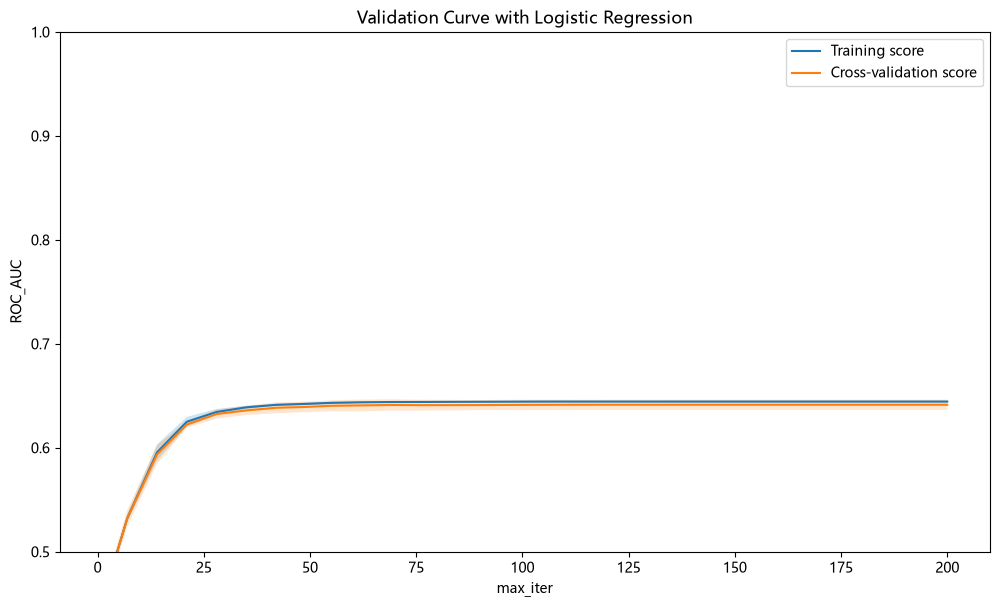

Best cross-validation result (0.64) obtained for 138 max_iter


In [188]:
# ============================================================
# 94. Logistic Regression Validation Curve
# ============================================================

# 每个参数的训练集平均AUC
train_scores_mean = np.mean(
    train_scores,
    axis=1
)

# 每个参数的训练集AUC标准差
train_scores_std = np.std(
    train_scores,
    axis=1
)

# 每个参数的验证集平均AUC
test_scores_mean = np.mean(
    test_scores,
    axis=1
)

# 每个参数的验证集AUC标准差
test_scores_std = np.std(
    test_scores,
    axis=1
)


# ------------------------------------------------------------
# 绘图
# ------------------------------------------------------------

plt.figure(
    figsize=(12, 6.75)
)

plt.title(
    "Validation Curve with Logistic Regression"
)

plt.xlabel(
    "max_iter"
)

plt.ylabel(
    "ROC_AUC"
)

plt.ylim(
    0.5,
    1.0
)


# 训练集
plt.plot(
    max_iter_range,
    train_scores_mean,
    label="Training score"
)

plt.fill_between(
    max_iter_range,
    train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std,
    alpha=0.2
)


# 验证集
plt.plot(
    max_iter_range,
    test_scores_mean,
    label="Cross-validation score"
)

plt.fill_between(
    max_iter_range,
    test_scores_mean - test_scores_std,
    test_scores_mean + test_scores_std,
    alpha=0.2
)


plt.legend(
    loc="best"
)

plt.show()


# ------------------------------------------------------------
# 最优参数
# ------------------------------------------------------------

i = np.argmax(
    test_scores_mean
)

print(
    "Best cross-validation result "
    "({0:.2f}) obtained for {1} max_iter"
    .format(
        test_scores_mean[i],
        max_iter_range[i]
    )
)

In [189]:
# ============================================================
# 95. 检查 Logistic Regression 系数维度
# ============================================================

lr.coef_.shape

(1, 123)

In [190]:
# ============================================================
# 96. 整理 Logistic Regression 特征系数
# ============================================================

lr_coef = pd.DataFrame({
    "features": train_features.columns,
    "coef": lr.coef_[0]
})

lr_coef.sort_values(
    "coef",
    ascending=True,
    inplace=True
)

display(
    lr_coef.tail(20)
)

,features,coef
55,userTotalAction_1_ratio_diff,0.034234
14,item_save_count,0.046543
51,userSave_ratio,0.054310
44,userBuyRatio,0.056278
45,userBuyDiff,0.056278
35,userTotalAction_2,0.056278
8,click_days,0.058328
12,item_add_count,0.080972
15,cat_click_count,0.099284
64,repeat_seller1,0.106922


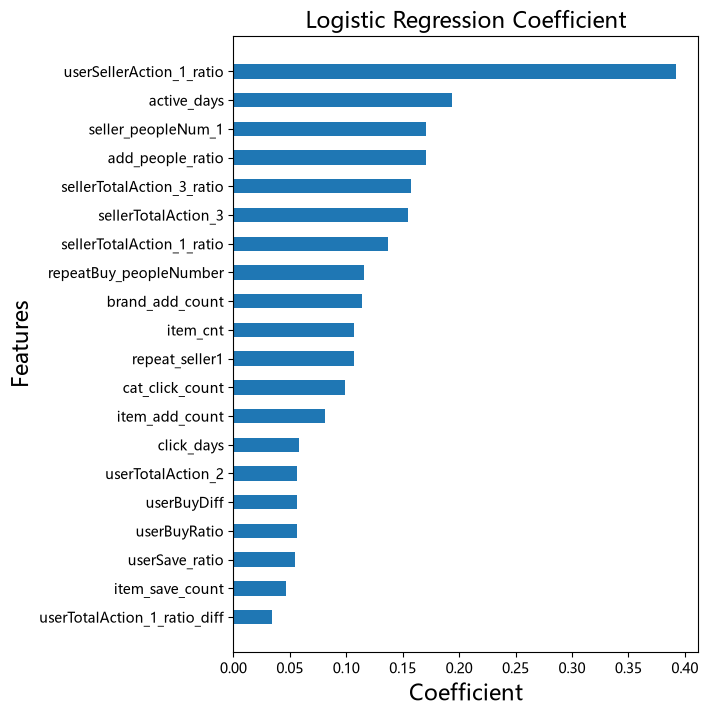

In [191]:
# ============================================================
# 97. Logistic Regression Top 20 Coefficients
# ============================================================

plt.figure(
    figsize=(6, 8)
)

plt.barh(
    y=lr_coef["features"][-20:],
    width=lr_coef["coef"][-20:],
    height=0.5
)

plt.title(
    "Logistic Regression Coefficient",
    fontsize=16
)

plt.xlabel(
    "Coefficient",
    fontsize=16
)

plt.ylabel(
    "Features",
    fontsize=16
)

plt.show()

In [192]:
# ============================================================
# 98. 检查类别顺序
# ============================================================

lr.classes_

array([0, 1])

In [ ]:
# ============================================================
# 99. 使用全部训练数据重新拟合 Logistic Regression
# ============================================================

lr.fit(
    train_features,
    train_data["label"]
)

lr.score(
    train_features,
    train_data["label"]
)

In [194]:
# ============================================================
# 100. 预测测试集复购概率
# ============================================================

prob = lr.predict_proba(
    test_features
)

print(
    "预测结果规模：",
    prob.shape
)

print(
    "前5个复购概率："
)

print(
    prob[:5, 1]
)

预测结果规模： (261477, 2)
前5个复购概率：
[0.08435326 0.09784323 0.05447769 0.04280582 0.08067805]


In [195]:
# ============================================================
# 101. 生成 Logistic Regression 提交文件
# ============================================================

# 防止重复运行时 prob 字段已经存在
if "prob" in alitest.columns:
    alitest.drop(
        columns="prob",
        inplace=True
    )

# 插入复购概率
alitest.insert(
    2,
    "prob",
    prob[:, 1]
)

display(
    alitest.head()
)

print(
    "提交文件规模：",
    alitest.shape
)

alitest.to_csv(
    "data/submission_1231_logireg.csv",
    index=False
)

print(
    "✅ Logistic Regression 提交文件已保存"
)

,user_id,merchant_id,prob
0,163968,4605,0.084353
1,360576,1581,0.097843
2,98688,1964,0.054478
3,98688,3645,0.042806
4,295296,3361,0.080678


提交文件规模： (261477, 3)
✅ Logistic Regression 提交文件已保存


In [196]:
# ============================================================
# 102. Linear SVM
# ============================================================

from sklearn.svm import LinearSVC

svm = LinearSVC(
    penalty="l2",
    loss="squared_hinge",
    dual=True,
    tol=0.0001,
    C=1.0,
    multi_class="ovr",
    fit_intercept=True,
    intercept_scaling=1,
    class_weight=None,
    verbose=1,
    random_state=100,
    max_iter=1000
)

In [ ]:
# ============================================================
# 103. 训练 Linear SVM
# ============================================================

start = time.time()

svm.fit(
    X_train,
    y_train
)

print(
    svm.score(
        X_test,
        y_test
    )
)

end = time.time()

print(
    "The program took %s seconds."
    % (end - start)
)

In [198]:
# ============================================================
# 104. 构造概率校准模型
# ============================================================

from sklearn.calibration import CalibratedClassifierCV

svmCalib = CalibratedClassifierCV(
    svm,
    cv=3
)

In [ ]:
# ============================================================
# 105. 训练校准后的 Linear SVM
# ============================================================

start = time.time()

svmCalib.fit(
    train_features,
    train_data["label"]
)

print(
    svmCalib.score(
        X_test,
        y_test
    )
)

end = time.time()

print(
    "The program took %s seconds."
    % (end - start)
)

In [201]:
# ============================================================
# 106. 检查类别并预测测试集
# ============================================================

print(
    "类别顺序：",
    svmCalib.classes_
)

prob = svmCalib.predict_proba(
    test_features
)

print(
    "预测结果规模：",
    prob.shape
)

print(
    "前5个复购概率："
)

print(
    prob[:5, 1]
)

类别顺序： [0 1]
预测结果规模： (261477, 2)
前5个复购概率：
[0.08207388 0.09255759 0.05265782 0.04448964 0.06976554]


In [202]:
# ============================================================
# 107. 生成 Linear SVM 提交文件
# ============================================================

if "prob" in alitest.columns:
    alitest.drop(
        columns="prob",
        inplace=True
    )

alitest.insert(
    2,
    "prob",
    prob[:, 1]
)

display(
    alitest.head()
)

print(
    "提交文件规模：",
    alitest.shape
)

alitest.to_csv(
    "data/submission_1229_LinearSVC.csv",
    index=False
)

print(
    "✅ Linear SVM 提交文件已保存"
)

,user_id,merchant_id,prob
0,163968,4605,0.082074
1,360576,1581,0.092558
2,98688,1964,0.052658
3,98688,3645,0.044490
4,295296,3361,0.069766


提交文件规模： (261477, 3)
✅ Linear SVM 提交文件已保存


In [203]:
# ============================================================
# 108. 导入 MLP 模型
# ============================================================

from sklearn.neural_network import MLPClassifier

In [204]:
# ============================================================
# 109. 定义 MLP - Adam
# ============================================================

mlp_adam = MLPClassifier(
    hidden_layer_sizes=(700,),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    batch_size=300,
    learning_rate="constant",
    learning_rate_init=0.001,
    power_t=0.5,
    max_iter=200,
    shuffle=True,
    random_state=None,
    tol=0.0001,
    verbose=True,
    warm_start=False,
    early_stopping=False,
    validation_fraction=0.1,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-08
)

In [205]:
learning_rate="adaptive"
momentum=0.9
nesterovs_momentum=True

# ============================================================
# 110. 定义 MLP - SGD
# ============================================================

mlp_sgd = MLPClassifier(
    hidden_layer_sizes=(700,),
    activation="relu",
    solver="sgd",
    alpha=0.0001,
    batch_size=300,
    learning_rate="adaptive",
    learning_rate_init=0.001,
    power_t=0.5,
    max_iter=200,
    shuffle=True,
    random_state=None,
    tol=0.0001,
    verbose=True,
    warm_start=False,
    momentum=0.9,
    nesterovs_momentum=True
)

In [ ]:
# ============================================================
# 111. 训练 MLP - Adam
# ============================================================

start = time.time()

mlp_adam.fit(
    train_features,
    train_data["label"]
)

end = time.time()

print(
    "The program took %s seconds."
    % (end - start)
)

In [207]:
# ============================================================
# 112. 查看 MLP - Adam score
# ============================================================

mlp_adam.score(
    X_test,
    y_test
)

0.9614687637943452

In [208]:
# ============================================================
# 113. 生成 MLP - Adam 提交文件
# ============================================================

prob = mlp_adam.predict_proba(
    test_features
)

if "prob" in alitest.columns:
    alitest.drop(
        columns="prob",
        inplace=True
    )

alitest.insert(
    2,
    "prob",
    prob[:, 1]
)

alitest.to_csv(
    "data/submission_1229_mlp_adam_700nodes.csv",
    index=False
)

display(
    alitest.head()
)

print(
    "提交文件规模：",
    alitest.shape
)

print(
    "✅ MLP - Adam 提交文件已保存"
)

,user_id,merchant_id,prob
0,163968,4605,0.152731
1,360576,1581,0.000016
2,98688,1964,0.094877
3,98688,3645,0.002518
4,295296,3361,0.071038


提交文件规模： (261477, 3)
✅ MLP - Adam 提交文件已保存


In [ ]:
# ============================================================
# 114. 训练 MLP - SGD
# ============================================================

start = time.time()

mlp_sgd.fit(
    train_features,
    train_data["label"]
)

print(
    mlp_sgd.score(
        train_features,
        train_data["label"]
    )
)

end = time.time()

print(
    "The program took %s seconds."
    % (end - start)
)

In [210]:
# ============================================================
# 115. 生成 MLP - SGD 提交文件
# ============================================================

prob = mlp_sgd.predict_proba(
    test_features
)

if "prob" in alitest.columns:
    alitest.drop(
        columns="prob",
        inplace=True
    )

alitest.insert(
    2,
    "prob",
    prob[:, 1]
)

alitest.to_csv(
    "data/submission_1229_mlp_sgd_700nodes.csv",
    index=False
)

display(
    alitest.head()
)

print(
    "提交文件规模：",
    alitest.shape
)

print(
    "✅ MLP - SGD 提交文件已保存"
)

,user_id,merchant_id,prob
0,163968,4605,0.098768
1,360576,1581,0.054467
2,98688,1964,0.043555
3,98688,3645,0.033269
4,295296,3361,0.078259


提交文件规模： (261477, 3)
✅ MLP - SGD 提交文件已保存


In [211]:
# ============================================================
# 116. 定义 Random Forest
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_depth=8,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features="sqrt",
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    bootstrap=True,
    oob_score=False,
    n_jobs=7,
    random_state=None,
    verbose=2,
    class_weight=None
)

In [212]:
# ============================================================
# 117. 训练 Random Forest
# ============================================================

start = time.time()

rf.fit(
    train_features,
    train_data["label"]
)

print(
    rf.score(
        train_features,
        train_data["label"]
    )
)

end = time.time()

print(
    "The program took %s seconds."
    % (end - start)
)

[Parallel(n_jobs=7)]: Using backend ThreadingBackend with 7 concurrent workers.


building tree 4 of 100
building tree 1 of 100
building tree 7 of 100
building tree 5 of 100
building tree 6 of 100
building tree 3 of 100
building tree 2 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100


[Parallel(n_jobs=7)]: Done  27 tasks      | elapsed:    4.7s


building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100building tree 49 of 100

building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77

[Parallel(n_jobs=7)]: Done 100 out of 100 | elapsed:   16.7s finished
[Parallel(n_jobs=7)]: Using backend ThreadingBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done  27 tasks      | elapsed:    0.0s


0.9388800294406281
The program took 17.807639122009277 seconds.


[Parallel(n_jobs=7)]: Done 100 out of 100 | elapsed:    0.3s finished


In [213]:
# ============================================================
# 118. 生成 Random Forest 提交文件
# ============================================================

prob = rf.predict_proba(
    test_features
)

if "prob" in alitest.columns:
    alitest.drop(
        columns="prob",
        inplace=True
    )

alitest.insert(
    2,
    "prob",
    prob[:, 1]
)

alitest.to_csv(
    "data/submission_1229_randomforest_maxdepth8_100trees.csv",
    index=False
)

display(
    alitest.head()
)

print(
    "提交文件规模：",
    alitest.shape
)

print(
    "✅ Random Forest 提交文件已保存"
)

[Parallel(n_jobs=7)]: Using backend ThreadingBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done  27 tasks      | elapsed:    0.0s
[Parallel(n_jobs=7)]: Done 100 out of 100 | elapsed:    0.3s finished


,user_id,merchant_id,prob
0,163968,4605,0.067720
1,360576,1581,0.095469
2,98688,1964,0.049891
3,98688,3645,0.044051
4,295296,3361,0.086890


提交文件规模： (261477, 3)
✅ Random Forest 提交文件已保存


In [214]:
# ============================================================
# 119. 保存 Random Forest 训练集预测概率
# ============================================================

train_preds = rf.predict_proba(
    train_features
)

np.save(
    "data/trainpreds_1231_randomforest_maxdepth8_100trees.npy",
    train_preds[:, 1]
)

print(
    "训练集预测概率规模：",
    train_preds[:, 1].shape
)

print(
    "✅ Random Forest 训练集预测概率已保存"
)

[Parallel(n_jobs=7)]: Using backend ThreadingBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done  27 tasks      | elapsed:    0.0s


训练集预测概率规模： (260864,)
✅ Random Forest 训练集预测概率已保存


[Parallel(n_jobs=7)]: Done 100 out of 100 | elapsed:    0.3s finished


In [215]:
# ============================================================
# 120. Random Forest - n_estimators 交叉验证
# ============================================================

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=123
)

n_estimators_range = (
    np.linspace(
        1,
        200,
        10
    )
    .astype(int)
)

print(
    "n_estimators 候选值："
)

print(
    n_estimators_range
)


train_scores, test_scores = validation_curve(
    RandomForestClassifier(
        criterion="gini",
        max_depth=8,
        min_samples_split=2,
        min_samples_leaf=1,
        min_weight_fraction_leaf=0.0,
        max_features="sqrt",
        max_leaf_nodes=None,
        min_impurity_decrease=0.0,
        bootstrap=True,
        oob_score=False,
        n_jobs=7,
        random_state=None,
        verbose=2,
        class_weight=None
    ),

    train_features,
    train_data["label"],

    param_name="n_estimators",
    param_range=n_estimators_range,

    cv=cv,
    scoring="roc_auc",

    n_jobs=7,
    verbose=2
)

n_estimators 候选值：
[  1  23  45  67  89 111 133 155 177 200]


[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done  50 out of 100 | elapsed:  8.6min remaining:  8.6min
[Parallel(n_jobs=7)]: Done 100 out of 100 | elapsed: 17.0min finished


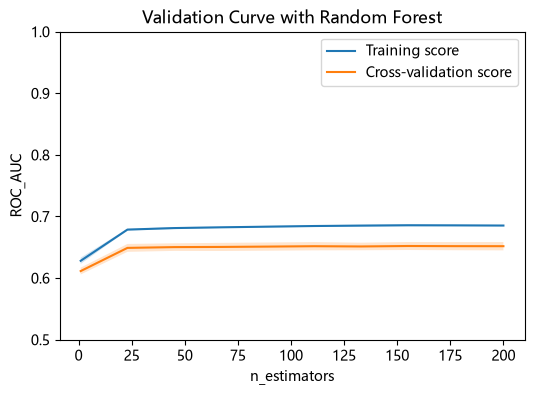

Best cross-validation result (0.65) obtained for 155 trees


In [216]:
# ============================================================
# 121. Random Forest - n_estimators Validation Curve
# ============================================================

train_scores_mean = np.mean(
    train_scores,
    axis=1
)

train_scores_std = np.std(
    train_scores,
    axis=1
)

test_scores_mean = np.mean(
    test_scores,
    axis=1
)

test_scores_std = np.std(
    test_scores,
    axis=1
)


plt.figure(
    figsize=(6, 4)
)

plt.title(
    "Validation Curve with Random Forest"
)

plt.xlabel(
    "n_estimators"
)

plt.ylabel(
    "ROC_AUC"
)

plt.ylim(
    0.5,
    1.0
)


plt.plot(
    n_estimators_range,
    train_scores_mean,
    label="Training score"
)

plt.plot(
    n_estimators_range,
    test_scores_mean,
    label="Cross-validation score"
)

plt.fill_between(
    n_estimators_range,
    train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std,
    alpha=0.2
)

plt.fill_between(
    n_estimators_range,
    test_scores_mean - test_scores_std,
    test_scores_mean + test_scores_std,
    alpha=0.2
)

plt.legend(
    loc="best"
)

plt.show()


i = np.argmax(
    test_scores_mean
)

print(
    "Best cross-validation result "
    "({0:.2f}) obtained for {1} trees"
    .format(
        test_scores_mean[i],
        n_estimators_range[i]
    )
)

In [217]:
# ============================================================
# 122. 保存 n_estimators 交叉验证结果
# ============================================================

np.savez(
    "model/randomforest_cross_validation_results_gini_sqrt_8maxdepth_0130.npz",

    train_scores=train_scores,
    test_scores=test_scores
)

print(
    "✅ Random Forest n_estimators "
    "交叉验证结果已保存"
)

✅ Random Forest n_estimators 交叉验证结果已保存


In [26]:
# ============================================================
# 123. Random Forest - max_depth 交叉验证
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, validation_curve

# 10折分层交叉验证
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=123
)

# max_depth 搜索范围保持不变
max_depth_range = (
    np.linspace(
        11,
        15,
        5
    )
    .astype(int)
)

print(
    "固定 n_estimators：155"
)

print(
    "max_depth 候选值："
)

print(
    max_depth_range
)


# ------------------------------------------------------------
# 使用上一轮实际得到的最优值：
# n_estimators = 155
# ------------------------------------------------------------

train_scores, test_scores = validation_curve(
    RandomForestClassifier(
        n_estimators=155,
        criterion="gini",
        min_samples_split=2,
        min_samples_leaf=1,
        min_weight_fraction_leaf=0.0,
        max_features="sqrt",
        max_leaf_nodes=None,
        min_impurity_decrease=0.0,
        bootstrap=True,
        oob_score=False,
        n_jobs=7,
        random_state=None,
        verbose=2,
        class_weight=None
    ),

    train_features,
    train_data["label"],

    param_name="max_depth",
    param_range=max_depth_range,

    cv=cv,
    scoring="roc_auc",

    n_jobs=7,
    verbose=2
)

固定 n_estimators：155
max_depth 候选值：
[11 12 13 14 15]


[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done  25 out of  50 | elapsed: 10.5min remaining: 10.5min
[Parallel(n_jobs=7)]: Done  50 out of  50 | elapsed: 19.0min finished


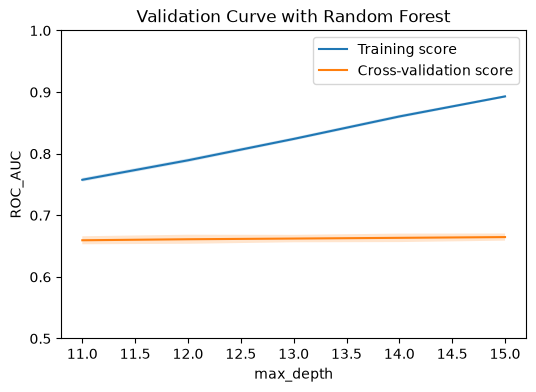

Best cross-validation result (0.6646) obtained for 15 max_depth

记录新的最优 max_depth： 15


In [27]:
# ============================================================
# 124. Random Forest - max_depth Validation Curve
# ============================================================

train_scores_mean = np.mean(
    train_scores,
    axis=1
)

train_scores_std = np.std(
    train_scores,
    axis=1
)

test_scores_mean = np.mean(
    test_scores,
    axis=1
)

test_scores_std = np.std(
    test_scores,
    axis=1
)


plt.figure(
    figsize=(6, 4)
)

plt.title(
    "Validation Curve with Random Forest"
)

plt.xlabel(
    "max_depth"
)

plt.ylabel(
    "ROC_AUC"
)

plt.ylim(
    0.5,
    1.0
)


plt.plot(
    max_depth_range,
    train_scores_mean,
    label="Training score"
)

plt.plot(
    max_depth_range,
    test_scores_mean,
    label="Cross-validation score"
)

plt.fill_between(
    max_depth_range,
    train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std,
    alpha=0.2
)

plt.fill_between(
    max_depth_range,
    test_scores_mean - test_scores_std,
    test_scores_mean + test_scores_std,
    alpha=0.2
)

plt.legend(
    loc="best"
)

plt.show()


i = np.argmax(
    test_scores_mean
)

best_rf_max_depth = int(
    max_depth_range[i]
)

print(
    "Best cross-validation result "
    "({0:.4f}) obtained for {1} max_depth"
    .format(
        test_scores_mean[i],
        best_rf_max_depth
    )
)

print(
    "\n记录新的最优 max_depth：",
    best_rf_max_depth
)

In [28]:
# ============================================================
# 125. Random Forest - max_features 交叉验证
# ============================================================

# 记录前两轮实际得到的最优参数
best_rf_n_estimators = 155
best_rf_max_depth = 15


cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=123
)


# max_features 搜索范围
max_features_range = (
    np.linspace(
        16,
        20,
        5
    )
    .astype(int)
)


print(
    "固定 n_estimators：",
    best_rf_n_estimators
)

print(
    "固定 max_depth：",
    best_rf_max_depth
)

print(
    "max_features 候选值："
)

print(
    max_features_range
)


train_scores, test_scores = validation_curve(
    RandomForestClassifier(
        n_estimators=best_rf_n_estimators,
        criterion="gini",
        max_depth=best_rf_max_depth,
        min_samples_split=2,
        min_samples_leaf=1,
        min_weight_fraction_leaf=0.0,
        max_leaf_nodes=None,
        min_impurity_decrease=0.0,
        bootstrap=True,
        oob_score=False,
        n_jobs=7,
        random_state=None,
        verbose=2,
        class_weight=None
    ),

    train_features,
    train_data["label"],

    param_name="max_features",
    param_range=max_features_range,

    cv=cv,
    scoring="roc_auc",

    n_jobs=7,
    verbose=2
)

固定 n_estimators： 155
固定 max_depth： 15
max_features 候选值：
[16 17 18 19 20]


[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done  25 out of  50 | elapsed: 17.2min remaining: 17.2min
[Parallel(n_jobs=7)]: Done  50 out of  50 | elapsed: 30.9min finished


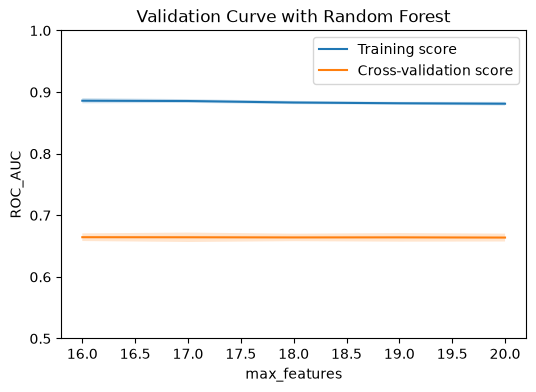

Best cross-validation result (0.6644) obtained for 16 max_features

记录新的最优 max_features： 16


In [29]:
# ============================================================
# 126. Random Forest - max_features Validation Curve
# ============================================================

train_scores_mean = np.mean(
    train_scores,
    axis=1
)

train_scores_std = np.std(
    train_scores,
    axis=1
)

test_scores_mean = np.mean(
    test_scores,
    axis=1
)

test_scores_std = np.std(
    test_scores,
    axis=1
)


plt.figure(
    figsize=(6, 4)
)

plt.title(
    "Validation Curve with Random Forest"
)

plt.xlabel(
    "max_features"
)

plt.ylabel(
    "ROC_AUC"
)

plt.ylim(
    0.5,
    1.0
)


plt.plot(
    max_features_range,
    train_scores_mean,
    label="Training score"
)

plt.plot(
    max_features_range,
    test_scores_mean,
    label="Cross-validation score"
)

plt.fill_between(
    max_features_range,
    train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std,
    alpha=0.2
)

plt.fill_between(
    max_features_range,
    test_scores_mean - test_scores_std,
    test_scores_mean + test_scores_std,
    alpha=0.2
)

plt.legend(
    loc="best"
)

plt.show()


i = np.argmax(
    test_scores_mean
)

best_rf_max_features = int(
    max_features_range[i]
)


print(
    "Best cross-validation result "
    "({0:.4f}) obtained for {1} max_features"
    .format(
        test_scores_mean[i],
        best_rf_max_features
    )
)

print(
    "\n记录新的最优 max_features：",
    best_rf_max_features
)

In [30]:
# ============================================================
# 127. 保存 max_features 交叉验证结果
# ============================================================

np.savez(
    "model/randomforest_cv_n155_depth15_maxfeatures16-20.npz",

    train_scores=train_scores,
    test_scores=test_scores
)

print(
    "✅ Random Forest max_features 交叉验证结果已保存"
)

✅ Random Forest max_features 交叉验证结果已保存


In [31]:
# ============================================================
# 128. Random Forest - criterion 交叉验证
# ============================================================

best_rf_n_estimators = 155
best_rf_max_depth = 15
best_rf_max_features = 16


cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=123
)


criterion_range = [
    "gini",
    "entropy"
]


print(
    "固定 n_estimators：",
    best_rf_n_estimators
)

print(
    "固定 max_depth：",
    best_rf_max_depth
)

print(
    "固定 max_features：",
    best_rf_max_features
)

print(
    "criterion 候选值："
)

print(
    criterion_range
)


train_scores, test_scores = validation_curve(
    RandomForestClassifier(
        n_estimators=best_rf_n_estimators,
        max_depth=best_rf_max_depth,
        max_features=best_rf_max_features,
        min_samples_split=2,
        min_samples_leaf=1,
        min_weight_fraction_leaf=0.0,
        max_leaf_nodes=None,
        min_impurity_decrease=0.0,
        bootstrap=True,
        oob_score=False,
        n_jobs=7,
        random_state=None,
        verbose=2,
        class_weight=None
    ),

    train_features,
    train_data["label"],

    param_name="criterion",
    param_range=criterion_range,

    cv=cv,
    scoring="roc_auc",

    n_jobs=7,
    verbose=2
)

固定 n_estimators： 155
固定 max_depth： 15
固定 max_features： 16
criterion 候选值：
['gini', 'entropy']


[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done  10 out of  20 | elapsed:  7.6min remaining:  7.6min
[Parallel(n_jobs=7)]: Done  20 out of  20 | elapsed: 10.8min finished


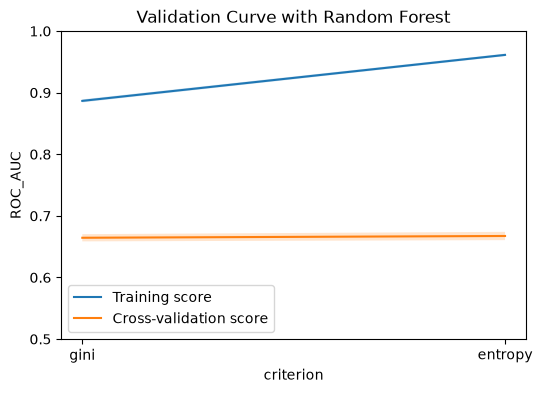

Best cross-validation result (0.6673) obtained for entropy criterion

各 criterion 平均验证 AUC：
[0.66442597 0.667307  ]

记录新的最优 criterion： entropy


In [33]:
# ============================================================
# 129. Random Forest - criterion Validation Curve
# ============================================================

train_scores_mean = np.mean(
    train_scores,
    axis=1
)

train_scores_std = np.std(
    train_scores,
    axis=1
)

test_scores_mean = np.mean(
    test_scores,
    axis=1
)

test_scores_std = np.std(
    test_scores,
    axis=1
)


plt.figure(
    figsize=(6, 4)
)

plt.title(
    "Validation Curve with Random Forest"
)

plt.xlabel(
    "criterion"
)

plt.ylabel(
    "ROC_AUC"
)

plt.ylim(
    0.5,
    1.0
)


plt.plot(
    criterion_range,
    train_scores_mean,
    label="Training score"
)

plt.plot(
    criterion_range,
    test_scores_mean,
    label="Cross-validation score"
)

plt.fill_between(
    criterion_range,
    train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std,
    alpha=0.2
)

plt.fill_between(
    criterion_range,
    test_scores_mean - test_scores_std,
    test_scores_mean + test_scores_std,
    alpha=0.2
)

plt.legend(
    loc="best"
)

plt.show()


i = np.argmax(
    test_scores_mean
)

best_rf_criterion = criterion_range[i]


print(
    "Best cross-validation result "
    "({0:.4f}) obtained for {1} criterion"
    .format(
        test_scores_mean[i],
        best_rf_criterion
    )
)

print(
    "\n各 criterion 平均验证 AUC："
)

print(
    test_scores_mean
)

print(
    "\n记录新的最优 criterion：",
    best_rf_criterion
)

In [34]:
# ============================================================
# 130. 保存 criterion 交叉验证结果
# ============================================================

np.savez(
    "model/randomforest_cv_n155_depth15_maxfeatures16_criterion.npz",
    train_scores=train_scores,
    test_scores=test_scores
)

print(
    "✅ Random Forest criterion 交叉验证结果已保存"
)

✅ Random Forest criterion 交叉验证结果已保存


In [35]:
# ============================================================
# 131. 定义最终 Random Forest
# ============================================================

from sklearn.ensemble import RandomForestClassifier

best_rf_n_estimators = 155
best_rf_max_depth = 15
best_rf_max_features = 16
best_rf_criterion = "entropy"


rf = RandomForestClassifier(
    n_estimators=best_rf_n_estimators,
    criterion=best_rf_criterion,
    max_depth=best_rf_max_depth,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features=best_rf_max_features,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    bootstrap=True,
    oob_score=False,
    n_jobs=7,
    random_state=None,
    verbose=2,
    class_weight=None
)


print(
    "最终 Random Forest 参数："
)

print(
    "n_estimators =",
    best_rf_n_estimators
)

print(
    "max_depth =",
    best_rf_max_depth
)

print(
    "max_features =",
    best_rf_max_features
)

print(
    "criterion =",
    best_rf_criterion
)

最终 Random Forest 参数：
n_estimators = 155
max_depth = 15
max_features = 16
criterion = entropy


In [36]:
# ============================================================
# 132. 训练最终 Random Forest
# ============================================================

from sklearn.metrics import roc_auc_score

start = time.time()

rf.fit(
    train_features,
    train_data["label"]
)

preds = rf.predict(
    train_features
)

print(
    roc_auc_score(
        preds,
        train_data["label"]
    )
)

end = time.time()

print(
    "The program took %s seconds."
    % (end - start)
)

[Parallel(n_jobs=7)]: Using backend ThreadingBackend with 7 concurrent workers.


building tree 7 of 155
building tree 3 of 155
building tree 4 of 155
building tree 5 of 155
building tree 1 of 155
building tree 6 of 155
building tree 2 of 155
building tree 8 of 155
building tree 9 of 155
building tree 10 of 155
building tree 11 of 155
building tree 12 of 155
building tree 13 of 155
building tree 14 of 155
building tree 15 of 155
building tree 16 of 155
building tree 17 of 155
building tree 18 of 155
building tree 19 of 155
building tree 20 of 155
building tree 21 of 155
building tree 22 of 155
building tree 23 of 155
building tree 24 of 155
building tree 25 of 155
building tree 26 of 155
building tree 27 of 155
building tree 28 of 155
building tree 29 of 155
building tree 30 of 155
building tree 31 of 155
building tree 32 of 155
building tree 33 of 155
building tree 34 of 155
building tree 35 of 155


[Parallel(n_jobs=7)]: Done  27 tasks      | elapsed:    7.7s


building tree 36 of 155
building tree 37 of 155
building tree 38 of 155
building tree 39 of 155
building tree 40 of 155
building tree 41 of 155
building tree 42 of 155
building tree 43 of 155
building tree 44 of 155
building tree 45 of 155
building tree 46 of 155
building tree 47 of 155
building tree 48 of 155
building tree 49 of 155
building tree 50 of 155
building tree 51 of 155
building tree 52 of 155
building tree 53 of 155
building tree 54 of 155
building tree 55 of 155
building tree 56 of 155
building tree 57 of 155
building tree 58 of 155
building tree 59 of 155
building tree 60 of 155
building tree 61 of 155
building tree 62 of 155
building tree 63 of 155
building tree 64 of 155
building tree 65 of 155
building tree 66 of 155
building tree 67 of 155
building tree 68 of 155
building tree 69 of 155
building tree 70 of 155
building tree 71 of 155
building tree 72 of 155
building tree 73 of 155building tree 74 of 155

building tree 75 of 155
building tree 76 of 155
building tree 77

[Parallel(n_jobs=7)]: Done 155 out of 155 | elapsed:   43.9s finished
[Parallel(n_jobs=7)]: Using backend ThreadingBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done  27 tasks      | elapsed:    0.1s


0.970756479552217
The program took 45.33284139633179 seconds.


[Parallel(n_jobs=7)]: Done 155 out of 155 | elapsed:    0.8s finished


In [37]:
# ============================================================
# 133. 生成修正后的最终 Random Forest 提交文件
# ============================================================

prob = rf.predict_proba(
    test_features
)

if "prob" in alitest.columns:
    alitest.drop(
        columns="prob",
        inplace=True
    )

alitest.insert(
    2,
    "prob",
    prob[:, 1]
)

alitest.to_csv(
    "data/submission_rf_n155_depth15_features16_entropy.csv",
    index=False
)

display(
    alitest.head()
)

print(
    "提交文件规模：",
    alitest.shape
)

print(
    "✅ 修正后的最终 Random Forest 提交文件已保存"
)

[Parallel(n_jobs=7)]: Using backend ThreadingBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done  27 tasks      | elapsed:    0.1s
[Parallel(n_jobs=7)]: Done 155 out of 155 | elapsed:    0.9s finished


,user_id,merchant_id,prob
0,163968,4605,0.071181
1,360576,1581,0.096030
2,98688,1964,0.044145
3,98688,3645,0.042915
4,295296,3361,0.109897


提交文件规模： (261477, 3)
✅ 修正后的最终 Random Forest 提交文件已保存


In [ ]:
# ============================================================
# 134. 保存修正后的最终 Random Forest 训练集预测概率
# ============================================================

train_preds = rf.predict_proba(
    train_features
)

np.save(
    "data/trainpreds_rf_n155_depth15_features16_entropy.npy",
    train_preds[:, 1]
)

print(
    "训练集预测概率规模：",
    train_preds[:, 1].shape
)

print(
    "✅ 修正后的 Random Forest 训练集预测概率已保存"
)

[Parallel(n_jobs=7)]: Using backend ThreadingBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done  27 tasks      | elapsed:    0.1s


训练集预测概率规模： (260864,)
✅ 修正后的 Random Forest 训练集预测概率已保存


[Parallel(n_jobs=7)]: Done 155 out of 155 | elapsed:    1.1s finished


: 

In [233]:
# ============================================================
# 135. 检查 scikit-learn 版本
# ============================================================

import sklearn

print(
    "scikit-learn 版本：",
    sklearn.__version__
)

scikit-learn 版本： 1.9.1


In [ ]:
# ============================================================
# 136. 安装指定版本的 scikit-learn
# ============================================================

%pip install scikit-learn==1.5.2

In [1]:
# ============================================================
# 137. 检查 scikit-learn 版本
# ============================================================

import sklearn

print(
    "scikit-learn 版本：",
    sklearn.__version__
)

scikit-learn 版本： 1.5.2


In [3]:
# ============================================================
# 138. 恢复模型训练数据
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import time

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    validation_curve
)

feature_dir = Path("feature")
data_dir = Path("data/data_format1")


# ------------------------------------------------------------
# 读取最终特征表
# ------------------------------------------------------------

seller = pd.read_csv(
    feature_dir / "seller_info_format_feature_3.csv"
)

user = pd.read_csv(
    feature_dir / "user_info_format_feature_3.csv"
)

user_seller = pd.read_csv(
    feature_dir / "user_seller_info_format_feature_3.csv"
)


# ------------------------------------------------------------
# 读取训练集和测试集
# ------------------------------------------------------------

labels = pd.read_csv(
    data_dir / "train_format1.csv"
)

alitest = pd.read_csv(
    data_dir / "test_format1.csv"
)


# ------------------------------------------------------------
# gender 类型
# ------------------------------------------------------------

user["gender"] = (
    user["gender"]
    .astype("int8")
)


# ------------------------------------------------------------
# 合并三类特征
# ------------------------------------------------------------

all_data = pd.merge(
    user_seller,
    user,
    on="user_id"
)

all_data = pd.merge(
    all_data,
    seller,
    on="seller_id"
)


# ------------------------------------------------------------
# 构造训练数据
# ------------------------------------------------------------

train_data = pd.merge(
    all_data,
    labels,
    left_on=[
        "user_id",
        "seller_id"
    ],
    right_on=[
        "user_id",
        "merchant_id"
    ]
)

train_data.drop(
    columns="merchant_id",
    inplace=True
)


# ------------------------------------------------------------
# 构造测试数据
# ------------------------------------------------------------

if "prob" in alitest.columns:
    alitest.drop(
        columns="prob",
        inplace=True
    )

test_data = pd.merge(
    alitest,
    all_data,
    left_on=[
        "user_id",
        "merchant_id"
    ],
    right_on=[
        "user_id",
        "seller_id"
    ]
)

test_data.drop(
    columns="merchant_id",
    inplace=True
)


# ------------------------------------------------------------
# 模型特征
# ------------------------------------------------------------

train_features = train_data.drop(
    columns=[
        "user_id",
        "seller_id",
        "label"
    ]
)

test_features = test_data.drop(
    columns=[
        "user_id",
        "seller_id"
    ]
)


# ------------------------------------------------------------
# 恢复 67% / 33% 划分
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    train_features,
    train_data["label"],
    test_size=0.33,
    random_state=42
)


print(
    "train_features：",
    train_features.shape
)

print(
    "test_features ：",
    test_features.shape
)

print(
    "X_train：",
    X_train.shape
)

print(
    "X_test ：",
    X_test.shape
)

train_features： (260864, 123)
test_features ： (261477, 123)
X_train： (174778, 123)
X_test ： (86086, 123)


In [3]:
# ============================================================
# 139. 定义 AdaBoost 基学习器
# ============================================================

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

base = DecisionTreeClassifier(
    criterion="entropy",
    splitter="best",
    max_depth=14,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features=17,
    random_state=None,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    class_weight=None
)

In [4]:
# ============================================================
# 140. 定义 AdaBoost
# ============================================================

ada = AdaBoostClassifier(
    estimator=base,
    n_estimators=50,
    learning_rate=1.0,
    algorithm="SAMME.R",
    random_state=None
)

In [ ]:
# ============================================================
# 141. 训练 AdaBoost
# ============================================================

start = time.time()

ada.fit(
    train_features,
    train_data["label"]
)

preds = ada.predict(
    train_features
)

print(
    "AUC of validation set: %s"
    % (
        roc_auc_score(
            preds,
            train_data["label"]
        )
    )
)

end = time.time()

print(
    "The program took %s seconds."
    % (end - start)
)

In [6]:
# ============================================================
# 142. 生成 AdaBoost 提交文件
# ============================================================

prob = ada.predict_proba(
    test_features
)

if "prob" in alitest.columns:
    alitest.drop(
        columns="prob",
        inplace=True
    )

alitest.insert(
    2,
    "prob",
    prob[:, 1]
)

alitest.to_csv(
    "data/submission_0131_adaboost_n50_lr1.csv",
    index=False
)

display(
    alitest.head()
)

print(
    "提交文件规模：",
    alitest.shape
)

print(
    "✅ AdaBoost 提交文件已保存"
)

,user_id,merchant_id,prob
0,163968,4605,0.002248
1,360576,1581,0.026061
2,98688,1964,0.035921
3,98688,3645,0.088147
4,295296,3361,0.025683


提交文件规模： (261477, 3)
✅ AdaBoost 提交文件已保存


In [7]:

# ============================================================
# 143. 保存 AdaBoost 训练集预测概率
# ============================================================

train_preds = ada.predict_proba(
    train_features
)

np.save(
    "data/trainpreds_0131_adaboost_n50_lr1.npy",
    train_preds[:, 1]
)

print(
    "训练集预测概率规模：",
    train_preds[:, 1].shape
)

print(
    "✅ AdaBoost 训练集预测概率已保存"
)

训练集预测概率规模： (260864,)
✅ AdaBoost 训练集预测概率已保存


In [8]:
# ============================================================
# 144. AdaBoost - n_estimators 交叉验证
# ============================================================

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=123
)

param_range = (
    np.linspace(
        10,
        100,
        10
    )
    .astype(int)
)

print(
    "n_estimators 候选值："
)

print(
    param_range
)


train_scores, test_scores = validation_curve(
    AdaBoostClassifier(
        estimator=base,
        learning_rate=1.0,
        algorithm="SAMME.R",
        random_state=None
    ),

    train_features,
    train_data["label"],

    param_name="n_estimators",
    param_range=param_range,

    cv=cv,
    scoring="roc_auc",

    n_jobs=7,
    verbose=2
)

n_estimators 候选值：
[ 10  20  30  40  50  60  70  80  90 100]


[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done  50 out of 100 | elapsed: 23.0min remaining: 23.0min
[Parallel(n_jobs=7)]: Done 100 out of 100 | elapsed: 48.1min finished


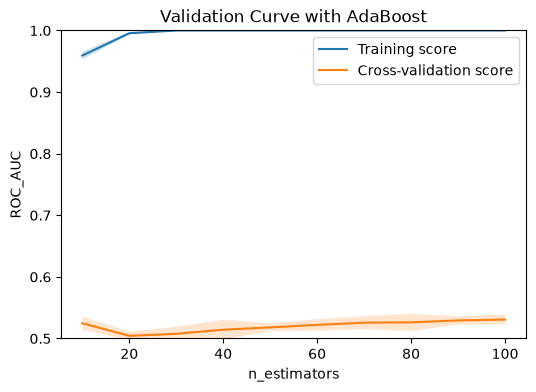

Best cross-validation result (0.53) obtained for 100 trees


In [10]:
# ============================================================
# 导入绘图库
# ============================================================

import matplotlib.pyplot as plt

# ============================================================
# 145. AdaBoost - n_estimators Validation Curve
# ============================================================

train_scores_mean = np.mean(
    train_scores,
    axis=1
)

train_scores_std = np.std(
    train_scores,
    axis=1
)

test_scores_mean = np.mean(
    test_scores,
    axis=1
)

test_scores_std = np.std(
    test_scores,
    axis=1
)


plt.figure(
    figsize=(6, 4)
)

plt.title(
    "Validation Curve with AdaBoost"
)

plt.xlabel(
    "n_estimators"
)

plt.ylabel(
    "ROC_AUC"
)

plt.ylim(
    0.5,
    1.0
)


plt.plot(
    param_range,
    train_scores_mean,
    label="Training score"
)

plt.plot(
    param_range,
    test_scores_mean,
    label="Cross-validation score"
)

plt.fill_between(
    param_range,
    train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std,
    alpha=0.2
)

plt.fill_between(
    param_range,
    test_scores_mean - test_scores_std,
    test_scores_mean + test_scores_std,
    alpha=0.2
)

plt.legend(
    loc="best"
)

plt.show()


i = np.argmax(
    test_scores_mean
)

print(
    "Best cross-validation result "
    "({0:.2f}) obtained for {1} trees"
    .format(
        test_scores_mean[i],
        param_range[i]
    )
)

In [11]:
# ============================================================
# 146. 保存 n_estimators 交叉验证结果
# ============================================================

np.savez(
    "model/adaboost_cross_validation_results_lr1_n10-100_0130.npz",

    train_scores=train_scores,
    test_scores=test_scores
)

print(
    "✅ AdaBoost n_estimators 交叉验证结果已保存"
)

✅ AdaBoost n_estimators 交叉验证结果已保存


In [12]:
# ============================================================
# 147. AdaBoost - learning_rate 交叉验证
# ============================================================

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=123
)

param_range = [
    0.0001,
    0.001,
    0.01,
    0.1,
    0.2,
    0.3,
    0.5,
    0.8,
    1
]

print(
    "learning_rate 候选值："
)

print(
    param_range
)


train_scores, test_scores = validation_curve(
    AdaBoostClassifier(
        estimator=base,
        n_estimators=100,
        algorithm="SAMME.R",
        random_state=None
    ),

    train_features,
    train_data["label"],

    param_name="learning_rate",
    param_range=param_range,

    cv=cv,
    scoring="roc_auc",

    n_jobs=7,
    verbose=2
)

learning_rate 候选值：
[0.0001, 0.001, 0.01, 0.1, 0.2, 0.3, 0.5, 0.8, 1]


[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done  45 out of  90 | elapsed: 42.6min remaining: 42.6min
[Parallel(n_jobs=7)]: Done  90 out of  90 | elapsed: 82.9min finished


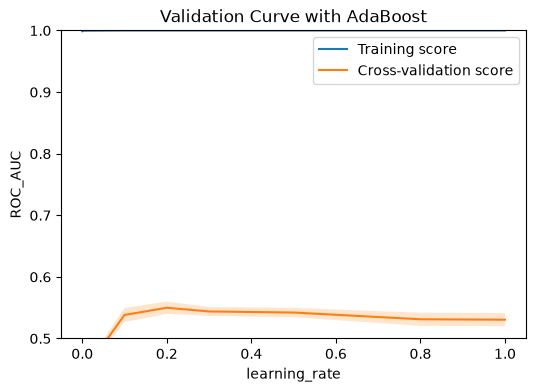

Best cross-validation result (0.55) obtained for 0.2 learning_rate


In [13]:
# ============================================================
# 148. AdaBoost - learning_rate Validation Curve
# ============================================================

train_scores_mean = np.mean(
    train_scores,
    axis=1
)

train_scores_std = np.std(
    train_scores,
    axis=1
)

test_scores_mean = np.mean(
    test_scores,
    axis=1
)

test_scores_std = np.std(
    test_scores,
    axis=1
)


plt.figure(
    figsize=(6, 4)
)

plt.title(
    "Validation Curve with AdaBoost"
)

plt.xlabel(
    "learning_rate"
)

plt.ylabel(
    "ROC_AUC"
)

plt.ylim(
    0.5,
    1.0
)


plt.plot(
    param_range,
    train_scores_mean,
    label="Training score"
)

plt.plot(
    param_range,
    test_scores_mean,
    label="Cross-validation score"
)

plt.fill_between(
    param_range,
    train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std,
    alpha=0.2
)

plt.fill_between(
    param_range,
    test_scores_mean - test_scores_std,
    test_scores_mean + test_scores_std,
    alpha=0.2
)

plt.legend(
    loc="best"
)

plt.show()


i = np.argmax(
    test_scores_mean
)

print(
    "Best cross-validation result "
    "({0:.2f}) obtained for {1} learning_rate"
    .format(
        test_scores_mean[i],
        param_range[i]
    )
)

In [14]:
# ============================================================
# 149. 保存 learning_rate 交叉验证结果
# ============================================================

np.savez(
    "model/adaboost_cross_validation_results_lr0.0001-1_n100_0130.npz",

    train_scores=train_scores,
    test_scores=test_scores
)

print(
    "✅ AdaBoost learning_rate 交叉验证结果已保存"
)

✅ AdaBoost learning_rate 交叉验证结果已保存


In [4]:
# ============================================================
# 150. 导入 XGBoost
# ============================================================

import xgboost as xgb

print(
    "XGBoost 版本：",
    xgb.__version__
)

XGBoost 版本： 3.4.1


In [16]:
# ============================================================
# 151. 创建 XGBoost DMatrix
# ============================================================

dtrain = xgb.DMatrix(
    X_train,
    label=y_train
)

dtest = xgb.DMatrix(
    X_test,
    label=y_test
)

print(
    "dtrain：",
    dtrain.num_row(),
    "×",
    dtrain.num_col()
)

print(
    "dtest：",
    dtest.num_row(),
    "×",
    dtest.num_col()
)

dtrain： 174778 × 123
dtest： 86086 × 123


In [17]:
# ============================================================
# 152. 定义 XGBoost 基础模型
# ============================================================

bst = xgb.XGBClassifier(
    learning_rate=0.1,
    n_estimators=300,
    objective="binary:logistic",
    booster="gbtree",
    tree_method="auto",
    gamma=0.1,
    max_depth=8,
    reg_lambda=2,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=1,
    verbosity=2,
    seed=1000,
    n_jobs=7,
    eval_metric="auc"
)

In [18]:
# ============================================================
# 153. 训练 XGBoost 基础模型
# ============================================================

start = time.time()

bst.fit(
    X_train,
    y_train,
    eval_set=[
        (X_train, y_train),
        (X_test, y_test)
    ],
    verbose=True
)

end = time.time()

print(
    "The program took %s seconds."
    % (end - start)
)

[22:51:24] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (174778, 123, 21497694).
[22:51:24] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (86086, 123, 10588578).
[0]	validation_0-auc:0.65506	validation_1-auc:0.60925
[1]	validation_0-auc:0.68098	validation_1-auc:0.63170
[2]	validation_0-auc:0.69139	validation_1-auc:0.64215
[3]	validation_0-auc:0.69639	validation_1-auc:0.64382
[4]	validation_0-auc:0.70408	validation_1-auc:0.64947
[5]	validation_0-auc:0.70827	validation_1-auc:0.65270
[6]	validation_0-auc:0.71259	validation_1-auc:0.65270
[7]	validation_0-auc:0.71824	validation_1-auc:0.65616
[8]	validation_0-auc:0.72131	validation_1-auc:0.65776
[9]	validation_0-auc:0.72562	validation_1-auc:0.65871
[10]	validation_0-auc:0.72945	validation_1-auc:0.65982
[11]	validation_0-auc:0.73331	validation_1-auc:0.66159
[12]	validation_0-auc:0.737

In [20]:
# ============================================================
# 154. 查看 XGBoost 验证集准确率
# ============================================================
from sklearn.metrics import accuracy_score

preds = bst.predict(
    X_test
)

print(
    accuracy_score(
        y_test,
        preds
    )
)

0.9395023581070092


In [21]:
# ============================================================
# 155. 生成 XGBoost 提交文件
# ============================================================

prob = bst.predict_proba(
    test_features
)

if "prob" in alitest.columns:
    alitest.drop(
        columns="prob",
        inplace=True
    )

alitest.insert(
    2,
    "prob",
    prob[:, 1]
)

alitest.to_csv(
    "data/submission_1230_xgboost_n100_maxdepth8_lr0.1.csv",
    index=False
)

display(
    alitest.head()
)

print(
    "提交文件规模：",
    alitest.shape
)

print(
    "✅ XGBoost 提交文件已保存"
)

,user_id,merchant_id,prob
0,163968,4605,0.128651
1,360576,1581,0.051711
2,98688,1964,0.057279
3,98688,3645,0.039649
4,295296,3361,0.068082


提交文件规模： (261477, 3)
✅ XGBoost 提交文件已保存


In [22]:
# ============================================================
# 156. 保存 XGBoost 训练集预测概率
# ============================================================

train_preds = bst.predict_proba(
    train_features
)

np.save(
    "data/trainpreds_1231_xgboost_n67_maxdepth8_lr0.1.npy",
    train_preds[:, 1]
)

print(
    "训练集预测概率规模：",
    train_preds[:, 1].shape
)

print(
    "✅ XGBoost 训练集预测概率已保存"
)

训练集预测概率规模： (260864,)
✅ XGBoost 训练集预测概率已保存


In [23]:
# ============================================================
# 157. XGBoost - n_estimators 交叉验证
# ============================================================

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=123
)

n_estimators_range = (
    np.linspace(
        1,
        200,
        10
    )
    .astype(int)
)

print(
    "n_estimators 候选值："
)

print(
    n_estimators_range
)


train_scores, test_scores = validation_curve(
    xgb.XGBClassifier(
        learning_rate=0.1,
        objective="binary:logistic",
        booster="gbtree",
        tree_method="auto",
        gamma=0.1,
        max_depth=8,
        reg_lambda=2,
        subsample=0.7,
        colsample_bytree=0.7,
        min_child_weight=1,
        verbosity=2,
        seed=1000,
        n_jobs=7
    ),

    train_features,
    train_data["label"],

    param_name="n_estimators",
    param_range=n_estimators_range,

    cv=cv,
    scoring="roc_auc",

    n_jobs=7,
    verbose=2
)

n_estimators 候选值：
[  1  23  45  67  89 111 133 155 177 200]


[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done  50 out of 100 | elapsed:  2.2min remaining:  2.2min
[Parallel(n_jobs=7)]: Done 100 out of 100 | elapsed:  4.4min finished


In [24]:
# ============================================================
# 158. 保存 n_estimators 交叉验证结果
# ============================================================

np.savez(
    "model/xgboost_cross_validation_results_lr0.1_8maxdepth_1230.npz",

    train_scores=train_scores,
    test_scores=test_scores
)

print(
    "✅ XGBoost n_estimators 交叉验证结果已保存"
)

✅ XGBoost n_estimators 交叉验证结果已保存


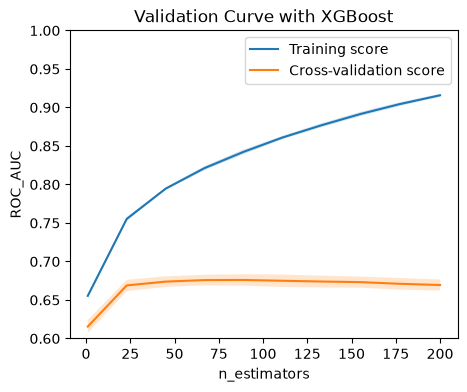

Best cross-validation result (0.68) obtained for 89 trees


In [25]:
# ============================================================
# 159. XGBoost - n_estimators Validation Curve
# ============================================================

train_scores_mean = np.mean(
    train_scores,
    axis=1
)

train_scores_std = np.std(
    train_scores,
    axis=1
)

test_scores_mean = np.mean(
    test_scores,
    axis=1
)

test_scores_std = np.std(
    test_scores,
    axis=1
)


plt.figure(
    figsize=(5, 4)
)

plt.title(
    "Validation Curve with XGBoost"
)

plt.xlabel(
    "n_estimators"
)

plt.ylabel(
    "ROC_AUC"
)

plt.ylim(
    0.6,
    1.0
)


plt.plot(
    n_estimators_range,
    train_scores_mean,
    label="Training score"
)

plt.plot(
    n_estimators_range,
    test_scores_mean,
    label="Cross-validation score"
)

plt.fill_between(
    n_estimators_range,
    train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std,
    alpha=0.2
)

plt.fill_between(
    n_estimators_range,
    test_scores_mean - test_scores_std,
    test_scores_mean + test_scores_std,
    alpha=0.2
)

plt.legend(
    loc="best"
)

plt.show()


i = np.argmax(
    test_scores_mean
)

print(
    "Best cross-validation result "
    "({0:.2f}) obtained for {1} trees"
    .format(
        test_scores_mean[i],
        n_estimators_range[i]
    )
)

In [5]:

# ============================================================
# 160. XGBoost - max_depth 交叉验证
# ============================================================

best_xgb_n_estimators = 89

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=123
)

max_depth_range = (
    np.linspace(
        5,
        10,
        6
    )
    .astype(int)
)

print(
    "固定 n_estimators：",
    best_xgb_n_estimators
)

print(
    "max_depth 候选值："
)

print(
    max_depth_range
)


start = time.time()

train_scores, test_scores = validation_curve(
    xgb.XGBClassifier(
        learning_rate=0.1,
        n_estimators=best_xgb_n_estimators,
        objective="binary:logistic",
        booster="gbtree",
        tree_method="auto",
        gamma=0.1,
        reg_lambda=2,
        subsample=0.7,
        colsample_bytree=0.7,
        min_child_weight=1,
        verbosity=2,
        seed=1000,
        n_jobs=7
    ),

    train_features,
    train_data["label"],

    param_name="max_depth",
    param_range=max_depth_range,

    cv=cv,
    scoring="roc_auc",

    n_jobs=6,
    verbose=2
)

end = time.time()

print(
    "The program took %s seconds."
    % (end - start)
)

固定 n_estimators： 89
max_depth 候选值：
[ 5  6  7  8  9 10]


[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done  30 out of  60 | elapsed:  1.4min remaining:  1.4min


The program took 160.04283618927002 seconds.


[Parallel(n_jobs=6)]: Done  60 out of  60 | elapsed:  2.7min finished


In [6]:
# ============================================================
# 161. 保存 max_depth 交叉验证结果
# ============================================================

np.savez(
    "model/xgboost_cross_validation_results_n89_maxdepth.npz",
    train_scores=train_scores,
    test_scores=test_scores
)

print("✅ XGBoost max_depth 交叉验证结果已保存")

✅ XGBoost max_depth 交叉验证结果已保存


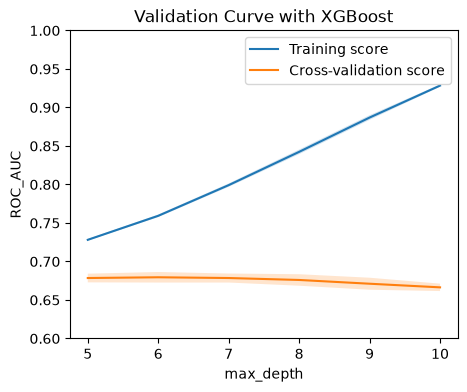

Best cross-validation result (0.6795) obtained for 6 max_depth
记录新的最优 max_depth： 6


In [8]:
# ============================================================
# 162. XGBoost - max_depth Validation Curve
# ============================================================

import matplotlib.pyplot as plt

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)

test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

plt.figure(figsize=(5, 4))

plt.plot(
    max_depth_range,
    train_scores_mean,
    label="Training score"
)

plt.plot(
    max_depth_range,
    test_scores_mean,
    label="Cross-validation score"
)

plt.fill_between(
    max_depth_range,
    train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std,
    alpha=0.2
)

plt.fill_between(
    max_depth_range,
    test_scores_mean - test_scores_std,
    test_scores_mean + test_scores_std,
    alpha=0.2
)

plt.xlabel("max_depth")
plt.ylabel("ROC_AUC")
plt.title("Validation Curve with XGBoost")
plt.ylim(0.6, 1.0)
plt.legend()
plt.show()

i = np.argmax(test_scores_mean)

best_xgb_max_depth = int(
    max_depth_range[i]
)

print(
    "Best cross-validation result "
    "({0:.4f}) obtained for {1} max_depth"
    .format(
        test_scores_mean[i],
        best_xgb_max_depth
    )
)

print(
    "记录新的最优 max_depth：",
    best_xgb_max_depth
)

In [9]:
# ============================================================
# 163. XGBoost - learning_rate 交叉验证
# ============================================================

best_xgb_n_estimators = 89
best_xgb_max_depth = 6

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=123
)

lr_range = [
    0.01,
    0.05,
    0.1,
    0.2,
    0.3,
    0.4,
    0.5
]

print(
    "固定 n_estimators：",
    best_xgb_n_estimators
)

print(
    "固定 max_depth：",
    best_xgb_max_depth
)

print(
    "learning_rate 候选值：",
    lr_range
)

start = time.time()

train_scores, test_scores = validation_curve(
    xgb.XGBClassifier(
        max_depth=best_xgb_max_depth,
        n_estimators=best_xgb_n_estimators,
        objective="binary:logistic",
        booster="gbtree",
        tree_method="auto",
        gamma=0.1,
        reg_lambda=2,
        subsample=0.7,
        colsample_bytree=0.7,
        min_child_weight=1,
        verbosity=2,
        seed=1000,
        n_jobs=7
    ),

    train_features,
    train_data["label"],

    param_name="learning_rate",
    param_range=lr_range,

    cv=cv,
    scoring="roc_auc",

    n_jobs=6,
    verbose=2
)

end = time.time()

print(
    "The program took %s seconds."
    % (end - start)
)

固定 n_estimators： 89
固定 max_depth： 6
learning_rate 候选值： [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]


[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done  35 out of  70 | elapsed:  1.1min remaining:  1.1min


The program took 130.89239144325256 seconds.


[Parallel(n_jobs=6)]: Done  70 out of  70 | elapsed:  2.2min finished


In [10]:
# ============================================================
# 164. 保存 learning_rate 交叉验证结果
# ============================================================

np.savez(
    "model/xgboost_cv_n89_depth6_learningrate.npz",
    train_scores=train_scores,
    test_scores=test_scores
)

print("✅ XGBoost learning_rate 交叉验证结果已保存")

✅ XGBoost learning_rate 交叉验证结果已保存


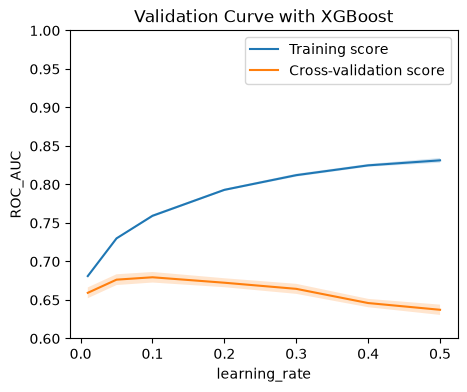

Best cross-validation result (0.6795) obtained for 0.1 learning_rate
记录新的最优 learning_rate： 0.1


In [11]:
# ============================================================
# 165. XGBoost - learning_rate Validation Curve
# ============================================================

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)

test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

plt.figure(figsize=(5, 4))

plt.plot(
    lr_range,
    train_scores_mean,
    label="Training score"
)

plt.plot(
    lr_range,
    test_scores_mean,
    label="Cross-validation score"
)

plt.fill_between(
    lr_range,
    train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std,
    alpha=0.2
)

plt.fill_between(
    lr_range,
    test_scores_mean - test_scores_std,
    test_scores_mean + test_scores_std,
    alpha=0.2
)

plt.xlabel("learning_rate")
plt.ylabel("ROC_AUC")
plt.title("Validation Curve with XGBoost")
plt.ylim(0.6, 1.0)
plt.legend()
plt.show()

i = np.argmax(test_scores_mean)

best_xgb_learning_rate = float(
    lr_range[i]
)

print(
    "Best cross-validation result "
    "({0:.4f}) obtained for {1} learning_rate"
    .format(
        test_scores_mean[i],
        best_xgb_learning_rate
    )
)

print(
    "记录新的最优 learning_rate：",
    best_xgb_learning_rate
)

In [12]:
# ============================================================
# 166. 定义并训练最终 XGBoost
# ============================================================

best_xgb_n_estimators = 89
best_xgb_max_depth = 6
best_xgb_learning_rate = 0.1

xgb_final = xgb.XGBClassifier(
    learning_rate=best_xgb_learning_rate,
    n_estimators=best_xgb_n_estimators,
    max_depth=best_xgb_max_depth,
    objective="binary:logistic",
    booster="gbtree",
    tree_method="auto",
    gamma=0.1,
    reg_lambda=2,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=1,
    verbosity=2,
    seed=1000,
    n_jobs=7,
    eval_metric="auc"
)

start = time.time()

xgb_final.fit(
    train_features,
    train_data["label"]
)

end = time.time()

print(
    "The program took %s seconds."
    % (end - start)
)

[11:19:27] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (260864, 123, 32086272).
The program took 3.224907636642456 seconds.


In [13]:
# ============================================================
# 167. 生成最终 XGBoost 提交文件
# ============================================================

prob = xgb_final.predict_proba(
    test_features
)

if "prob" in alitest.columns:
    alitest.drop(
        columns="prob",
        inplace=True
    )

alitest.insert(
    2,
    "prob",
    prob[:, 1]
)

alitest.to_csv(
    "data/submission_xgb_n89_depth6_lr0.1.csv",
    index=False
)

display(alitest.head())

print(
    "提交文件规模：",
    alitest.shape
)

,user_id,merchant_id,prob
0,163968,4605,0.079361
1,360576,1581,0.069956
2,98688,1964,0.052384
3,98688,3645,0.032662
4,295296,3361,0.096843


提交文件规模： (261477, 3)


In [14]:
# ============================================================
# 168. 保存最终 XGBoost 训练集预测概率
# ============================================================

train_preds = xgb_final.predict_proba(
    train_features
)

np.save(
    "data/trainpreds_xgb_n89_depth6_lr0.1.npy",
    train_preds[:, 1]
)

print(
    "训练集预测概率规模：",
    train_preds[:, 1].shape
)

训练集预测概率规模： (260864,)


In [15]:
# ============================================================
# 169. 检查 Stacking 所需文件
# ============================================================

from pathlib import Path

files = [
    "data/trainpreds_1231_logireg.npy",
    "data/trainpreds_rf_n155_depth15_features16_entropy.npy",
    "data/trainpreds_xgb_n89_depth6_lr0.1.npy",
    "data/submission_1231_logireg.csv",
    "data/submission_rf_n155_depth15_features16_entropy.csv",
    "data/submission_xgb_n89_depth6_lr0.1.csv"
]

for file in files:
    print(
        Path(file).exists(),
        file
    )

True data/trainpreds_1231_logireg.npy
True data/trainpreds_rf_n155_depth15_features16_entropy.npy
True data/trainpreds_xgb_n89_depth6_lr0.1.npy
True data/submission_1231_logireg.csv
True data/submission_rf_n155_depth15_features16_entropy.csv
True data/submission_xgb_n89_depth6_lr0.1.csv


In [16]:
# ============================================================
# 170. 检查 AdaBoost 的 Stacking 文件
# ============================================================

from pathlib import Path

files = [
    "data/trainpreds_0131_adaboost_n50_lr1.npy",
    "data/submission_0131_adaboost_n50_lr1.csv"
]

for file in files:
    print(
        Path(file).exists(),
        file
    )

True data/trainpreds_0131_adaboost_n50_lr1.npy
True data/submission_0131_adaboost_n50_lr1.csv


In [17]:
# ============================================================
# 171. 构造 Stacking 训练集和测试集
# ============================================================

import numpy as np
import pandas as pd

# 训练集预测概率
lr_train = np.load(
    "data/trainpreds_1231_logireg.npy"
)

rf_train = np.load(
    "data/trainpreds_rf_n155_depth15_features16_entropy.npy"
)

ada_train = np.load(
    "data/trainpreds_0131_adaboost_n50_lr1.npy"
)

xgb_train = np.load(
    "data/trainpreds_xgb_n89_depth6_lr0.1.npy"
)


# 测试集预测概率
lr_test = pd.read_csv(
    "data/submission_1231_logireg.csv"
)["prob"].values

rf_test = pd.read_csv(
    "data/submission_rf_n155_depth15_features16_entropy.csv"
)["prob"].values

ada_test = pd.read_csv(
    "data/submission_0131_adaboost_n50_lr1.csv"
)["prob"].values

xgb_test = pd.read_csv(
    "data/submission_xgb_n89_depth6_lr0.1.csv"
)["prob"].values


# 四个基础模型的概率作为新的4个特征
stack_train = np.column_stack([
    lr_train,
    rf_train,
    ada_train,
    xgb_train
])

stack_test = np.column_stack([
    lr_test,
    rf_test,
    ada_test,
    xgb_test
])

stack_y = train_data["label"].values


print(
    "stack_train：",
    stack_train.shape
)

print(
    "stack_test：",
    stack_test.shape
)

print(
    "stack_y：",
    stack_y.shape
)

stack_train： (260864, 4)
stack_test： (261477, 4)
stack_y： (260864,)


In [20]:
# ============================================================
# 171. 构造 Stacking 数据
# ============================================================

lr_train = np.load("data/trainpreds_1231_logireg.npy")
rf_train = np.load("data/trainpreds_rf_n155_depth15_features16_entropy.npy")
ada_train = np.load("data/trainpreds_0131_adaboost_n50_lr1.npy")
xgb_train = np.load("data/trainpreds_xgb_n89_depth6_lr0.1.npy")

lr_test = pd.read_csv("data/submission_1231_logireg.csv")["prob"].values
rf_test = pd.read_csv("data/submission_rf_n155_depth15_features16_entropy.csv")["prob"].values
ada_test = pd.read_csv("data/submission_0131_adaboost_n50_lr1.csv")["prob"].values
xgb_test = pd.read_csv("data/submission_xgb_n89_depth6_lr0.1.csv")["prob"].values

stack_train = pd.DataFrame({
    "lr": lr_train,
    "rf": rf_train,
    "xgb": xgb_train
})

stack_test = pd.DataFrame({
    "lr": lr_test,
    "rf": rf_test,
    "xgb": xgb_test
})

print(stack_train.shape)
print(stack_test.shape)

(260864, 3)
(261477, 3)


In [ ]:
# ============================================================
# 172. 定义 Stacking Perceptron
# ============================================================

from sklearn.linear_model import Perceptron
from sklearn.calibration import CalibratedClassifierCV

stack_pct = Perceptron(
    penalty="l2",
    alpha=0.0001,
    fit_intercept=True,
    max_iter=1000,
    tol=0.001,
    shuffle=True,
    verbose=2,
    eta0=1.0,
    n_jobs=None,
    random_state=0,
    early_stopping=False,
    validation_fraction=0.1,
    n_iter_no_change=5
)


# 使用3折交叉验证进行概率校准
pctCalib = CalibratedClassifierCV(
    stack_pct,
    cv=3
)

In [22]:
# ============================================================
# 173. 训练 Stacking Perceptron
# ============================================================

from sklearn.metrics import roc_auc_score

pctCalib.fit(
    stack_train,
    train_data["label"]
)

preds = pctCalib.predict(
    stack_train
)

print(
    roc_auc_score(
        preds,
        train_data["label"]
    )
)

-- Epoch 1
Norm: 8.50, NNZs: 3, Bias: -1.000000, T: 173909, Avg. loss: 0.015901
Total training time: 0.02 seconds.
-- Epoch 2
Norm: 8.54, NNZs: 3, Bias: -1.000000, T: 347818, Avg. loss: 0.015608
Total training time: 0.05 seconds.
-- Epoch 3
Norm: 9.19, NNZs: 3, Bias: -1.000000, T: 521727, Avg. loss: 0.015690
Total training time: 0.07 seconds.
-- Epoch 4
Norm: 9.25, NNZs: 3, Bias: -1.000000, T: 695636, Avg. loss: 0.015592
Total training time: 0.10 seconds.
-- Epoch 5
Norm: 8.34, NNZs: 3, Bias: -1.000000, T: 869545, Avg. loss: 0.015372
Total training time: 0.12 seconds.
-- Epoch 6
Norm: 8.53, NNZs: 3, Bias: -1.000000, T: 1043454, Avg. loss: 0.015599
Total training time: 0.15 seconds.
Convergence after 6 epochs took 0.15 seconds
-- Epoch 1
Norm: 8.37, NNZs: 3, Bias: -1.000000, T: 173909, Avg. loss: 0.015695
Total training time: 0.02 seconds.
-- Epoch 2
Norm: 9.12, NNZs: 3, Bias: -1.000000, T: 347818, Avg. loss: 0.015412
Total training time: 0.04 seconds.
-- Epoch 3
Norm: 9.71, NNZs: 3, Bi

In [23]:
# ============================================================
# 174. 生成 Stacking Perceptron 提交文件
# ============================================================

prob = pctCalib.predict_proba(
    stack_test
)

if "prob" in alitest.columns:
    alitest.drop(
        columns="prob",
        inplace=True
    )

alitest.insert(
    2,
    "prob",
    prob[:, 1]
)

alitest.to_csv(
    "data/submission_stack_perceptron_alpha0.0001_1000iter.csv",
    index=False
)

display(alitest.head())

print(
    "提交文件规模：",
    alitest.shape
)

,user_id,merchant_id,prob
0,163968,4605,0.016507
1,360576,1581,0.119844
2,98688,1964,0.004628
3,98688,3645,0.007451
4,295296,3361,0.248150


提交文件规模： (261477, 3)


In [28]:
# ============================================================
# 175. 定义 Stacking Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression

stack_lr = LogisticRegression(
    penalty="l2",
    dual=False,
    tol=0.0001,
    C=1.0,
    fit_intercept=True,
    intercept_scaling=1,
    class_weight=None,
    random_state=None,
    solver="lbfgs",
    max_iter=138,
    multi_class="ovr",
    verbose=1,
    warm_start=False,
    n_jobs=None
)

In [ ]:
# ============================================================
# 176. 训练 Stacking Logistic Regression
# ============================================================

stack_lr.fit(
    stack_train,
    train_data["label"]
)

preds = stack_lr.predict(
    stack_train
)

print(
    roc_auc_score(
        preds,
        train_data["label"]
    )
)

In [30]:
# ============================================================
# 177. 生成 Stacking Logistic Regression 提交文件
# ============================================================

prob = stack_lr.predict_proba(
    stack_test
)

if "prob" in alitest.columns:
    alitest.drop(
        columns="prob",
        inplace=True
    )

alitest.insert(
    2,
    "prob",
    prob[:, 1]
)

alitest.to_csv(
    "data/submission_stack_lr_138iter.csv",
    index=False
)

display(alitest.head())

print(
    "提交文件规模：",
    alitest.shape
)

,user_id,merchant_id,prob
0,163968,4605,0.013170
1,360576,1581,0.068349
2,98688,1964,0.009474
3,98688,3645,0.021256
4,295296,3361,0.131237


提交文件规模： (261477, 3)


In [31]:
# ============================================================
# 178. 最终提交文件检查
# ============================================================

final_submission = pd.read_csv(
    "data/submission_stack_lr_138iter.csv"
)

print(
    "数据规模：",
    final_submission.shape
)

print(
    "缺失值数量：",
    final_submission.isna().sum().sum()
)

print(
    "重复 User-Seller 数量：",
    final_submission.duplicated(
        subset=[
            "user_id",
            "merchant_id"
        ]
    ).sum()
)

print(
    "概率最小值：",
    final_submission["prob"].min()
)

print(
    "概率最大值：",
    final_submission["prob"].max()
)

display(
    final_submission.head()
)

数据规模： (261477, 3)
缺失值数量： 0
重复 User-Seller 数量： 0
概率最小值： 5.294452900872868e-11
概率最大值： 0.9999999999336562


,user_id,merchant_id,prob
0,163968,4605,0.013170
1,360576,1581,0.068349
2,98688,1964,0.009474
3,98688,3645,0.021256
4,295296,3361,0.131237


In [32]:
# ============================================================
# 179. 最终模型参数汇总
# ============================================================

final_model_summary = pd.DataFrame([
    {
        "模型": "Logistic Regression",
        "关键参数": "max_iter=138"
    },
    {
        "模型": "Random Forest",
        "关键参数": (
            "n_estimators=155, "
            "max_depth=15, "
            "max_features=16, "
            "criterion=entropy"
        )
    },
    {
        "模型": "XGBoost",
        "关键参数": (
            "n_estimators=89, "
            "max_depth=6, "
            "learning_rate=0.1"
        )
    },
    {
        "模型": "Stacking Perceptron",
        "关键参数": (
            "alpha=0.0001, "
            "max_iter=1000"
        )
    },
    {
        "模型": "Stacking Logistic Regression",
        "关键参数": "max_iter=138"
    }
])

display(final_model_summary)

final_model_summary.to_csv(
    "model/final_model_summary_2026.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ 最终模型参数汇总已保存")

,模型,关键参数
0,Logistic Regression,max_iter=138
1,Random Forest,"n_estimators=155, max_depth=15, max_features=1..."
2,XGBoost,"n_estimators=89, max_depth=6, learning_rate=0.1"
3,Stacking Perceptron,"alpha=0.0001, max_iter=1000"
4,Stacking Logistic Regression,max_iter=138


✅ 最终模型参数汇总已保存


In [35]:
# ============================================================
# 180. 项目最终文件检查
# ============================================================

from pathlib import Path

final_files = [
    "feature/user_features_final_2026.csv",
    "feature/merchant_features_v2_2026.csv",
    "feature/user_merchant_features_final_2026.csv",
    "feature/train_model_features_2026.csv",
    "feature/test_model_features_2026.csv",

    "data/submission_1231_logireg.csv",
    "data/submission_rf_n155_depth15_features16_entropy.csv",
    "data/submission_xgb_n89_depth6_lr0.1.csv",
    "data/submission_stack_perceptron_alpha0.0001_1000iter.csv",
    "data/submission_stack_lr_138iter.csv",

    "model/final_model_summary_2026.csv"
]

for file in final_files:
    path = Path(file)

    if path.exists():
        print(
            "✅",
            file,
            f"{path.stat().st_size / 1024 / 1024:.2f} MB"
        )
    else:
        print(
            "❌",
            file
        )

✅ feature/user_features_final_2026.csv 244.36 MB
✅ feature/merchant_features_v2_2026.csv 0.85 MB
✅ feature/user_merchant_features_final_2026.csv 57.52 MB
✅ feature/train_model_features_2026.csv 222.26 MB
✅ feature/test_model_features_2026.csv 222.57 MB
✅ data/submission_1231_logireg.csv 8.14 MB
✅ data/submission_rf_n155_depth15_features16_entropy.csv 8.15 MB
✅ data/submission_xgb_n89_depth6_lr0.1.csv 5.98 MB
✅ data/submission_stack_perceptron_alpha0.0001_1000iter.csv 8.31 MB
✅ data/submission_stack_lr_138iter.csv 8.26 MB
✅ model/final_model_summary_2026.csv 0.00 MB
